<a href="https://colab.research.google.com/github/Abeersuhail/Prediction-of-Radiotherapy-Side-effct/blob/main/Arm_lymphedema_Clinic_only_Feature_selection_7Sets_of_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using ML techniques to predict RT side effect as patients who affected by cancer and took RT after removing cancer part could be affercted by some RT side effect which can influence their quality of life such as arm_lymphoedema side effect. The data that had been collected contain clinical and genetic data  

In [222]:
##### 'breast_Arm_Lymphoedema24m' ###########

#**1) Data collection**



The data is stores as csv file and previously had been taken from the hospitals of 9 regiens, and all of these pateints had breast cancer before and acure with RT afterward the operation.

##importing some libraries in order to upload data

In [223]:
# importing Pandas and NumPy library
import pandas as pd
import numpy as np
from numpy import sqrt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# for visualising and metrics
from sklearn.decomposition import PCA
from sklearn import metrics
# for color heatmap
from matplotlib import cm

# for error
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from numpy import sqrt, argmax

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Step 1: Dynamically compute class weights
from collections import Counter
import numpy as np

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.cm as cm

## This with pipeline of standarise scaling
from tqdm import tqdm

In [224]:
# for ML models
# For statistic Method
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

from scipy.stats import chi2_contingency

# for calculate geometric mean
from numpy import argmax
from numpy import interp

from tabulate import tabulate

#from sklearn import feature_selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report

# Importing ML models
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier as KNN
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import VotingClassifier
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# Import Keras for implementing autoencoders
import keras
from imblearn.over_sampling import SMOTE



from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier # Import HistGradientBoostingClassifier
from sklearn.model_selection import RepeatedStratifiedKFold # import RepeatedStratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
import matplotlib.pyplot as plt
from tabulate import tabulate

## uploading the data

In [225]:
# Read the data from original file (use relative paths)
data1 = pd.read_csv('/content/FinalRTmerged_data28.12.24.csv')
#data1 = pd.read_csv('/content/FinalRTmerged_data8.10.25.csv')
data2= pd.read_csv('/content/ArmlymphedemaSNPs.csv')


In [226]:
list(data1.columns)

['subject_id',
 'date',
 'height_cm',
 'weight_at_cancer_diagnosis_kg',
 'age',
 'bra_cup_size',
 'band_size',
 'smoker',
 'smoking_duration_yrs',
 'tobacco_products_per_day',
 'smoking_time_since_quitting_yrs',
 'tobacco_product',
 'alcohol_intake',
 'alcohol_previous_consumption',
 'alcohol_current_consumption',
 'menopausal_status',
 'monopause_age_yrs',
 'hormone_replacement_therapy',
 'diabetes',
 'diabetes_duration_yrs',
 'history_of_heart_disease',
 'history_of_heart_disease_duration_yrs',
 'ra',
 'ra_duration_yrs',
 'systemic_lupus_erythematosus',
 'systemic_lupus_erythematosus_duration_yrs',
 'other_collagen_vascular_disease',
 'other_collagen_vascular_disease_duration_yrs',
 'hypertension',
 'hypertension_duration_yrs',
 'depression',
 'depression_duration_yrs',
 'antidiabetic',
 'antidiabetic_duration_yrs',
 'ace_inhibitor',
 'ace_inhibitor_duration_yrs',
 'other_antihypertensive_drug',
 'other_antihypertensive_drug_duration_yrs',
 'on_statin',
 'on_statin_duration_yrs',
 'o

In [227]:
# Select the dependent variable here
dependent1 = 'breast_arm_lymphodema_24m'


## implementing functions

In [228]:
# to show all rows and columns in dataframe
def max_val(df):
  pd.set_option('display.max_columns', None)
  pd.set_option('display.max_rows', None)

In [229]:
from IPython.display import display, HTML

def bold(text):
  display(HTML(f"<p style='font-size:16pt;'>{text}</p>"))

In [230]:
# To chech the percenage of null value in each feature
def nullP(df):
  count_null= ((pd.isnull(df).sum()/len(df))*100).round()
  print(count_null.sort_values(ascending=False))
  count_null.to_csv('count_null_all.csv')

In [231]:
# calculate uniq data in X coloumn
def Cuniq(df, x):
  print(df[x].sort_values().value_counts())

In [232]:
# This finction is used to print the uniques values in each feature in the dataset
def uniq(data):
  for col in list(data):
    print(col, "Unique Values are:\n ", data[col].unique())
    print("===================================================================================")

In [233]:
# This function is used to Remove all features that contain X % Missing values

def X_per_removed(data1, dep, perc):

    min_count = int(((100 - perc) / 100) * data1.shape[0] + 1)

    cols_to_keep = [
        col for col in data1.columns
        if col == dep or data1[col].count() >= min_count
    ]

    feat_data = data1[cols_to_keep]

    print(feat_data.shape)
    print(list(feat_data.columns))

    return feat_data

In [234]:
def remove_duplicate(df):

  duplicate_cols = []
  cols = df.columns
  for i in range(len(cols)):
      for j in range(i + 1, len(cols)):

          col1 = df[cols[i]]
          col2 = df[cols[j]]

          # Compare ignoring NaNs
          same = ((col1 == col2) | col1.isna() | col2.isna()).all()

          if same:

              # Keep column with fewer NaNs
              if col1.isna().sum() <= col2.isna().sum():
                  duplicate_cols.append(cols[j])
              else:
                  duplicate_cols.append(cols[i])

  print("Columns to drop:")
  print(set(duplicate_cols))

  # Drop duplicates
  n_df = df.drop(columns=set(duplicate_cols))
  print(n_df.shape)
  return n_df

In [235]:
import numpy as np
import pandas as pd

def pairwisecorr(df, col=None, threshold=0.70):

    # Save ID/target column if provided
    keep_col = None
    if col is not None and col in df.columns:
        keep_col = df[[col]]
        X = df.drop(columns=[col])
    else:
        X = df.copy()

    # Numeric columns only for correlation
    numeric_features = X.select_dtypes(include=np.number).columns
    X_numeric = X[numeric_features]

    corr_matrix = X_numeric.corr().abs()

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    tri_df = corr_matrix.mask(mask)

    to_drop = []
    correlated_pairs = []

    for c in tri_df.columns:
        for index, value in tri_df[c].items():

            if pd.notna(value) and value > threshold:

                correlated_pairs.append((c, index, value))

                # Drop lower-variance feature
                if X_numeric[c].var() > X_numeric[index].var():
                    to_drop.append(index)
                else:
                    to_drop.append(c)

    to_drop = list(set(to_drop))

    reduced_X = X.drop(columns=to_drop, errors='ignore')

    # Add col back to final dataset
    if keep_col is not None:
        reduced_X = pd.concat([keep_col, reduced_X], axis=1)

    print(f"Highly correlated feature pairs > {threshold}:")
    for c1, c2, corr in correlated_pairs:
        print(f"{c1} and {c2}: {corr:.2f}")

    print("\nRemoved features:")
    print(to_drop)

    print("\nFinal shape:", reduced_X.shape)

    return reduced_X

In [236]:
# VIF measures how much a feature (column) is correlated with the other features in your dataset. It's used to detect multicollinearity, which is when features are too similar to each other.
#A high VIF (e.g., > 5 or 10) means the feature is highly correlated with other features.
#This can make models like regression unstable or hard to interpret.
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, threshold):
    # Store Subject_Id separately
    subject_ids = df['Subject Id']

    # Drop Subject_Id and non-numeric, drop rows with missing values
    df_snp = df.drop(columns=['Subject Id'])
    df_snp = df_snp.select_dtypes(include=[float, int])
    df_snp = df_snp.dropna()

    # Keep matching Subject_Id values (after dropna)
    subject_ids = subject_ids.loc[df_snp.index]

    dropped = True
    while dropped:
        vif_data = pd.DataFrame()
        vif_data["SNP"] = df_snp.columns
        vif_data["VIF"] = [variance_inflation_factor(df_snp.values, i)
                           for i in range(df_snp.shape[1])]

        max_vif = vif_data["VIF"].max()
        if max_vif > threshold:
            drop_snp = vif_data.sort_values("VIF", ascending=False).iloc[0]["SNP"]
            df_snp = df_snp.drop(columns=[drop_snp])
            print(f"Dropped {drop_snp} with VIF {max_vif:.2f}")
        else:
            dropped = False

    # Add Subject_Id back safely
    df_snp['Subject Id'] = subject_ids.values

    return df_snp


In [237]:
# Using Cross Validation to Get the Best Value of k in KNN model
# The function below shows us the best value for K in KNN using cross validation

def BestK(X, y, k_values=range(1, 21)):
    scores = []
    scaler = StandardScaler()
    # Keep only the rows in y that match X's indices
    y = y.loc[y.index.intersection(X.index)]
    X = X.loc[y.index]  # Also make sure X only keeps matching rows

    X_scaled = scaler.fit_transform(X)

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        cv_scores = cross_val_score(knn, X_scaled, y, cv=10, scoring="roc_auc")
        scores.append(np.mean(cv_scores))

    best_index = np.argmax(scores)
    best_k = k_values[best_index]
    print("Best K:", best_k)
    print("Best Score:", scores[best_index])
    return best_k


# **2) Data Cleaning visualization**

Which involves presenting data in a visual format such as charts and graphs to make it easier to understand and to identify patterns anf drends in the data.

## Navigating & Labeling**

In [238]:
print(data1.shape + data2.shape)

(2067, 507, 5087, 31)


In [239]:
data1.head()

,subject_id,date,height_cm,weight_at_cancer_diagnosis_kg,age,bra_cup_size,band_size,smoker,smoking_duration_yrs,tobacco_products_per_day,...,breast_pain_severity_96m,breast_pain_medication_96m,breast_pain_medication_name_96m,breast_pain_medication_dose_and_freq_96m,breast_swollen_arm_96m,breast_swollen_arm_interferes_with_normal_activity_96m,breast_left_arm_circumfrence_mm_96m,breast_right_arm_circumfrence_mm_96m,breast_arm_measuring_date_96m,Site_96m
0,RQ00001-2,24/06/2014,164.0,78.0,62,5.0,8.0,1.0,30.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RQ00002-0,08/07/2014,162.0,57.0,47,3.0,3.0,3.0,30.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RQ00004-9,17/06/2014,171.0,82.0,56,5.0,9.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RQ00005-4,06/08/2014,156.0,76.0,63,5.0,8.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RQ00006-5,02/07/2014,164.0,59.0,68,5.0,5.0,1.0,17.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [240]:
print(list(data1.columns))

['subject_id', 'date', 'height_cm', 'weight_at_cancer_diagnosis_kg', 'age', 'bra_cup_size', 'band_size', 'smoker', 'smoking_duration_yrs', 'tobacco_products_per_day', 'smoking_time_since_quitting_yrs', 'tobacco_product', 'alcohol_intake', 'alcohol_previous_consumption', 'alcohol_current_consumption', 'menopausal_status', 'monopause_age_yrs', 'hormone_replacement_therapy', 'diabetes', 'diabetes_duration_yrs', 'history_of_heart_disease', 'history_of_heart_disease_duration_yrs', 'ra', 'ra_duration_yrs', 'systemic_lupus_erythematosus', 'systemic_lupus_erythematosus_duration_yrs', 'other_collagen_vascular_disease', 'other_collagen_vascular_disease_duration_yrs', 'hypertension', 'hypertension_duration_yrs', 'depression', 'depression_duration_yrs', 'antidiabetic', 'antidiabetic_duration_yrs', 'ace_inhibitor', 'ace_inhibitor_duration_yrs', 'other_antihypertensive_drug', 'other_antihypertensive_drug_duration_yrs', 'on_statin', 'on_statin_duration_yrs', 'other_lipid_lowering_drugs', 'other_lipid

In [241]:
data2.head()

,Subject_Id,rs2101893,rs77405610,rs67342194,rs2954011,rs1788750,rs10764743,rs4859721,rs7195405,rs6009631,...,rs13132305,rs10945395,rs461769,rs7179547,rs61912468,rs72857489,rs35410275,rs61912469,rs885170,rs11631993
0,RQ22067-0,1.564,0.192,0.999,1.174,0.877,0.069,0.128,1.002,0.003,...,1.988,1.987,2.000,2.000,0.0,0.000,0.000,0.0,0.996,2.000
1,RQ34365-4,1.802,0.000,0.000,1.991,2.000,0.966,1.972,1.028,0.007,...,2.000,0.002,1.000,2.000,0.0,0.000,0.000,0.0,0.000,2.000
2,RQ34616-4,1.769,0.000,0.066,0.198,0.000,0.986,1.998,0.008,0.463,...,2.000,1.000,1.000,1.996,0.0,0.000,0.000,0.0,0.012,1.998
3,RQ34720-1,1.672,0.773,0.993,1.307,0.995,1.856,1.103,1.971,0.845,...,1.042,0.000,1.005,1.995,0.0,0.095,0.000,0.0,0.015,2.000
4,RQ14799-8,1.984,0.000,0.000,0.009,0.992,0.668,1.151,0.006,0.011,...,2.000,1.972,1.000,1.996,0.0,0.000,0.012,0.0,0.004,2.000


In [242]:
# Show the length of data
len(data2)

5087

In [243]:
# Rename the subject id column to the id in order to be mereged
data2.rename(columns = {'Subject_Id':'Subject Id'}, inplace = True)
data1.rename(columns = {'subject_id':'Subject Id'}, inplace = True)

In [244]:
data2 = data2[data2['Subject Id'].isin(data1['Subject Id'])]

In [245]:
data2.shape

(1912, 31)

In [246]:
data1.describe()

,height_cm,weight_at_cancer_diagnosis_kg,age,bra_cup_size,band_size,smoker,smoking_duration_yrs,tobacco_products_per_day,smoking_time_since_quitting_yrs,alcohol_intake,...,breast_pneumontis_96m,breast_pain_96m,breast_pain_severity_96m,breast_pain_medication_96m,breast_pain_medication_name_96m,breast_pain_medication_dose_and_freq_96m,breast_swollen_arm_96m,breast_swollen_arm_interferes_with_normal_activity_96m,breast_left_arm_circumfrence_mm_96m,breast_right_arm_circumfrence_mm_96m
count,2057.000000,2053.000000,2067.000000,1997.000000,1975.000000,2045.000000,823.000000,815.000000,483.000000,2010.000000,...,30.000000,30.000000,1.0,1.0,0.0,0.0,30.000000,0.0,30.000000,30.000000
mean,162.794361,70.110083,58.248670,3.899349,6.031899,0.749144,23.407047,12.597546,19.571429,1.579602,...,0.600000,4.300000,1.0,0.0,NaN,NaN,7.766667,NaN,302.333333,299.833333
std,6.820660,14.919588,11.048345,1.250805,1.887004,1.048788,13.296206,9.529728,13.529305,1.455113,...,2.283373,4.480994,NaN,NaN,NaN,NaN,3.103761,NaN,38.523019,34.826747
min,140.000000,36.000000,23.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,0.0,NaN,NaN,0.000000,NaN,240.000000,240.000000
25%,158.000000,60.000000,50.000000,3.000000,5.000000,0.000000,10.000000,5.000000,9.000000,0.000000,...,0.000000,0.000000,1.0,0.0,NaN,NaN,9.000000,NaN,276.250000,276.250000
50%,163.000000,68.000000,58.000000,4.000000,6.000000,0.000000,23.000000,10.000000,18.000000,2.000000,...,0.000000,1.000000,1.0,0.0,NaN,NaN,9.000000,NaN,295.000000,292.500000
75%,168.000000,78.000000,66.000000,5.000000,7.000000,1.000000,34.000000,20.000000,30.000000,3.000000,...,0.000000,9.000000,1.0,0.0,NaN,NaN,9.000000,NaN,330.000000,320.000000
max,187.000000,187.000000,90.000000,11.000000,10.000000,3.000000,64.000000,80.000000,65.000000,3.000000,...,9.000000,9.000000,1.0,0.0,NaN,NaN,9.000000,NaN,385.000000,375.000000


In [247]:
data2.describe()

,rs2101893,rs77405610,rs67342194,rs2954011,rs1788750,rs10764743,rs4859721,rs7195405,rs6009631,rs2954007,...,rs13132305,rs10945395,rs461769,rs7179547,rs61912468,rs72857489,rs35410275,rs61912469,rs885170,rs11631993
count,1912.000000,1912.000000,1912.000000,1912.000000,1912.000000,1912.000000,1912.000000,1912.000000,1912.000000,1912.000000,...,1912.000000,1912.000000,1912.000000,1912.000000,1912.000000,1912.000000,1912.000000,1912.000000,1912.000000,1912.000000
mean,1.779041,0.110039,0.493405,1.112940,1.049048,0.985759,1.731134,0.680379,0.144159,0.776401,...,1.881428,0.398370,1.302837,1.596113,0.184874,0.131022,0.278590,0.100631,0.401267,1.597183
std,0.250131,0.226129,0.596734,0.593418,0.678163,0.613357,0.431270,0.640959,0.299560,0.573873,...,0.319286,0.548836,0.656008,0.567571,0.370002,0.333938,0.462316,0.287914,0.535351,0.568476
min,0.251000,0.000000,0.000000,0.000000,0.000000,0.000000,0.029000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.705750,0.000000,0.000000,0.812250,0.850000,0.516500,1.282500,0.013000,0.000000,0.160750,...,1.992000,0.000000,1.000000,1.003000,0.000000,0.000000,0.000000,0.000000,0.000000,1.002000
50%,1.871000,0.001000,0.028000,1.076000,0.996000,0.997000,1.979000,0.913500,0.005000,0.829000,...,2.000000,0.002000,1.060500,1.997000,0.000000,0.000000,0.003000,0.000000,0.023000,1.999000
75%,1.954000,0.094250,0.995000,1.495000,1.835250,1.359250,1.994000,1.012000,0.071250,0.982000,...,2.000000,0.999000,1.999000,2.000000,0.107500,0.000250,0.739500,0.002000,0.942000,2.000000
max,2.000000,1.792000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.981000,1.989000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.995000,1.998000,2.000000,2.000000,2.000000


In [248]:
data1.columns = data1.columns.str.strip()  # Removes leading/trailing spaces

In [249]:
print(data1[dependent1].isna().sum()) # How many values missing in this varible
print(len(data1))  # Total rows

376
2067


In [250]:
print(data1[dependent1].dtype)

float64


In [251]:
# Show the unique value of specific coloumn
data1[dependent1].unique()

array([ 0., nan,  1.,  2.])

## Data preprocessing
such as Data formatting, Data cleaning, Data anonymization and Data sampling.

In [252]:
# Manipulate unclear values
data1 = data1.replace('?', np.nan)  # replace ? with nan
data1 = data1.replace('x', np.nan)  # replace ? with nan
data1 = data1.replace('0.0%', 0)  # replace ? with nan
data1 = data1.replace('0', 0)  # replace 0 char with num
data1 = data1.replace('1', 1)  # replace 1 char with num
data1 = data1.replace('2', 2)  # replace 2 char with num
data1 = data1.replace('3', 3)  # replace 3 char with num
data1 = data1.replace('^\s+', np.nan, regex=True)  # replace empty spaces with nan value

In [253]:
# Handling some missing values
data1["smoker"].fillna(0, inplace=True) # notice from data sheet that null values in smokers have value 0 in smoking
data1["alcohol_intake"].fillna(0, inplace=True) # notice from data sheet that non alcohol drinker dont have alcoholintaker

In [254]:
nullP(data1)

breast_nipple_retraction MV Indicator_96m                 100.0
CRFstatus_96m                                             100.0
breast_swollen_arm_interferes_with_normal_activity_96m    100.0
breast_swollen_arm_interferes_with_normal_activity_84m    100.0
breast_pain_medication_dose_and_freq_84m                  100.0
                                                          ...  
ace_inhibitor                                               0.0
age                                                         0.0
height_cm                                                   0.0
date                                                        0.0
Subject Id                                                  0.0
Length: 507, dtype: float64


In [255]:
data1.shape

(2067, 507)

In [256]:
#Remove all features that contain 50% or more null
n_data1= X_per_removed(data1,dependent1, 50)

(2067, 182)
['Subject Id', 'date', 'height_cm', 'weight_at_cancer_diagnosis_kg', 'age', 'bra_cup_size', 'band_size', 'smoker', 'alcohol_intake', 'alcohol_current_consumption', 'menopausal_status', 'monopause_age_yrs', 'hormone_replacement_therapy', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'antidiabetic', 'ace_inhibitor', 'other_antihypertensive_drug', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'antidepressant', 'breast_cancer_family_history_1st_degree', 'radiotherapy_toxicity_family_history', 'ethnicity', 'education_profession', 'household_members', 'Sequence Num_x', 'Date', 'Visit_y', 'surgery', 'surgery_type', 'surgery_date', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_side_of_primary', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumo

In [257]:
n_data1= remove_duplicate(n_data1)

Columns to drop:
{'Visit_postRT', 'CRFversion_12m', 'surgery', 'Site_24m', 'Sequence Num_baseline', 'CRFversion_24m', 'CRFversion_postRT', 'Site_postRT', 'Sequence Num_postRT', 'Site_12m', 'Site_baseline'}
(2067, 171)


**Correct datatypes in dataframe**

In [258]:
n_data1.dtypes.to_csv('data1_dtypes.csv')

In [259]:
#uniq(n_data1)

In [260]:
# 4. ID columns
n_data1['Subject Id'] = n_data1['Subject Id'].astype('string')


# 5. Date columns
date_cols = [col for col in n_data1.columns if 'date' in col.lower()]

for col in date_cols:
    n_data1[col] = pd.to_datetime(n_data1[col], errors='coerce')



In [261]:
# 6. Keep real continuous numeric columns
continuous_cols = [
    'height_cm',
    'weight_at_cancer_diagnosis_kg',
    'age',
    'monopause_age_yrs',
    'nodes_involved',
    'nodes_examined',
    'tumour_size_mm',
    'ki_67_status_pc',
    'radio_breast_dose_Gy',
    'radio_photon_dose_MV',
    'radio_breast_fractions',
    'radio_breast_ct_volume_cm3',
    'radio_breast_internal_mammary_volume_cm3',
    'radio_skin_max_dose_Gy',
    'radio_heart_mean_dose_Gy',
    'radio_ipsilateral_lung_mean_Gy',
    'radio_breast_fractions_dose_per_fraction_Gy',
    'radio_breast_fractions_per_week',
    'radio_photon_boostdose_precise_Gy',
    'radio_photon_boost_fractions',
    'radio_photon_boost_fractions_per_week',
    'radio_photon_boost_dose_per_fraction_Gy',
    'breast_left_arm_circumfrence_mm_baseline',
    'breast_right_arm_circumfrence_mm_baseline',
    'breast_left_arm_circumfrence_mm_postRT',
    'breast_right_arm_circumfrence_mm_postRT',
    'breast_left_arm_circumfrence_mm_12m',
    'breast_right_arm_circumfrence_mm_12m',
    'breast_left_arm_circumfrence_mm_24m',
    'breast_right_arm_circumfrence_mm_24m'
]

continuous_cols = [col for col in continuous_cols if col in n_data1.columns]

for col in continuous_cols:
    n_data1[col] = pd.to_numeric(n_data1[col], errors='coerce')



In [262]:
# 7. Everything else with low unique values becomes category
exclude_cols = ['Subject Id'] + date_cols + continuous_cols

cat_cols = [col for col in n_data1.columns if col not in exclude_cols]

for col in cat_cols:
    n_data1[col] = n_data1[col].astype('category')


# 8. Check final result
print(n_data1.dtypes)

Subject Id                              string[python]
date                                    datetime64[ns]
height_cm                                      float64
weight_at_cancer_diagnosis_kg                  float64
age                                              int64
                                             ...      
breast_pneumontis_24m                         category
breast_pain_24m                               category
breast_swollen_arm_24m                        category
breast_left_arm_circumfrence_mm_24m            float64
breast_right_arm_circumfrence_mm_24m           float64
Length: 171, dtype: object


In [263]:
# 8. Check final result
n_data1.dtypes.to_csv('data1_dtypes_clean2.csv')

In [264]:
# Remove Columns With Only One Unique Non-NaN Value
constant_cols = []

for col in n_data1.columns:

    unique_non_nan = n_data1[col].dropna().nunique()

    if unique_non_nan <= 1:
        constant_cols.append(col)

print("Constant columns:")
print(constant_cols)

# Drop them
n_data1 = n_data1.drop(columns=constant_cols)
n_data1.shape

Constant columns:
['Sequence Num_x', 'Visit_y', 'Sequence Num_y', 'Visit_baseline', 'CRFversion_baseline', 'Visit_12m', 'Sequence Num_12m', 'Visit_24m', 'Sequence Num_24m']


(2067, 162)

In [265]:
# same result as above
#df_clean = df.loc[:, df.nunique(dropna=True) > 1]

In [266]:
print(list(n_data1.columns))

['Subject Id', 'date', 'height_cm', 'weight_at_cancer_diagnosis_kg', 'age', 'bra_cup_size', 'band_size', 'smoker', 'alcohol_intake', 'alcohol_current_consumption', 'menopausal_status', 'monopause_age_yrs', 'hormone_replacement_therapy', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'antidiabetic', 'ace_inhibitor', 'other_antihypertensive_drug', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'antidepressant', 'breast_cancer_family_history_1st_degree', 'radiotherapy_toxicity_family_history', 'ethnicity', 'education_profession', 'household_members', 'Date', 'surgery_type', 'surgery_date', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_side_of_primary', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 'tumour_size_mm', 't_stage', 

In [267]:
# no need to add it as it will be removed with pairwise correlation method below
#df['bmi'] = (df['weight_at_cancer_diagnosis_kg'] / df['height_cm'].div(1000).pow(2)).div(100)

In [268]:
# remove features with any post RT data
n_data11= n_data1[['Subject Id', 'date', 'height_cm', 'weight_at_cancer_diagnosis_kg', 'age', 'bra_cup_size', 'band_size', 'smoker', 'alcohol_intake', 'alcohol_current_consumption', 'menopausal_status', 'monopause_age_yrs', 'hormone_replacement_therapy', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'antidiabetic', 'ace_inhibitor', 'other_antihypertensive_drug', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'antidepressant', 'breast_cancer_family_history_1st_degree', 'radiotherapy_toxicity_family_history', 'ethnicity', 'education_profession', 'household_members', 'Date', 'surgery_type', 'surgery_date', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_side_of_primary', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 'tumour_size_mm', 't_stage', 'n_stage', 'm_stage', 'r_stage', 'ki_67_status_pc', 'er_status', 'her2_status', 'pr_status', 'chemo_neo_adjuvant', 'chemo_adjuvant', 'sys_treatment', 'sys_tamoxifen', 'sys_aromatase', 'sys_antiher2', 'radio_breast_startdate', 'radio_breast_enddate', 'radio_interrupted', 'radio_breast_dose_Gy', 'radio_photon_dose_MV', 'radio_breast_fractions', 'radio_breast_ct_volume_cm3', 'radio_breast_delineation', 'radio_breast_internal_mammary_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_skin_delineation', 'radio_heart_mean_dose_Gy', 'radio_heart_delineation', 'radio_hot_spots_107', 'radio_ipsilateral_lung_mean_Gy', 'radio_imrt', 'radio_treatment_pos', 'radio_3d', 'radio_treated_breast', 'axillary_levels', 'radio_supraclavicular_fossa', 'radio_boost', 'radio_boost_startdate', 'radio_boost_enddate', 'radio_boost_type', 'radio_bolus', 'radio_boost_sequence', 'surgery_axilla_type', 'radio_breast_fractions_dose_per_fraction_Gy', 'radio_breast_fractions_per_week', 'radio_photon_2nd', 'radio_photon_boostdose_precise_Gy', 'radio_photon_boost_fractions', 'radio_photon_boost_fractions_per_week', 'radio_photon_boost_dose_per_fraction_Gy', 'Site', 'breast_atrophy_baseline', 'breast_nipple_retraction_baseline', 'breast_oedema_baseline', 'breast_skin_ulceration_baseline', 'breast_telangiectasia_tumour_bed_baseline', 'breast_telangiectasia_outside_tumour_bed_baseline', 'breast_skin_induration_tumour_bed_baseline', 'breast_skin_induration_outside_tumour_bed_baseline', 'breast_erythema_baseline', 'breast_arm_lymphodema_baseline', 'breast_skin_hyperpigmentation_baseline', 'breast_pneumontis_baseline', 'breast_pain_baseline', 'breast_swollen_arm_baseline', 'breast_left_arm_circumfrence_mm_baseline', 'breast_right_arm_circumfrence_mm_baseline', 'breast_arm_lymphodema_24m']]

In [269]:
n_data11= pairwisecorr(n_data11, dependent1, threshold=0.7)

Highly correlated feature pairs > 0.7:
weight_at_cancer_diagnosis_kg and radio_breast_ct_volume_cm3: 0.73
weight_at_cancer_diagnosis_kg and breast_left_arm_circumfrence_mm_baseline: 0.81
weight_at_cancer_diagnosis_kg and breast_right_arm_circumfrence_mm_baseline: 0.82
radio_breast_dose_Gy and radio_breast_fractions: 0.98
radio_breast_dose_Gy and radio_skin_max_dose_Gy: 0.76
radio_breast_dose_Gy and radio_breast_fractions_dose_per_fraction_Gy: 0.84
radio_breast_fractions and radio_skin_max_dose_Gy: 0.74
radio_breast_fractions and radio_breast_fractions_dose_per_fraction_Gy: 0.82
radio_photon_boost_fractions_per_week and radio_photon_boost_dose_per_fraction_Gy: 0.87
breast_left_arm_circumfrence_mm_baseline and breast_right_arm_circumfrence_mm_baseline: 0.97

Removed features:
['radio_breast_fractions', 'radio_photon_boost_fractions_per_week', 'weight_at_cancer_diagnosis_kg', 'radio_breast_dose_Gy', 'radio_breast_fractions_dose_per_fraction_Gy', 'breast_left_arm_circumfrence_mm_baseline']

In [270]:
print(list(n_data11.columns))

['breast_arm_lymphodema_24m', 'Subject Id', 'date', 'height_cm', 'age', 'bra_cup_size', 'band_size', 'smoker', 'alcohol_intake', 'alcohol_current_consumption', 'menopausal_status', 'monopause_age_yrs', 'hormone_replacement_therapy', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'antidiabetic', 'ace_inhibitor', 'other_antihypertensive_drug', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'antidepressant', 'breast_cancer_family_history_1st_degree', 'radiotherapy_toxicity_family_history', 'ethnicity', 'education_profession', 'household_members', 'Date', 'surgery_type', 'surgery_date', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_side_of_primary', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 'tumour_size_mm', 't_stage', 'n_s

In [271]:
print(list(data2.columns))

['Subject Id', 'rs2101893', 'rs77405610', 'rs67342194', 'rs2954011', 'rs1788750', 'rs10764743', 'rs4859721', 'rs7195405', 'rs6009631', 'rs2954007', 'rs200456488', 'rs57288348', 'rs35035095', 'rs72977387', 'rs56402833', 'rs633502', 'rs2861705', 'rs3748569', 'rs79223472', 'rs74853756', 'rs13132305', 'rs10945395', 'rs461769', 'rs7179547', 'rs61912468', 'rs72857489', 'rs35410275', 'rs61912469', 'rs885170', 'rs11631993']


In [272]:
data2.shape

(1912, 31)

In [273]:
data2 = calculate_vif(data2, 5)

Dropped rs7179547 with VIF 24982.99
Dropped rs11631993 with VIF 100.95
Dropped rs2101893 with VIF 33.66
Dropped rs13132305 with VIF 23.93
Dropped rs2954011 with VIF 23.18
Dropped rs4859721 with VIF 12.01
Dropped rs200456488 with VIF 7.88


In [274]:
data2.shape

(1912, 24)

In [275]:
data2= pairwisecorr(data2, dependent1, threshold=0.7)

Highly correlated feature pairs > 0.7:
rs61912468 and rs61912469: 0.80

Removed features:
['rs61912469']

Final shape: (1912, 23)


In [276]:
data2.head()

,rs77405610,rs67342194,rs1788750,rs10764743,rs7195405,rs6009631,rs2954007,rs57288348,rs35035095,rs72977387,...,rs3748569,rs79223472,rs74853756,rs10945395,rs461769,rs61912468,rs72857489,rs35410275,rs885170,Subject Id
0,0.192,0.999,0.877,0.069,1.002,0.003,0.730,0.000,0.005,0.093,...,1.814,0.000,0.999,1.987,2.000,0.0,0.000,0.000,0.996,RQ22067-0
1,0.000,0.000,2.000,0.966,1.028,0.007,1.809,0.002,0.982,0.150,...,1.003,0.000,0.000,0.002,1.000,0.0,0.000,0.000,0.000,RQ34365-4
2,0.000,0.066,0.000,0.986,0.008,0.463,0.005,0.011,0.947,0.010,...,1.968,0.000,0.000,1.000,1.000,0.0,0.000,0.000,0.012,RQ34616-4
3,0.773,0.993,0.995,1.856,1.971,0.845,0.937,0.006,0.028,0.034,...,0.113,0.002,1.000,0.000,1.005,0.0,0.095,0.000,0.015,RQ34720-1
4,0.000,0.000,0.992,0.668,0.006,0.011,0.002,0.003,1.968,0.120,...,0.003,0.000,0.000,1.972,1.000,0.0,0.000,0.012,0.004,RQ14799-8


In [277]:
data2 = data2.drop_duplicates(subset='Subject Id')

**2.2.4) Data transformation such as Scaling, Decomposition and Aggregation**

In [278]:
# Mapping data1 and data2 together by the id column

n_df = pd.merge(n_data11, data2,on = 'Subject Id', how='left')
#n_df = data1

print(n_df.shape)

(2067, 131)


In [279]:
# no need because already done this for both data
#uncorrelated_df= pairwisecorr(n_df, dependent1, threshold=0.7)

In [280]:
uncorrelated_df= n_df

In [281]:
# I f I want to use clinic data only
#n_df= data1

In [282]:
# from this dataset we can divide the features into clinic, snps or the combined which has all
print(list(uncorrelated_df))

['breast_arm_lymphodema_24m', 'Subject Id', 'date', 'height_cm', 'age', 'bra_cup_size', 'band_size', 'smoker', 'alcohol_intake', 'alcohol_current_consumption', 'menopausal_status', 'monopause_age_yrs', 'hormone_replacement_therapy', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'antidiabetic', 'ace_inhibitor', 'other_antihypertensive_drug', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'antidepressant', 'breast_cancer_family_history_1st_degree', 'radiotherapy_toxicity_family_history', 'ethnicity', 'education_profession', 'household_members', 'Date', 'surgery_type', 'surgery_date', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_side_of_primary', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 'tumour_size_mm', 't_stage', 'n_s

In [283]:
# Drop date-type features
#n_df = n_df.drop(columns=n_df.select_dtypes(include=['datetime']).columns)

In [284]:
#n_df.columns = n_df.columns.to_flat_index()

In [285]:
Cuniq(uncorrelated_df, dependent1)

breast_arm_lymphodema_24m
0.0    1628
1.0      54
2.0       9
Name: count, dtype: int64


From above we can see that Grade 3 atrophy is contain 24 cases, g1 and g2 in clinics have the same procedure, so thought doing binary classification is the right option for Erythema.

In [286]:
# We transform the arm_lymphodema_24 column values to 0 and 1 for a better exploration,

reduced_df = uncorrelated_df.replace(dict(breast_arm_lymphodema_24m={0: 0, 1: 1, 2:1 , 3:1}))


In [287]:
Cuniq(reduced_df, dependent1)

breast_arm_lymphodema_24m
0.0    1628
1.0      63
Name: count, dtype: int64


In [288]:
# select categorical features in order to transform them to numeric data
cat_columns = reduced_df.select_dtypes(['category']).columns
# trans the values to numeric and apply that to the data
#reduced_df[cat_columns] = reduced_df[cat_columns].apply(lambda x: x.cat.codes)

reduced_df[cat_columns] = (reduced_df[cat_columns].
                           apply(lambda x: x.cat.codes.replace(-1, np.nan)))


In [289]:
Cuniq(reduced_df, dependent1)

breast_arm_lymphodema_24m
0.0    1628
1.0      63
Name: count, dtype: int64


In [290]:
print(list(reduced_df.columns))

['breast_arm_lymphodema_24m', 'Subject Id', 'date', 'height_cm', 'age', 'bra_cup_size', 'band_size', 'smoker', 'alcohol_intake', 'alcohol_current_consumption', 'menopausal_status', 'monopause_age_yrs', 'hormone_replacement_therapy', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'antidiabetic', 'ace_inhibitor', 'other_antihypertensive_drug', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'antidepressant', 'breast_cancer_family_history_1st_degree', 'radiotherapy_toxicity_family_history', 'ethnicity', 'education_profession', 'household_members', 'Date', 'surgery_type', 'surgery_date', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_side_of_primary', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 'tumour_size_mm', 't_stage', 'n_s

##Removing Correlated Features
Feature selection:is very important to remove irrelevant features result in a better performance model, to easier understand the model and to run the model fast**




**Pairwise correlated feature selection**

In [291]:
df_clean= pairwisecorr(reduced_df, dependent1, 0.7) # May some feature are missing so compare with below

Highly correlated feature pairs > 0.7:
diabetes and antidiabetic: 0.90
hypertension and other_antihypertensive_drug: 0.80
depression and antidepressant: 0.86
nodes_involved and n_stage: 0.86
nodes_examined and surgery_axilla_type: 0.73
tumour_side_of_primary and radio_treated_breast: 1.00
her2_status and sys_antiher2: 0.85
sys_tamoxifen and sys_aromatase: 0.85
radio_skin_delineation and radio_3d: 0.75
radio_boost_sequence and radio_photon_boost_fractions: 0.84

Removed features:
['other_antihypertensive_drug', 'antidiabetic', 'radio_boost_sequence', 'sys_tamoxifen', 'radio_skin_delineation', 'surgery_axilla_type', 'sys_antiher2', 'antidepressant', 'n_stage', 'tumour_side_of_primary']

Final shape: (2067, 121)


In [292]:
# remove all date coloums
datetime_cols = df_clean.select_dtypes(include=['datetime64']).columns
print(datetime_cols)
if not datetime_cols.empty:
      df_clean = df_clean.drop(columns=datetime_cols)

Index(['date', 'Date', 'surgery_date', 'radio_breast_startdate',
       'radio_breast_enddate', 'radio_boost_startdate', 'radio_boost_enddate'],
      dtype='object')


In [293]:
print(list(df_clean.columns))

['breast_arm_lymphodema_24m', 'Subject Id', 'height_cm', 'age', 'bra_cup_size', 'band_size', 'smoker', 'alcohol_intake', 'alcohol_current_consumption', 'menopausal_status', 'monopause_age_yrs', 'hormone_replacement_therapy', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'ace_inhibitor', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'breast_cancer_family_history_1st_degree', 'radiotherapy_toxicity_family_history', 'ethnicity', 'education_profession', 'household_members', 'surgery_type', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 'tumour_size_mm', 't_stage', 'm_stage', 'r_stage', 'ki_67_status_pc', 'er_status', 'her2_status', 'pr_status', 'chemo_neo_adjuvant', 'chemo_adjuvant', 'sys_

In [294]:
reduced_df_clinic=reduced_df[['breast_arm_lymphodema_24m', 'Subject Id', 'height_cm', 'age', 'bra_cup_size', 'band_size', 'smoker', 'alcohol_intake', 'alcohol_current_consumption', 'menopausal_status', 'monopause_age_yrs', 'hormone_replacement_therapy', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'ace_inhibitor', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'breast_cancer_family_history_1st_degree', 'radiotherapy_toxicity_family_history', 'ethnicity', 'education_profession', 'household_members', 'surgery_type', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 'tumour_size_mm', 't_stage', 'm_stage', 'r_stage', 'ki_67_status_pc', 'er_status', 'her2_status', 'pr_status', 'chemo_neo_adjuvant', 'chemo_adjuvant', 'sys_treatment', 'sys_aromatase', 'radio_interrupted', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_breast_delineation', 'radio_breast_internal_mammary_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_heart_delineation', 'radio_hot_spots_107', 'radio_ipsilateral_lung_mean_Gy', 'radio_imrt', 'radio_treatment_pos', 'radio_3d', 'radio_treated_breast', 'axillary_levels', 'radio_supraclavicular_fossa', 'radio_boost', 'radio_boost_type', 'radio_bolus', 'radio_breast_fractions_per_week', 'radio_photon_2nd', 'radio_photon_boostdose_precise_Gy', 'radio_photon_boost_fractions', 'radio_photon_boost_dose_per_fraction_Gy', 'Site', 'breast_atrophy_baseline', 'breast_nipple_retraction_baseline', 'breast_oedema_baseline', 'breast_skin_ulceration_baseline', 'breast_telangiectasia_tumour_bed_baseline', 'breast_telangiectasia_outside_tumour_bed_baseline', 'breast_skin_induration_tumour_bed_baseline', 'breast_skin_induration_outside_tumour_bed_baseline', 'breast_erythema_baseline', 'breast_arm_lymphodema_baseline', 'breast_skin_hyperpigmentation_baseline', 'breast_pneumontis_baseline', 'breast_pain_baseline', 'breast_swollen_arm_baseline', 'breast_right_arm_circumfrence_mm_baseline']

]

reduced_df_snp= reduced_df[['breast_arm_lymphodema_24m', 'Subject Id',  'rs77405610', 'rs67342194', 'rs1788750', 'rs10764743', 'rs7195405', 'rs6009631', 'rs2954007', 'rs57288348', 'rs35035095', 'rs72977387', 'rs56402833', 'rs633502', 'rs2861705', 'rs3748569', 'rs79223472', 'rs74853756', 'rs10945395', 'rs461769', 'rs61912468', 'rs72857489', 'rs35410275', 'rs885170']]

In [295]:
# this does have a date and some colrelated cols
reduced_df.shape

(2067, 131)

In [296]:
df_combined_20=X_per_removed(reduced_df,dependent1, 19)

(2067, 107)
['breast_arm_lymphodema_24m', 'Subject Id', 'date', 'height_cm', 'age', 'bra_cup_size', 'band_size', 'smoker', 'alcohol_intake', 'menopausal_status', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'antidiabetic', 'ace_inhibitor', 'other_antihypertensive_drug', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'antidepressant', 'breast_cancer_family_history_1st_degree', 'ethnicity', 'Date', 'surgery_type', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_side_of_primary', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 'tumour_size_mm', 't_stage', 'n_stage', 'm_stage', 'er_status', 'her2_status', 'chemo_neo_adjuvant', 'chemo_adjuvant', 'sys_treatment', 'radio_breast_enddate', 'radio_interrupted', 'radio_photon_dose_MV', 

In [443]:
df_snp_20=X_per_removed(reduced_df_snp,dependent1, 20)

(2067, 24)
['breast_arm_lymphodema_24m', 'Subject Id', 'rs77405610', 'rs67342194', 'rs1788750', 'rs10764743', 'rs7195405', 'rs6009631', 'rs2954007', 'rs57288348', 'rs35035095', 'rs72977387', 'rs56402833', 'rs633502', 'rs2861705', 'rs3748569', 'rs79223472', 'rs74853756', 'rs10945395', 'rs461769', 'rs61912468', 'rs72857489', 'rs35410275', 'rs885170']


In [444]:
df_clinic_20=X_per_removed(reduced_df_clinic,dependent1, 20)

(2067, 77)
['breast_arm_lymphodema_24m', 'Subject Id', 'height_cm', 'age', 'bra_cup_size', 'band_size', 'smoker', 'alcohol_intake', 'menopausal_status', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'ace_inhibitor', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'breast_cancer_family_history_1st_degree', 'ethnicity', 'education_profession', 'surgery_type', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 'tumour_size_mm', 't_stage', 'm_stage', 'er_status', 'her2_status', 'chemo_neo_adjuvant', 'chemo_adjuvant', 'sys_treatment', 'radio_interrupted', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_breast_delineation', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_

In [297]:
df_clean_20=X_per_removed(df_clean,dependent1, 20)

(2067, 99)
['breast_arm_lymphodema_24m', 'Subject Id', 'height_cm', 'age', 'bra_cup_size', 'band_size', 'smoker', 'alcohol_intake', 'menopausal_status', 'diabetes', 'history_of_heart_disease', 'ra', 'systemic_lupus_erythematosus', 'other_collagen_vascular_disease', 'hypertension', 'depression', 'ace_inhibitor', 'on_statin', 'other_lipid_lowering_drugs', 'amiodarone', 'analgesics', 'breast_cancer_family_history_1st_degree', 'ethnicity', 'education_profession', 'surgery_type', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'post_operative_infection', 'delayed_healing', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 'tumour_size_mm', 't_stage', 'm_stage', 'er_status', 'her2_status', 'chemo_neo_adjuvant', 'chemo_adjuvant', 'sys_treatment', 'radio_interrupted', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_breast_delineation', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_

In [298]:
nullP(df_combined_20)

breast_arm_lymphodema_24m                 18.0
her2_status                               13.0
tumour_quadrant                            9.0
nodes_examined                             9.0
nodes_involved                             9.0
                                          ... 
radio_breast_enddate                       0.0
radio_skin_delineation                     0.0
breast_skin_hyperpigmentation_baseline     0.0
breast_pain_baseline                       0.0
breast_arm_lymphodema_baseline             0.0
Length: 107, dtype: float64


In [299]:
def cross_validated_feature_selection(df, col, splits):

    print('Original Data shape is', df.shape)

    # Drop rows only where target is missing
    df = df.dropna(subset=[col])

    cols_to_drop = [col]
    if 'Subject Id' in df.columns:
        cols_to_drop.append('Subject Id')
    X = df.drop(columns=cols_to_drop)
    y = df[col]

    print('Data shape after dropping missing target:', df.shape)

    X_numeric = X.select_dtypes(include=np.number)

    # Fill missing feature values
    X_numeric = X_numeric.fillna(X_numeric.median()) # filling missing with median

    X_scaled = pd.DataFrame(MinMaxScaler().fit_transform(X_numeric),
                            columns=X_numeric.columns,
                            index=X_numeric.index)

    pipeline = Pipeline([('clf', RandomForestClassifier(n_estimators=100,
                                  max_depth=10, min_samples_split=5,            min_samples_leaf=1, bootstrap=True,            random_state=5))])

    skf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=0)

    auc_scores = cross_val_score(pipeline, X_scaled, y, cv=skf,
                                 scoring='roc_auc')

    print(f"✅ Mean AUC with final selected features: {auc_scores.mean():.4f}")

In [300]:
cross_validated_feature_selection(df_clean_20, dependent1, 10)

Original Data shape is (2067, 99)
Data shape after dropping missing target: (1691, 99)
✅ Mean AUC with final selected features: 0.8836


In [445]:
cross_validated_feature_selection(df_clinic_20, dependent1, 10)

Original Data shape is (2067, 77)
Data shape after dropping missing target: (1691, 77)
✅ Mean AUC with final selected features: 0.8120


In [446]:
cross_validated_feature_selection(df_snp_20, dependent1, 10)

Original Data shape is (2067, 24)
Data shape after dropping missing target: (1691, 24)
✅ Mean AUC with final selected features: 0.7624


# **3) Feature Selection Methods**

In [301]:
df_clean_20.shape

(2067, 99)

In [302]:
k= [10, 15, 20, 25, 30, 35, 40]

##First Method:Features selction

**3.3.1) Univariate Selection** — Statistical tests may be used to pick certain features that have the best relationship to the performance variable. The scikit-learn library provides the SelectKBest class that can be used to select a specific number of features in a suite of different statistical tests. The below following example uses the chi-squared (chi2) statistical test for non-negative features to select 10 of the best features from the Mobile Price Range Prediction Dataset.

### not scaled

In [362]:
# this is my first features selection method, it is weak method because:
# Done on whole dataset, No scaling, Data Leakage, Worse performance due to Chi² needing non-negative scaled data.

def featureselection1(df, dependent, k):

    # Drop rows with missing values
    df = df.dropna(axis=0, how='any', inplace=False)

    # Separate features and target variable
    X = df.drop(columns=[dependent, 'Subject Id'])
    y = df[dependent]

    # Convert categorical variables into numeric
    X = pd.get_dummies(X, drop_first=True)

    #X = X.select_dtypes(include=['number']) # just to select the numbers cols
    #negative_cols = (X < 0).any()
    #print(list(negative_cols))
    # Ensure all feature values are non-negative (Chi-Squared requirement)
    #X = X.applymap(lambda x: max(x, 0))

    # Apply SelectKBest class to extract top k best features using chi2
    bestfeatures = SelectKBest(score_func=chi2, k=k)
    fit = bestfeatures.fit(X, y)

    # Create DataFrames for scores and feature names
    dfscores = pd.DataFrame(fit.scores_, columns=['Score'])
    dfcolumns = pd.DataFrame(X.columns, columns=['TopFeat'])

    # Concatenate the DataFrames for better visualization
    featureScores = pd.concat([dfcolumns, dfscores], axis=1)

    # Sort and select the top k features
    top_features = featureScores.nlargest(k, 'Score')

    # Extract the top k feature names into a list
    top_features_list = top_features['TopFeat'].tolist()

    # Plot the top k features
    plt.figure(figsize=(10, 8))
    plt.barh(top_features['TopFeat'], top_features['Score'], color='skyblue')
    plt.xlabel('Score')
    plt.title(f'Top {k} Features selected by Chi-Squared')
    plt.gca().invert_yaxis()  # Invert y-axis for better visualization
    plt.show()  # Show the plot

    # Print the top k features
    print(tabulate(top_features, headers='keys', tablefmt='psql'))
    # Print the list of top 30 features
    print(f"\nList of top {k} features:\n", top_features_list, '\n\n')


    # Prepare data with selected features only
    X_selected = X[top_features_list]

    # Build pipeline and evaluate using cross-validation
    pipeline = Pipeline([
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, min_samples_leaf=1,bootstrap=True, random_state=5))
    ])

    # Use StratifiedKFold and calculate mean AUC
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    auc_scores = cross_val_score(pipeline, X_selected, y, cv=skf, scoring='roc_auc')

    print(f"Mean AUC score using top {k} features: {auc_scores.mean():.4f}")
    print("\n\t********************************************************************************************************************************************************************")
    return featureScores, auc_scores.mean()

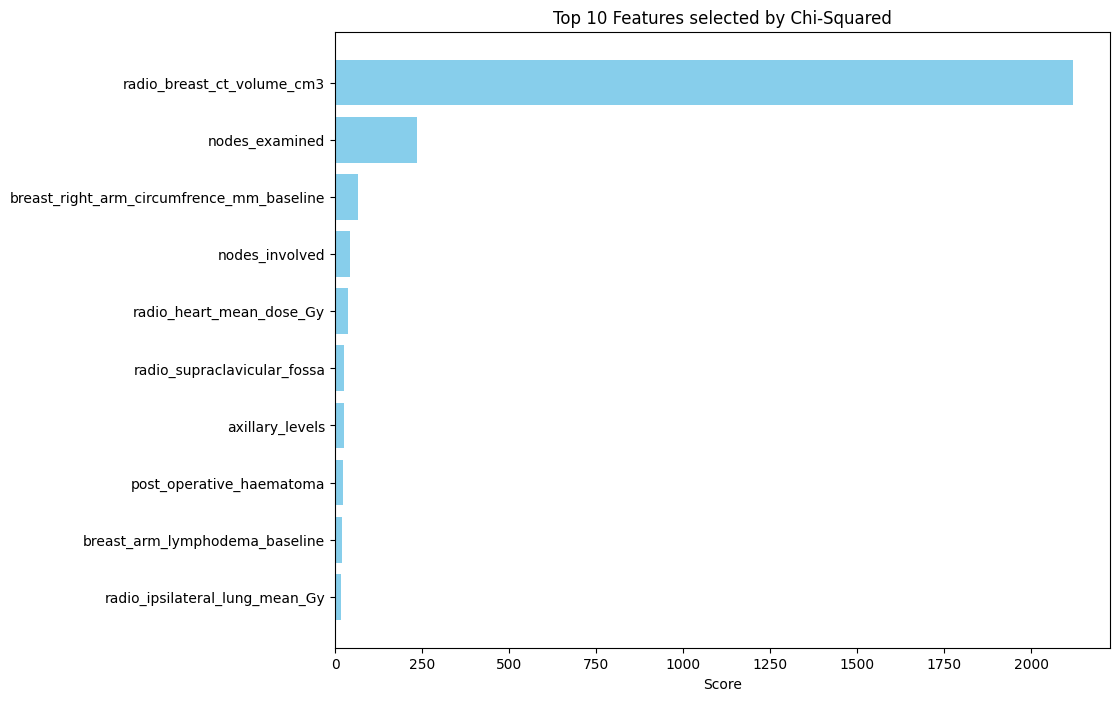

+----+-------------------------------------------+-----------+
|    | TopFeat                                   |     Score |
|----+-------------------------------------------+-----------|
| 43 | radio_breast_ct_volume_cm3                | 2120.51   |
| 24 | nodes_examined                            |  233.996  |
| 74 | breast_right_arm_circumfrence_mm_baseline |   66.1653 |
| 23 | nodes_involved                            |   43.0499 |
| 46 | radio_heart_mean_dose_Gy                  |   36.7033 |
| 55 | radio_supraclavicular_fossa               |   24.3045 |
| 54 | axillary_levels                           |   24.1731 |
| 25 | post_operative_haematoma                  |   23.8266 |
| 69 | breast_arm_lymphodema_baseline            |   18.9263 |
| 49 | radio_ipsilateral_lung_mean_Gy            |   18.2158 |
+----+-------------------------------------------+-----------+

List of top 10 features:
 ['radio_breast_ct_volume_cm3', 'nodes_examined', 'breast_right_arm_circumfrence_mm_baseline

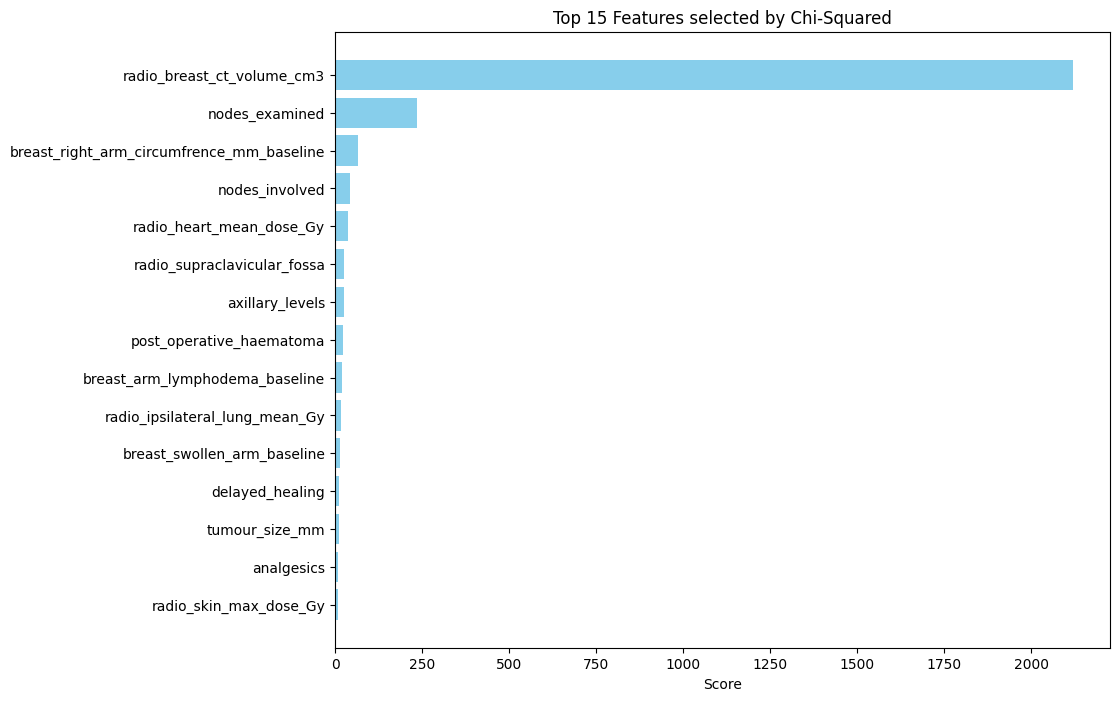

+----+-------------------------------------------+------------+
|    | TopFeat                                   |      Score |
|----+-------------------------------------------+------------|
| 43 | radio_breast_ct_volume_cm3                | 2120.51    |
| 24 | nodes_examined                            |  233.996   |
| 74 | breast_right_arm_circumfrence_mm_baseline |   66.1653  |
| 23 | nodes_involved                            |   43.0499  |
| 46 | radio_heart_mean_dose_Gy                  |   36.7033  |
| 55 | radio_supraclavicular_fossa               |   24.3045  |
| 54 | axillary_levels                           |   24.1731  |
| 25 | post_operative_haematoma                  |   23.8266  |
| 69 | breast_arm_lymphodema_baseline            |   18.9263  |
| 49 | radio_ipsilateral_lung_mean_Gy            |   18.2158  |
| 73 | breast_swollen_arm_baseline               |   15.0249  |
| 28 | delayed_healing                           |   11.1946  |
| 33 | tumour_size_mm                   

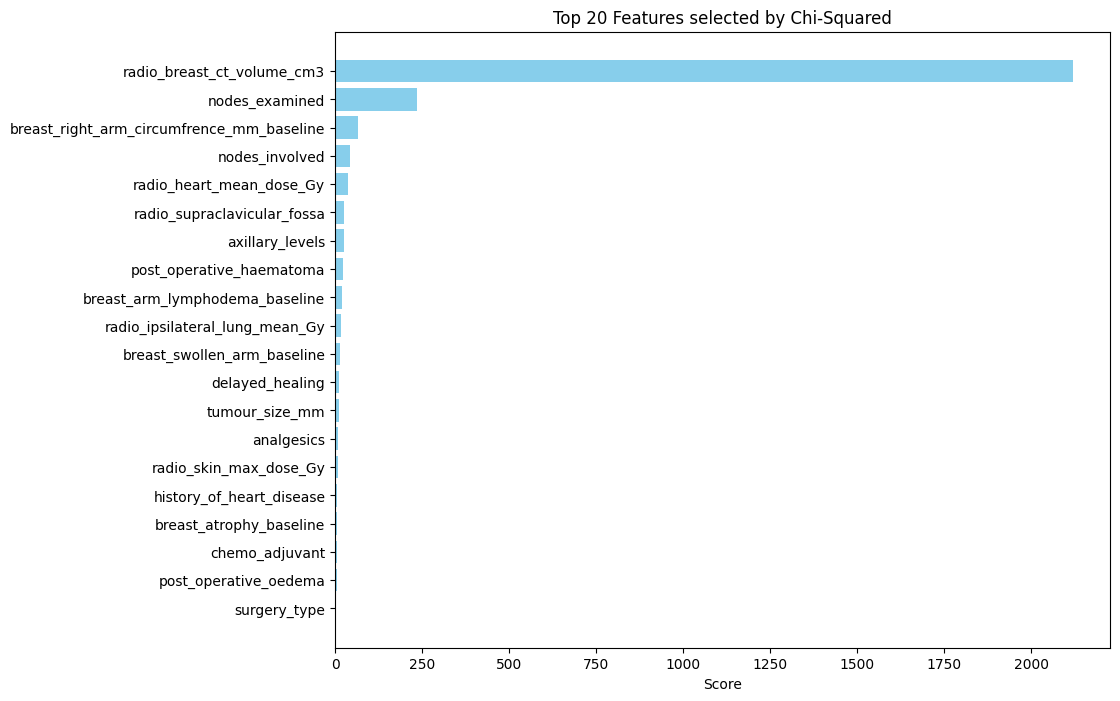

+----+-------------------------------------------+------------+
|    | TopFeat                                   |      Score |
|----+-------------------------------------------+------------|
| 43 | radio_breast_ct_volume_cm3                | 2120.51    |
| 24 | nodes_examined                            |  233.996   |
| 74 | breast_right_arm_circumfrence_mm_baseline |   66.1653  |
| 23 | nodes_involved                            |   43.0499  |
| 46 | radio_heart_mean_dose_Gy                  |   36.7033  |
| 55 | radio_supraclavicular_fossa               |   24.3045  |
| 54 | axillary_levels                           |   24.1731  |
| 25 | post_operative_haematoma                  |   23.8266  |
| 69 | breast_arm_lymphodema_baseline            |   18.9263  |
| 49 | radio_ipsilateral_lung_mean_Gy            |   18.2158  |
| 73 | breast_swollen_arm_baseline               |   15.0249  |
| 28 | delayed_healing                           |   11.1946  |
| 33 | tumour_size_mm                   

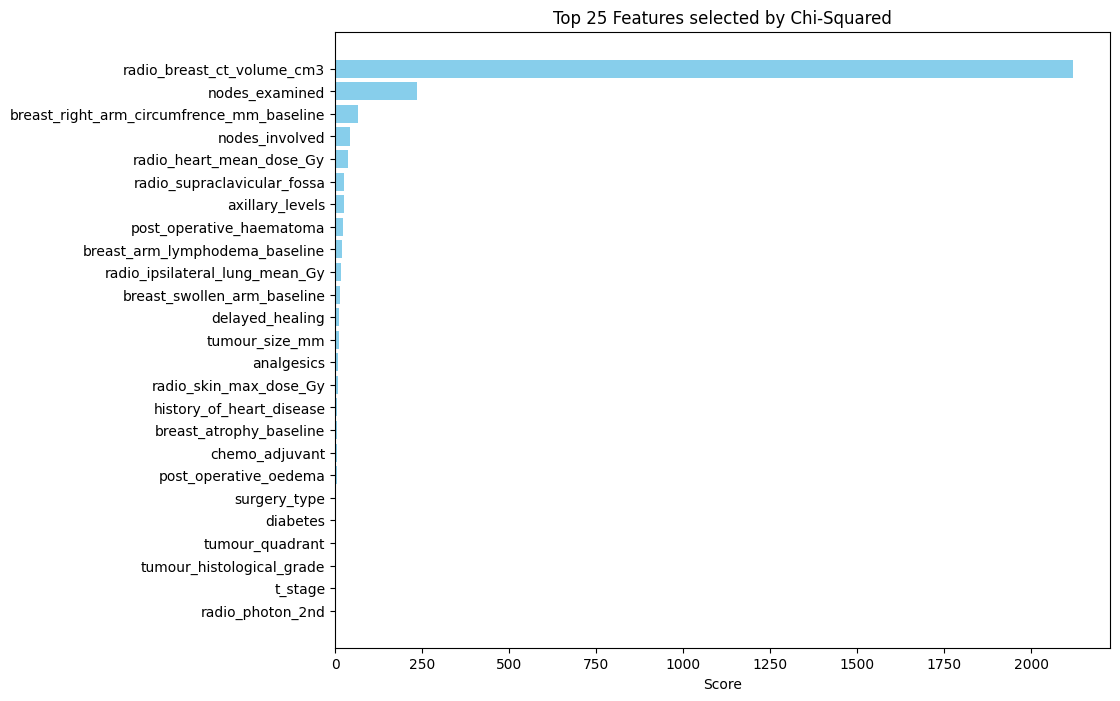

+----+-------------------------------------------+------------+
|    | TopFeat                                   |      Score |
|----+-------------------------------------------+------------|
| 43 | radio_breast_ct_volume_cm3                | 2120.51    |
| 24 | nodes_examined                            |  233.996   |
| 74 | breast_right_arm_circumfrence_mm_baseline |   66.1653  |
| 23 | nodes_involved                            |   43.0499  |
| 46 | radio_heart_mean_dose_Gy                  |   36.7033  |
| 55 | radio_supraclavicular_fossa               |   24.3045  |
| 54 | axillary_levels                           |   24.1731  |
| 25 | post_operative_haematoma                  |   23.8266  |
| 69 | breast_arm_lymphodema_baseline            |   18.9263  |
| 49 | radio_ipsilateral_lung_mean_Gy            |   18.2158  |
| 73 | breast_swollen_arm_baseline               |   15.0249  |
| 28 | delayed_healing                           |   11.1946  |
| 33 | tumour_size_mm                   

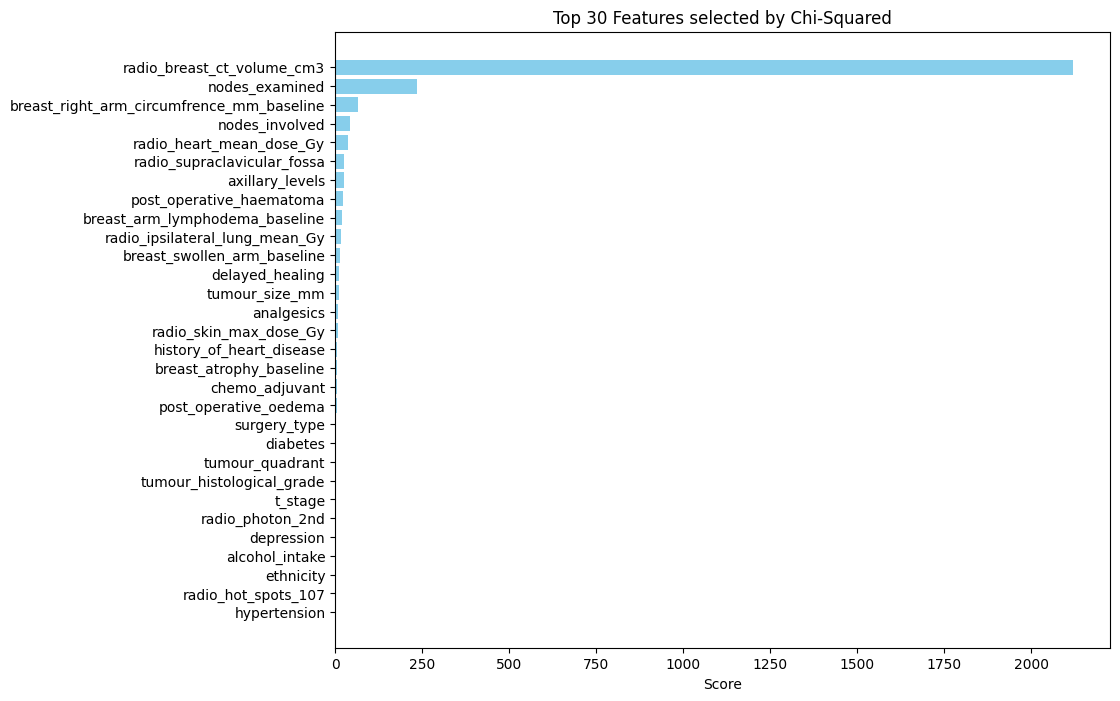

+----+-------------------------------------------+------------+
|    | TopFeat                                   |      Score |
|----+-------------------------------------------+------------|
| 43 | radio_breast_ct_volume_cm3                | 2120.51    |
| 24 | nodes_examined                            |  233.996   |
| 74 | breast_right_arm_circumfrence_mm_baseline |   66.1653  |
| 23 | nodes_involved                            |   43.0499  |
| 46 | radio_heart_mean_dose_Gy                  |   36.7033  |
| 55 | radio_supraclavicular_fossa               |   24.3045  |
| 54 | axillary_levels                           |   24.1731  |
| 25 | post_operative_haematoma                  |   23.8266  |
| 69 | breast_arm_lymphodema_baseline            |   18.9263  |
| 49 | radio_ipsilateral_lung_mean_Gy            |   18.2158  |
| 73 | breast_swollen_arm_baseline               |   15.0249  |
| 28 | delayed_healing                           |   11.1946  |
| 33 | tumour_size_mm                   

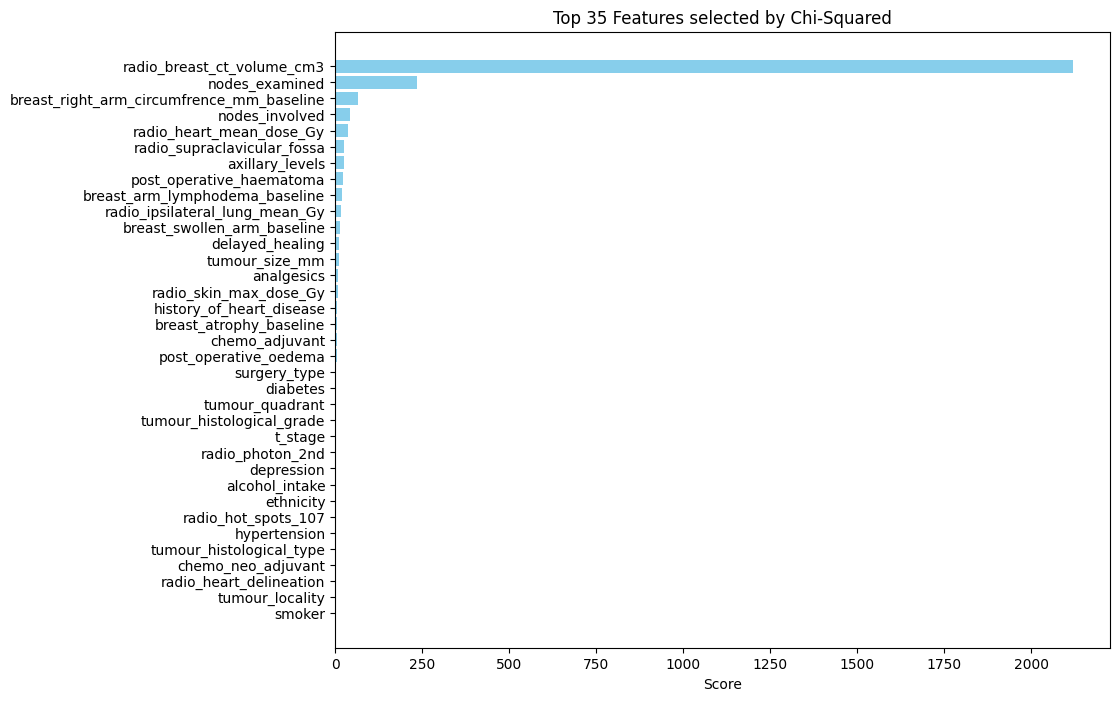

+----+-------------------------------------------+------------+
|    | TopFeat                                   |      Score |
|----+-------------------------------------------+------------|
| 43 | radio_breast_ct_volume_cm3                | 2120.51    |
| 24 | nodes_examined                            |  233.996   |
| 74 | breast_right_arm_circumfrence_mm_baseline |   66.1653  |
| 23 | nodes_involved                            |   43.0499  |
| 46 | radio_heart_mean_dose_Gy                  |   36.7033  |
| 55 | radio_supraclavicular_fossa               |   24.3045  |
| 54 | axillary_levels                           |   24.1731  |
| 25 | post_operative_haematoma                  |   23.8266  |
| 69 | breast_arm_lymphodema_baseline            |   18.9263  |
| 49 | radio_ipsilateral_lung_mean_Gy            |   18.2158  |
| 73 | breast_swollen_arm_baseline               |   15.0249  |
| 28 | delayed_healing                           |   11.1946  |
| 33 | tumour_size_mm                   

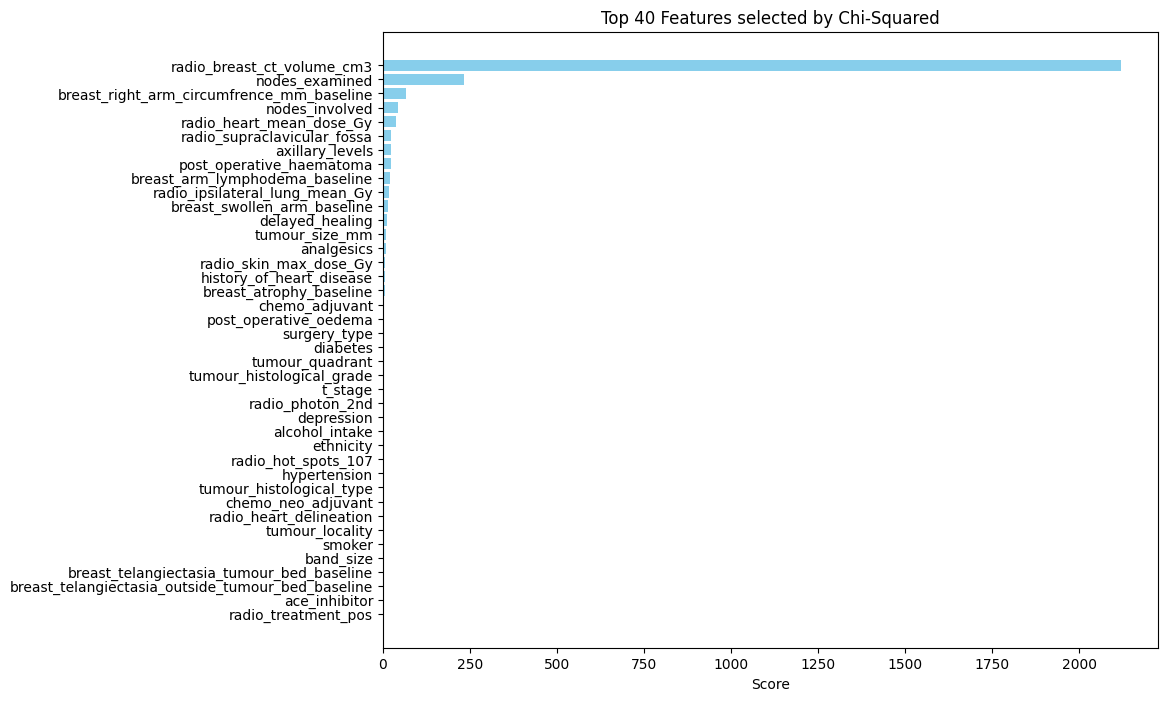

+----+---------------------------------------------------+-------------+
|    | TopFeat                                           |       Score |
|----+---------------------------------------------------+-------------|
| 43 | radio_breast_ct_volume_cm3                        | 2120.51     |
| 24 | nodes_examined                                    |  233.996    |
| 74 | breast_right_arm_circumfrence_mm_baseline         |   66.1653   |
| 23 | nodes_involved                                    |   43.0499   |
| 46 | radio_heart_mean_dose_Gy                          |   36.7033   |
| 55 | radio_supraclavicular_fossa                       |   24.3045   |
| 54 | axillary_levels                                   |   24.1731   |
| 25 | post_operative_haematoma                          |   23.8266   |
| 69 | breast_arm_lymphodema_baseline                    |   18.9263   |
| 49 | radio_ipsilateral_lung_mean_Gy                    |   18.2158   |
| 73 | breast_swollen_arm_baseline                 

In [447]:
feature_sets_univariate_nonscaled = {}

for i in k:
    freq_df_nonscaled_auc= featureselection1(df_clinic_20, dependent1, k=i)
    feature_sets_univariate_nonscaled[i] = freq_df_nonscaled_auc

In [364]:
from collections import Counter

def get_stable_features(feature_sets, threshold_ratio=0.8):
    """
    Select features appearing in at least threshold_ratio of the sets.

    Parameters
    ----------
    feature_sets : dict
        Format:
        {
            k: (dataframe, auc_score)
        }

    threshold_ratio : float
        Minimum proportion of sets a feature must appear in.
        Example:
            0.8 = 80%

    Returns
    -------
    list
        Stable feature names only
    """

    feature_counter = Counter()

    n_sets = len(feature_sets)

    for k, (df, auc) in feature_sets.items():

        # Get top-k features based on score
        top_features = (
            df.sort_values('Score', ascending=False)
              .head(k)['TopFeat']
              .tolist()
        )

        feature_counter.update(top_features)

    threshold = int(threshold_ratio * n_sets)

    stable_features = [
        feature for feature, count in feature_counter.items()
        if count >= threshold
    ]

    return stable_features

In [448]:
stable_features_univariate_nonscaled = get_stable_features(
    feature_sets_univariate_nonscaled,
    threshold_ratio=0.8
)

print(stable_features_univariate_nonscaled)
print ('Number of features', len(stable_features_univariate_nonscaled))

['radio_breast_ct_volume_cm3', 'nodes_examined', 'breast_right_arm_circumfrence_mm_baseline', 'nodes_involved', 'radio_heart_mean_dose_Gy', 'radio_supraclavicular_fossa', 'axillary_levels', 'post_operative_haematoma', 'breast_arm_lymphodema_baseline', 'radio_ipsilateral_lung_mean_Gy', 'breast_swollen_arm_baseline', 'delayed_healing', 'tumour_size_mm', 'analgesics', 'radio_skin_max_dose_Gy', 'history_of_heart_disease', 'breast_atrophy_baseline', 'chemo_adjuvant', 'post_operative_oedema', 'surgery_type']
Number of features 20


In [449]:
cross_validated_feature_selection(df_clinic_20[stable_features_univariate_nonscaled + [dependent1]], dependent1, 10)

Original Data shape is (2067, 21)
Data shape after dropping missing target: (1691, 21)
✅ Mean AUC with final selected features: 0.8197


### scaled

In [367]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# this function same as above week performance but with scaling
# Done on whole dataset, with scaling, Data Leakage, Overestimates true performance due to leakage.

def featureselection1_scaled(df, dependent, k):
    # Drop rows with missing values
    df = df.dropna(axis=0, how='any')

    # Separate features and target variable
    X = df.drop(columns=[dependent, 'Subject Id'])
    y = df[dependent]

    # Convert categorical variables into numeric
    X = pd.get_dummies(X, drop_first=True)
    # Keep only numeric features and scale for Chi2
    #X = X.select_dtypes(include=['number'])
    X_scaled = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns)

    # Apply Chi2 feature selection
    selector = SelectKBest(score_func=chi2, k=k)
    selector.fit(X_scaled, y)

    # Score and extract top features
    scores = selector.scores_
    # Create a DataFrame for all features and their scores
    all_features_scores = pd.DataFrame({
        'TopFeat': X.columns,
        'Score': scores
    })
    # Select the top k features for plotting/printing
    top_k_features_for_display = all_features_scores.nlargest(k, 'Score')

    selected_features = top_k_features_for_display['TopFeat'].tolist()

    # Plot
    plt.figure(figsize=(10, 8))
    plt.barh(top_k_features_for_display['TopFeat'], top_k_features_for_display['Score'], color='skyblue')
    plt.xlabel('Score')
    plt.title(f'Top {k} Features selected by Chi-Squared')
    plt.gca().invert_yaxis()
    plt.show()

    # Print results
    print(tabulate(top_k_features_for_display, headers='keys', tablefmt='psql'))
    print(f"\nList of top {k} features:\n", selected_features, '\n\n')

    # Prepare data with selected features only
    X_selected = X_scaled[selected_features]

    # Build pipeline and evaluate using cross-validation
    pipeline = Pipeline([
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, min_samples_leaf=1,bootstrap=True, random_state=5))
    ])

    # Use StratifiedKFold and calculate mean AUC
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    auc_scores = cross_val_score(pipeline, X_selected, y, cv=skf, scoring='roc_auc')

    print(f"Mean AUC score using top {k} features: {auc_scores.mean():.4f}")
    print("\n\t********************************************************************************************************************************************************************")
    return all_features_scores, auc_scores.mean() # Ensure this returns a DataFrame as the first element

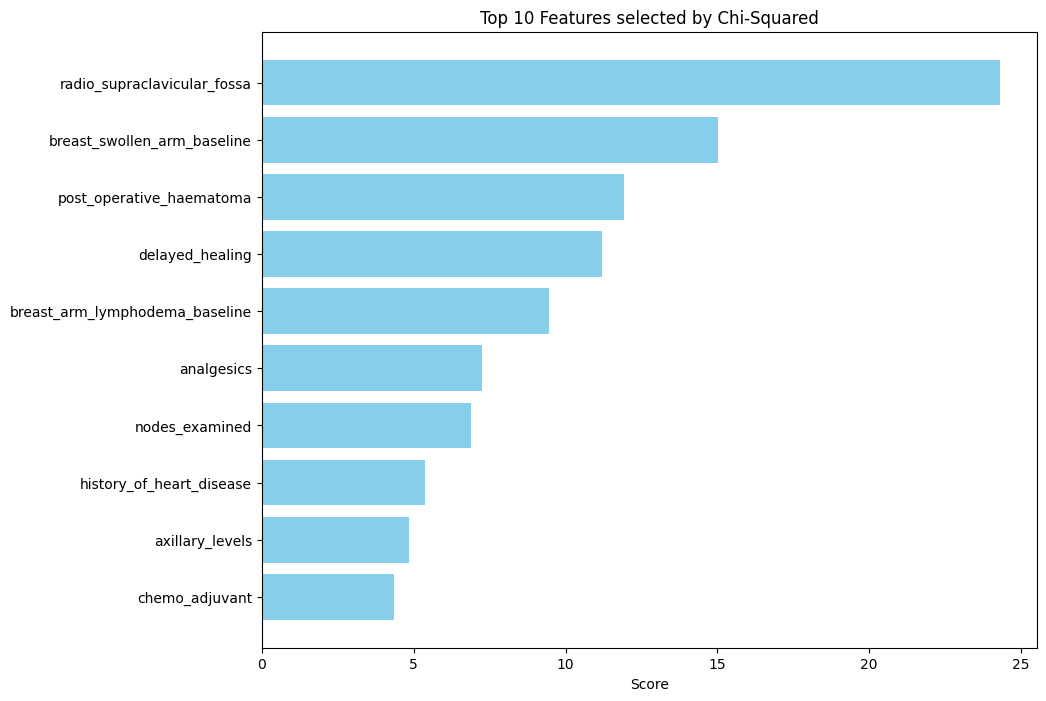

+----+--------------------------------+----------+
|    | TopFeat                        |    Score |
|----+--------------------------------+----------|
| 55 | radio_supraclavicular_fossa    | 24.3045  |
| 73 | breast_swollen_arm_baseline    | 15.0249  |
| 25 | post_operative_haematoma       | 11.9133  |
| 28 | delayed_healing                | 11.1946  |
| 69 | breast_arm_lymphodema_baseline |  9.46316 |
| 18 | analgesics                     |  7.26318 |
| 24 | nodes_examined                 |  6.88225 |
|  8 | history_of_heart_disease       |  5.38146 |
| 54 | axillary_levels                |  4.83462 |
| 39 | chemo_adjuvant                 |  4.35234 |
+----+--------------------------------+----------+

List of top 10 features:
 ['radio_supraclavicular_fossa', 'breast_swollen_arm_baseline', 'post_operative_haematoma', 'delayed_healing', 'breast_arm_lymphodema_baseline', 'analgesics', 'nodes_examined', 'history_of_heart_disease', 'axillary_levels', 'chemo_adjuvant'] 


Mean AUC score 

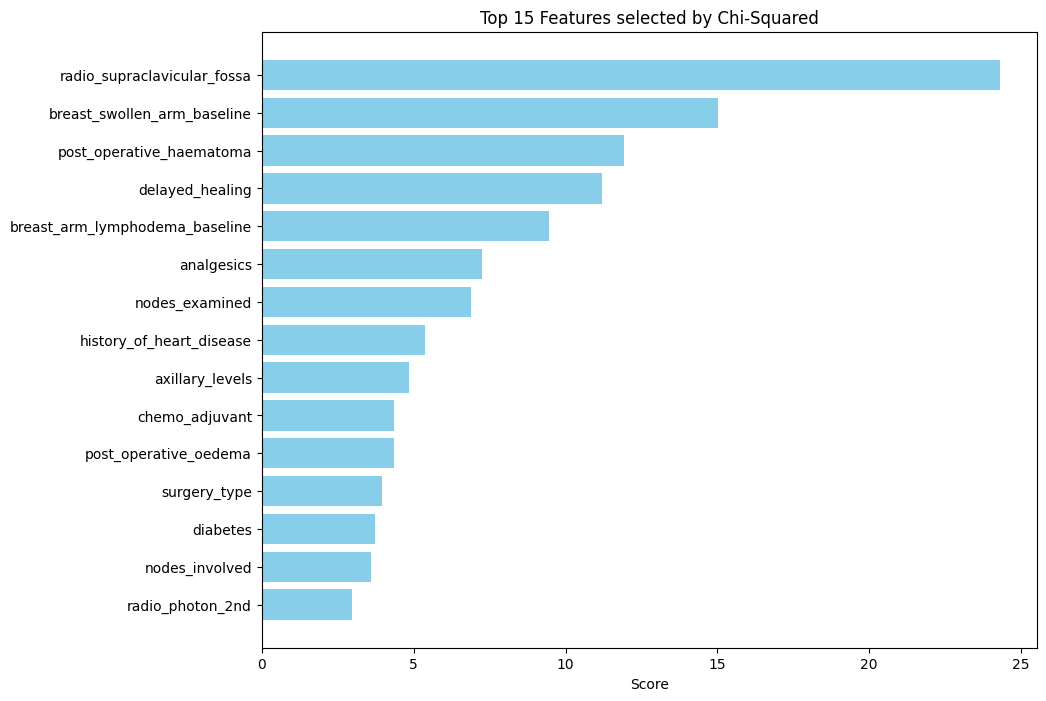

+----+--------------------------------+----------+
|    | TopFeat                        |    Score |
|----+--------------------------------+----------|
| 55 | radio_supraclavicular_fossa    | 24.3045  |
| 73 | breast_swollen_arm_baseline    | 15.0249  |
| 25 | post_operative_haematoma       | 11.9133  |
| 28 | delayed_healing                | 11.1946  |
| 69 | breast_arm_lymphodema_baseline |  9.46316 |
| 18 | analgesics                     |  7.26318 |
| 24 | nodes_examined                 |  6.88225 |
|  8 | history_of_heart_disease       |  5.38146 |
| 54 | axillary_levels                |  4.83462 |
| 39 | chemo_adjuvant                 |  4.35234 |
| 26 | post_operative_oedema          |  4.33546 |
| 22 | surgery_type                   |  3.95505 |
|  7 | diabetes                       |  3.72635 |
| 23 | nodes_involved                 |  3.58749 |
| 58 | radio_photon_2nd               |  2.95401 |
+----+--------------------------------+----------+

List of top 15 features:
 ['ra

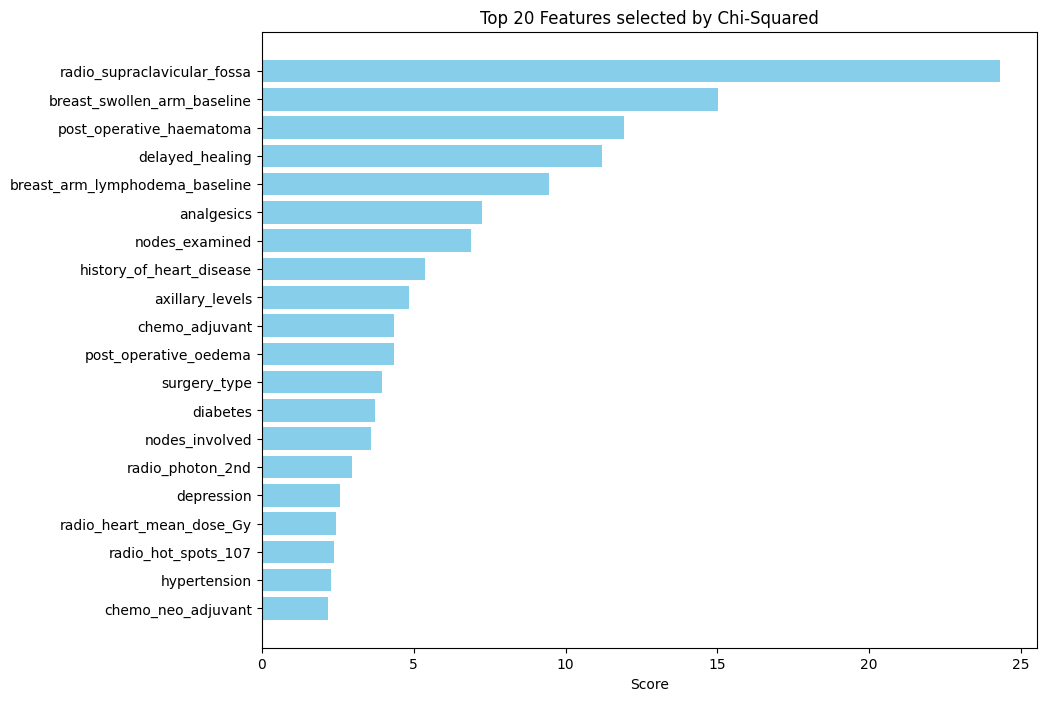

+----+--------------------------------+----------+
|    | TopFeat                        |    Score |
|----+--------------------------------+----------|
| 55 | radio_supraclavicular_fossa    | 24.3045  |
| 73 | breast_swollen_arm_baseline    | 15.0249  |
| 25 | post_operative_haematoma       | 11.9133  |
| 28 | delayed_healing                | 11.1946  |
| 69 | breast_arm_lymphodema_baseline |  9.46316 |
| 18 | analgesics                     |  7.26318 |
| 24 | nodes_examined                 |  6.88225 |
|  8 | history_of_heart_disease       |  5.38146 |
| 54 | axillary_levels                |  4.83462 |
| 39 | chemo_adjuvant                 |  4.35234 |
| 26 | post_operative_oedema          |  4.33546 |
| 22 | surgery_type                   |  3.95505 |
|  7 | diabetes                       |  3.72635 |
| 23 | nodes_involved                 |  3.58749 |
| 58 | radio_photon_2nd               |  2.95401 |
| 13 | depression                     |  2.57778 |
| 46 | radio_heart_mean_dose_Gy

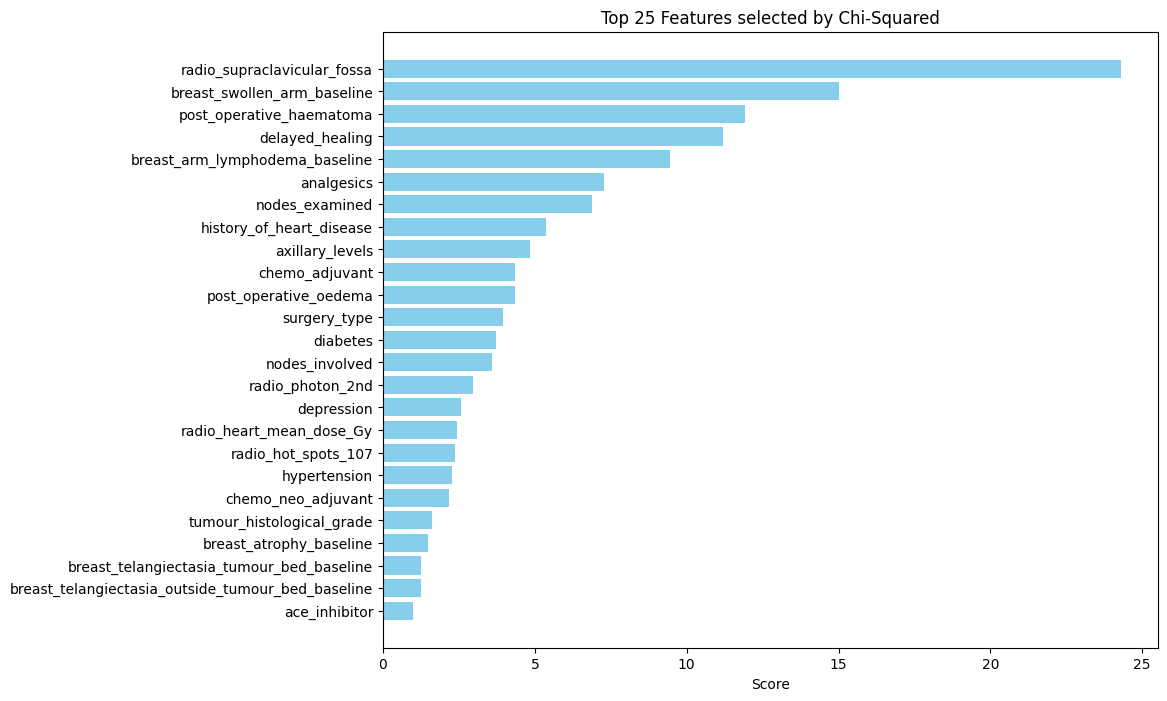

+----+---------------------------------------------------+-----------+
|    | TopFeat                                           |     Score |
|----+---------------------------------------------------+-----------|
| 55 | radio_supraclavicular_fossa                       | 24.3045   |
| 73 | breast_swollen_arm_baseline                       | 15.0249   |
| 25 | post_operative_haematoma                          | 11.9133   |
| 28 | delayed_healing                                   | 11.1946   |
| 69 | breast_arm_lymphodema_baseline                    |  9.46316  |
| 18 | analgesics                                        |  7.26318  |
| 24 | nodes_examined                                    |  6.88225  |
|  8 | history_of_heart_disease                          |  5.38146  |
| 54 | axillary_levels                                   |  4.83462  |
| 39 | chemo_adjuvant                                    |  4.35234  |
| 26 | post_operative_oedema                             |  4.33546  |
| 22 |

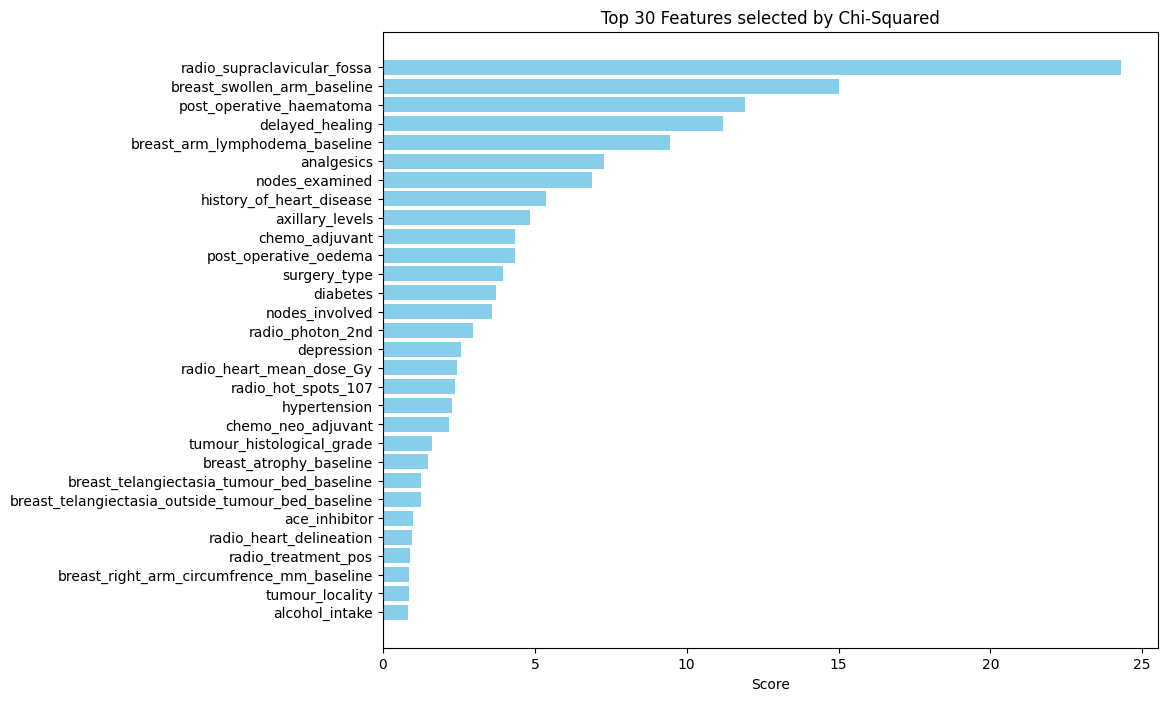

+----+---------------------------------------------------+-----------+
|    | TopFeat                                           |     Score |
|----+---------------------------------------------------+-----------|
| 55 | radio_supraclavicular_fossa                       | 24.3045   |
| 73 | breast_swollen_arm_baseline                       | 15.0249   |
| 25 | post_operative_haematoma                          | 11.9133   |
| 28 | delayed_healing                                   | 11.1946   |
| 69 | breast_arm_lymphodema_baseline                    |  9.46316  |
| 18 | analgesics                                        |  7.26318  |
| 24 | nodes_examined                                    |  6.88225  |
|  8 | history_of_heart_disease                          |  5.38146  |
| 54 | axillary_levels                                   |  4.83462  |
| 39 | chemo_adjuvant                                    |  4.35234  |
| 26 | post_operative_oedema                             |  4.33546  |
| 22 |

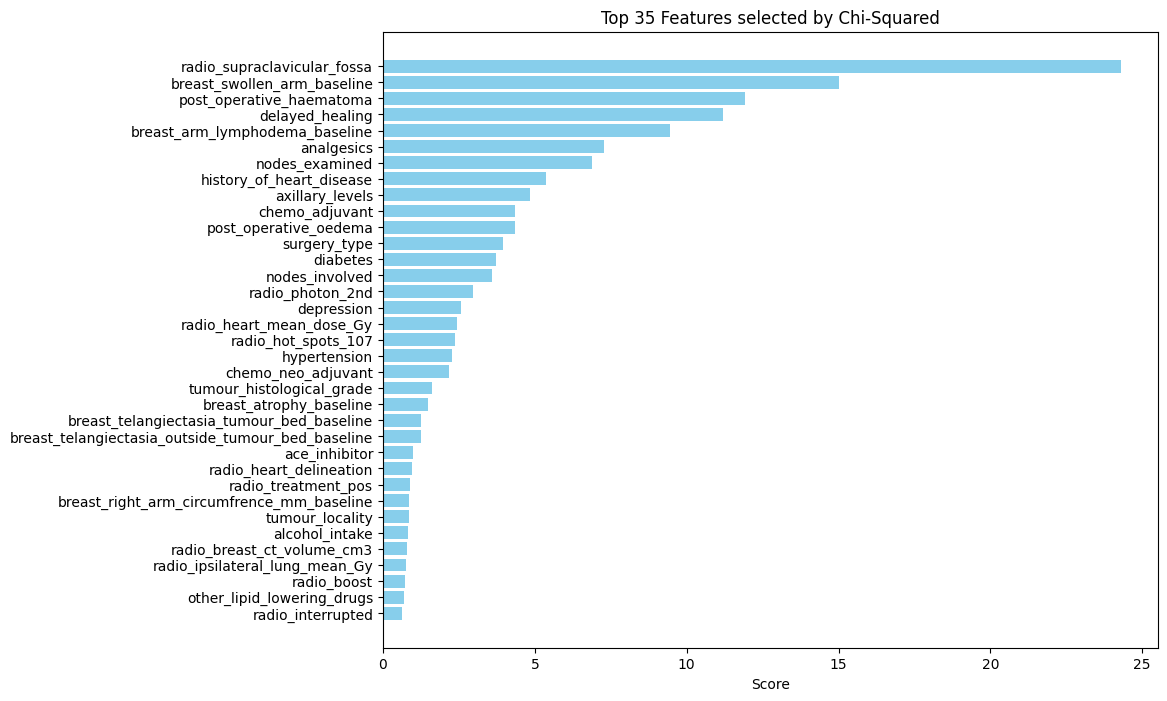

+----+---------------------------------------------------+-----------+
|    | TopFeat                                           |     Score |
|----+---------------------------------------------------+-----------|
| 55 | radio_supraclavicular_fossa                       | 24.3045   |
| 73 | breast_swollen_arm_baseline                       | 15.0249   |
| 25 | post_operative_haematoma                          | 11.9133   |
| 28 | delayed_healing                                   | 11.1946   |
| 69 | breast_arm_lymphodema_baseline                    |  9.46316  |
| 18 | analgesics                                        |  7.26318  |
| 24 | nodes_examined                                    |  6.88225  |
|  8 | history_of_heart_disease                          |  5.38146  |
| 54 | axillary_levels                                   |  4.83462  |
| 39 | chemo_adjuvant                                    |  4.35234  |
| 26 | post_operative_oedema                             |  4.33546  |
| 22 |

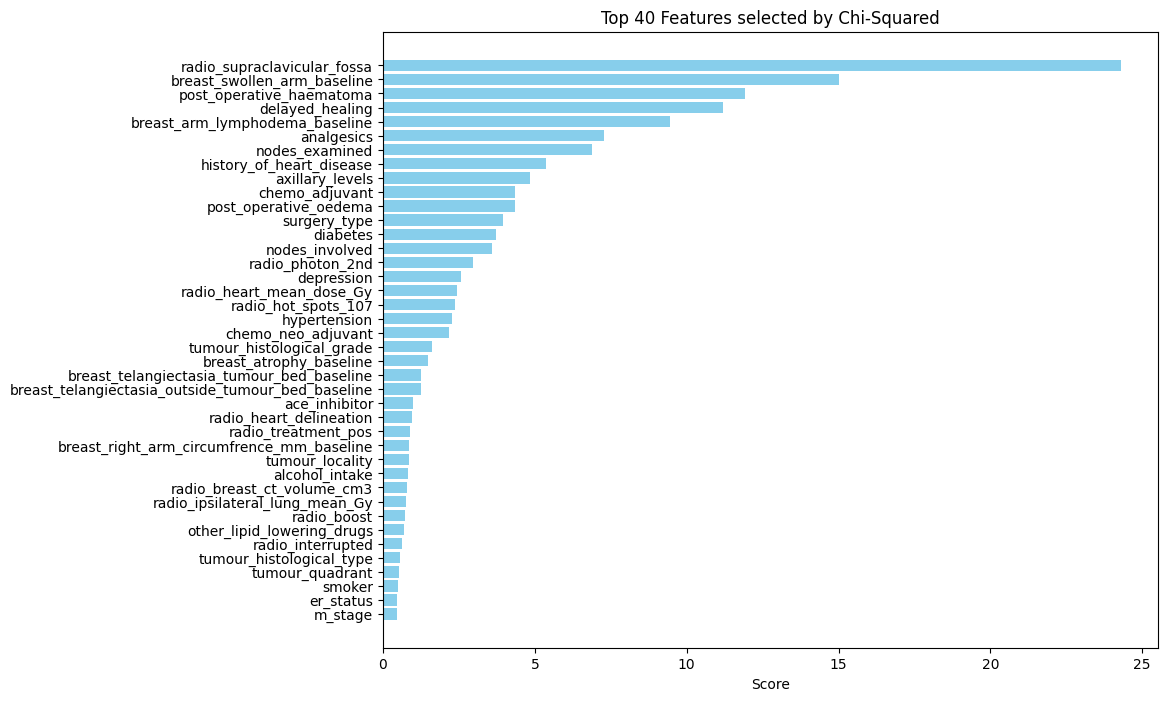

+----+---------------------------------------------------+-----------+
|    | TopFeat                                           |     Score |
|----+---------------------------------------------------+-----------|
| 55 | radio_supraclavicular_fossa                       | 24.3045   |
| 73 | breast_swollen_arm_baseline                       | 15.0249   |
| 25 | post_operative_haematoma                          | 11.9133   |
| 28 | delayed_healing                                   | 11.1946   |
| 69 | breast_arm_lymphodema_baseline                    |  9.46316  |
| 18 | analgesics                                        |  7.26318  |
| 24 | nodes_examined                                    |  6.88225  |
|  8 | history_of_heart_disease                          |  5.38146  |
| 54 | axillary_levels                                   |  4.83462  |
| 39 | chemo_adjuvant                                    |  4.35234  |
| 26 | post_operative_oedema                             |  4.33546  |
| 22 |

In [450]:
feature_sets_univariate_scaled = {}

for i in k:
    freq_df_scaled_auc= featureselection1_scaled(df_clinic_20, dependent1, k=i)
    feature_sets_univariate_scaled[i] = freq_df_scaled_auc

In [451]:
stable_features_univariate_scaled = get_stable_features(
    feature_sets_univariate_scaled,
    threshold_ratio=0.8
)

print(stable_features_univariate_scaled)
print ('Number of features', len(stable_features_univariate_scaled))

['radio_supraclavicular_fossa', 'breast_swollen_arm_baseline', 'post_operative_haematoma', 'delayed_healing', 'breast_arm_lymphodema_baseline', 'analgesics', 'nodes_examined', 'history_of_heart_disease', 'axillary_levels', 'chemo_adjuvant', 'post_operative_oedema', 'surgery_type', 'diabetes', 'nodes_involved', 'radio_photon_2nd', 'depression', 'radio_heart_mean_dose_Gy', 'radio_hot_spots_107', 'hypertension', 'chemo_neo_adjuvant']
Number of features 20


In [452]:
cross_validated_feature_selection(df_clinic_20[stable_features_univariate_scaled + [dependent1]], dependent1, 10)

Original Data shape is (2067, 21)
Data shape after dropping missing target: (1691, 21)
✅ Mean AUC with final selected features: 0.8477


### inside CV

In [371]:
# ✅ Inside CV folds	✅ Yes With scaling	✅ Clean no leakage	📉 True estimate of performance

def featureselection1_pipeline_auc(df, dependent, k):
    df = df.dropna()

    # Separate features and target variable
    X = df.drop(columns=[dependent, 'Subject Id'])
    y = df[dependent]

    # Convert categorical variables into numeric
    X = pd.get_dummies(X, drop_first=True)

    # Build pipeline with scaling, feature selection, and classification
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('selectk', SelectKBest(score_func=chi2, k=k)),
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, min_samples_leaf=1,bootstrap=True, random_state=5))
    ])

    # Cross-validation setup
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    auc_scores = cross_val_score(pipeline, X, y, cv=skf, scoring='roc_auc')

    print(f"Mean AUC score using top {k} features (Inside CV): {auc_scores.mean():.2f}")
    return auc_scores.mean()


In [453]:
# This is the one I took for my feature selection heatmap # The results may vary because I filled remove all missing data and the data could be small
# without seening any features_quick way to see the results
for i in k:
  Mean_auc_scores_CV_inside_pipeline= featureselection1_pipeline_auc(df_clinic_20, dependent1, k=i)

Mean AUC score using top 10 features (Inside CV): 0.76
Mean AUC score using top 15 features (Inside CV): 0.81
Mean AUC score using top 20 features (Inside CV): 0.82
Mean AUC score using top 25 features (Inside CV): 0.81
Mean AUC score using top 30 features (Inside CV): 0.82
Mean AUC score using top 35 features (Inside CV): 0.84
Mean AUC score using top 40 features (Inside CV): 0.83


**Takeaways4,** in above analysis this is a real and true feature selection as only happens in the training set,,, But there is an issue because  it is not only model building I need to look at the important features and observe their importance.

### features frequency inside Pipeline

In [373]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

def featureselection1_scaled_inside_pipeline(df, dependent, k, n_splits):
    df = df.dropna(axis=0, how='any')
    # Separate features and target variable
    X = df.drop(columns=[dependent, 'Subject Id'])
    y = df[dependent]

    # Convert categorical variables into numeric
    X = pd.get_dummies(X, drop_first=True)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    feature_counter = Counter()
    auc_scores = []

    #bold("Choosing " + str(k) + " Features:\n")

    for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y), start=1):

        X_train, y_train = X.iloc[train_index], y.iloc[train_index]
        X_test, y_test = X.iloc[test_index], y.iloc[test_index]

        # Apply Chi2 on training fold
        pipeline = Pipeline([
            ('scaler', MinMaxScaler()),
            ('feature_selection', SelectKBest(score_func=chi2, k=k)),
            ('model', RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=1,
                bootstrap=True,
                random_state=5
            ))
        ])

        pipeline.fit(X_train, y_train)

        # Get predicted probabilities for AUC calculation
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        auc_scores.append(auc)

        selected_mask = pipeline.named_steps['feature_selection'].get_support()
        selected_features = X.columns[selected_mask].tolist()

        feature_counter.update(selected_features)

        print(
            f"Fold {fold_idx}: Selected features: {selected_features} | AUC: {auc:.4f}"
        )

    # Calculate the mean AUC
    mean_auc = np.mean(auc_scores)
    print(f"\nMean AUC using top {k} features across {n_splits} folds: {mean_auc:.4f}\n")

    # Convert to DataFrame
    freq_df = pd.DataFrame.from_dict(feature_counter, orient='index', columns=['Frequency'])
    freq_df = freq_df.sort_values(by='Frequency', ascending=False)

    # Plot feature frequency
    plt.figure(figsize=(10, 12))
    sns.barplot(x='Frequency', y=freq_df.index, data=freq_df, palette='magma')
    plt.xlabel('Selection Frequency')
    plt.ylabel('KBest Features')
    plt.title(f'Chi2 Feature Selection Frequency Across {n_splits} Folds (Top {k} features/fold)')
    plt.xticks(np.arange(0, n_splits+1, 1))
    plt.show()

    print(tabulate(freq_df, headers='keys', tablefmt='psql'))
    top_features_final = freq_df.head(k).index.tolist()

    print(f"Top {k} most frequently Features across {n_splits} folds:", top_features_final)
    #print(top_features_final)
    print("\n\t*****************************************************************************************************************************************************************\n\n")

    return freq_df, mean_auc


Fold 1: Selected features: ['diabetes', 'analgesics', 'nodes_examined', 'post_operative_haematoma', 'delayed_healing', 'chemo_adjuvant', 'radio_supraclavicular_fossa', 'radio_photon_2nd', 'breast_arm_lymphodema_baseline', 'breast_swollen_arm_baseline'] | AUC: 0.8108
Fold 2: Selected features: ['analgesics', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'delayed_healing', 'chemo_adjuvant', 'axillary_levels', 'radio_supraclavicular_fossa', 'breast_arm_lymphodema_baseline', 'breast_swollen_arm_baseline'] | AUC: 0.6111
Fold 3: Selected features: ['diabetes', 'history_of_heart_disease', 'analgesics', 'nodes_examined', 'post_operative_haematoma', 'delayed_healing', 'radio_supraclavicular_fossa', 'radio_photon_2nd', 'breast_arm_lymphodema_baseline', 'breast_swollen_arm_baseline'] | AUC: 0.7188
Fold 4: Selected features: ['history_of_heart_disease', 'analgesics', 'surgery_type', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'axillary_levels', 'radio_supracla

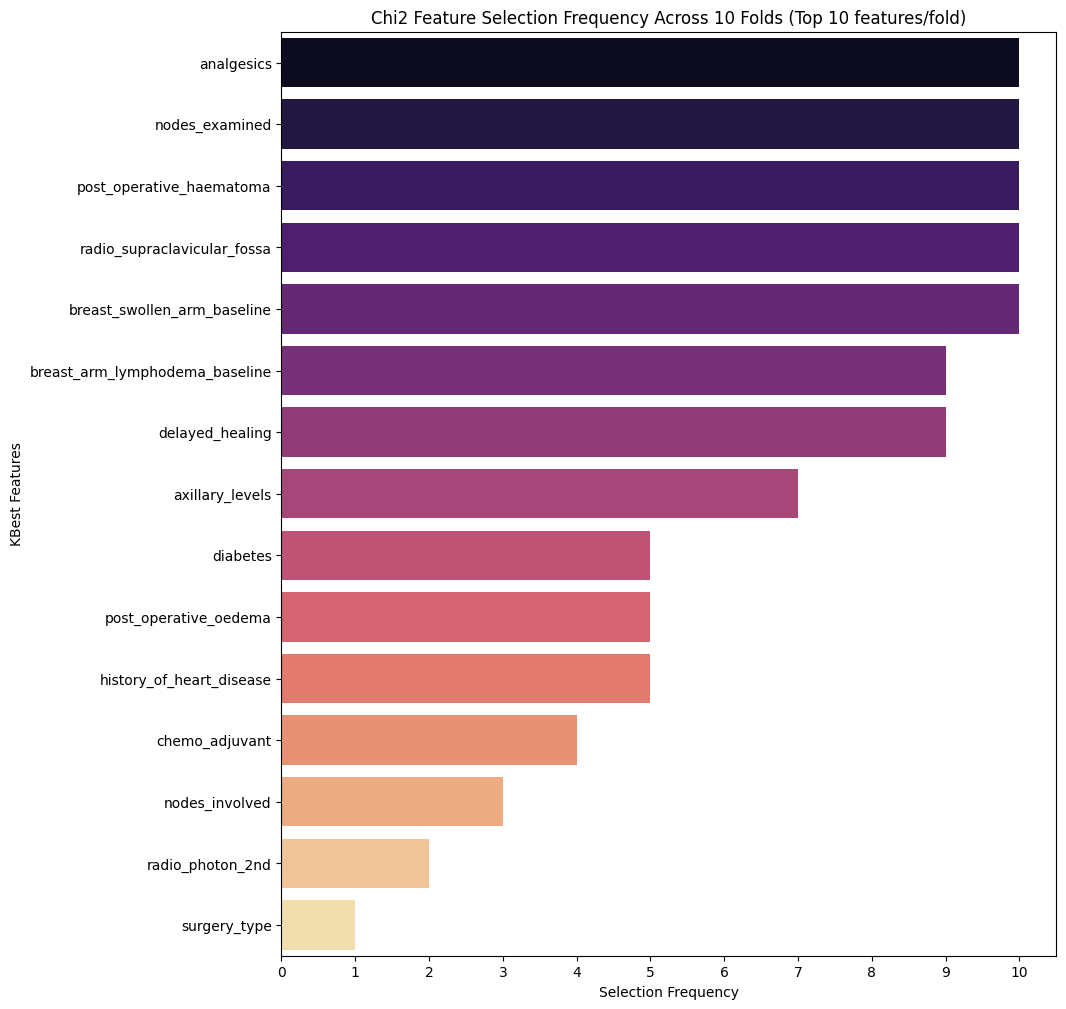

+--------------------------------+-------------+
|                                |   Frequency |
|--------------------------------+-------------|
| analgesics                     |          10 |
| nodes_examined                 |          10 |
| post_operative_haematoma       |          10 |
| radio_supraclavicular_fossa    |          10 |
| breast_swollen_arm_baseline    |          10 |
| breast_arm_lymphodema_baseline |           9 |
| delayed_healing                |           9 |
| axillary_levels                |           7 |
| diabetes                       |           5 |
| post_operative_oedema          |           5 |
| history_of_heart_disease       |           5 |
| chemo_adjuvant                 |           4 |
| nodes_involved                 |           3 |
| radio_photon_2nd               |           2 |
| surgery_type                   |           1 |
+--------------------------------+-------------+
Top 10 most frequently Features across 10 folds: ['analgesics', 'node

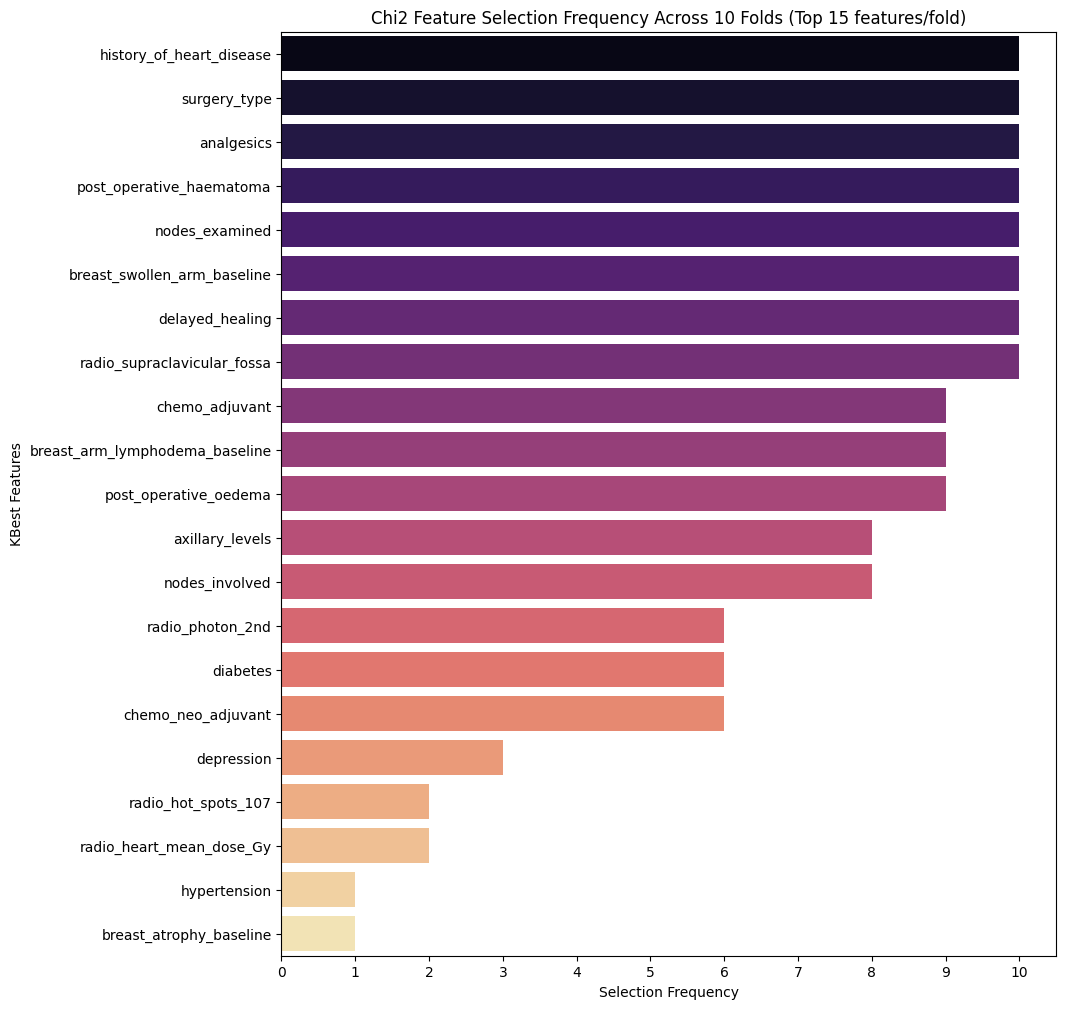

+--------------------------------+-------------+
|                                |   Frequency |
|--------------------------------+-------------|
| history_of_heart_disease       |          10 |
| surgery_type                   |          10 |
| analgesics                     |          10 |
| post_operative_haematoma       |          10 |
| nodes_examined                 |          10 |
| breast_swollen_arm_baseline    |          10 |
| delayed_healing                |          10 |
| radio_supraclavicular_fossa    |          10 |
| chemo_adjuvant                 |           9 |
| breast_arm_lymphodema_baseline |           9 |
| post_operative_oedema          |           9 |
| axillary_levels                |           8 |
| nodes_involved                 |           8 |
| radio_photon_2nd               |           6 |
| diabetes                       |           6 |
| chemo_neo_adjuvant             |           6 |
| depression                     |           3 |
| radio_hot_spots_10

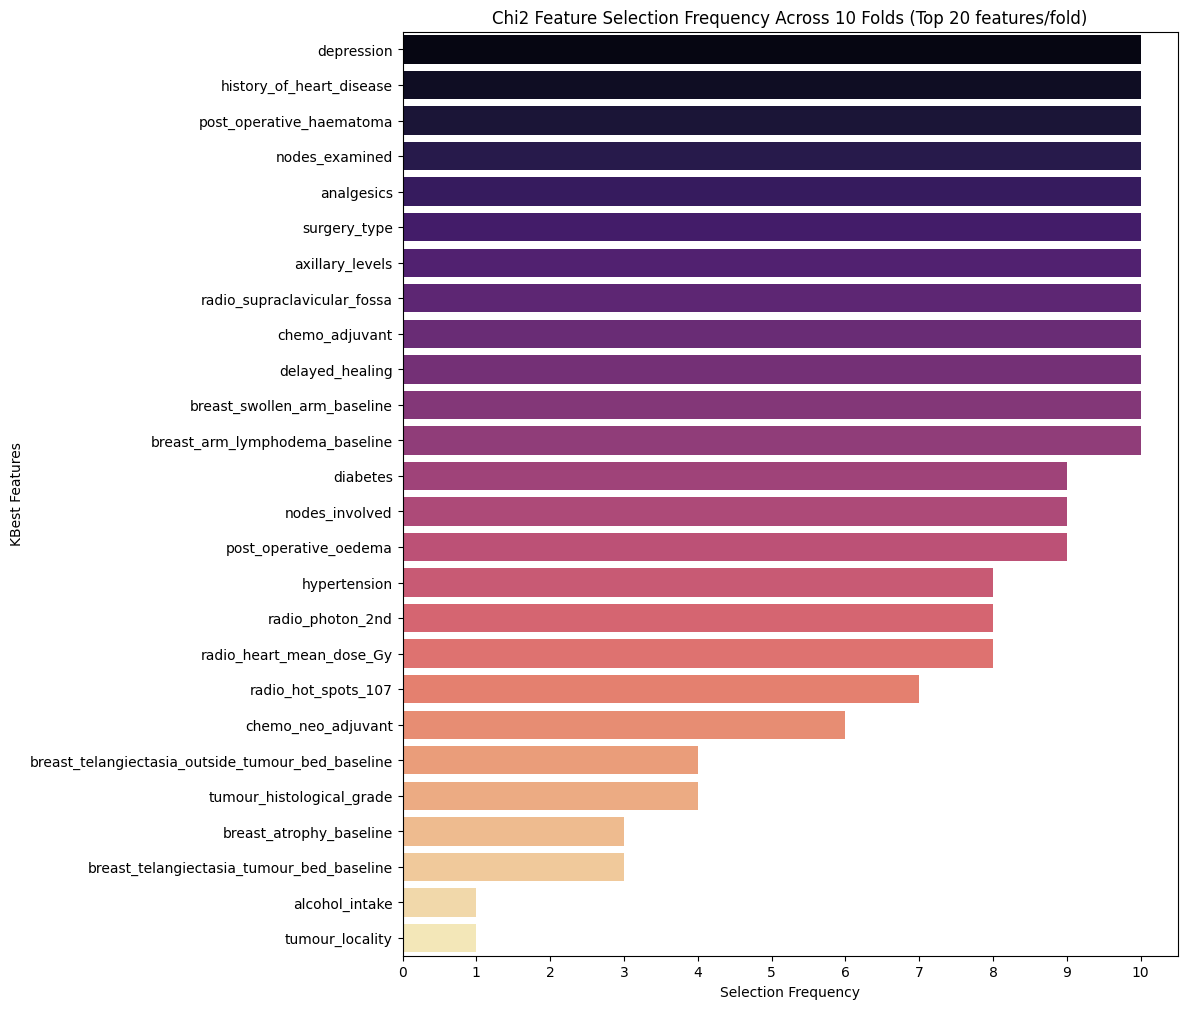

+---------------------------------------------------+-------------+
|                                                   |   Frequency |
|---------------------------------------------------+-------------|
| depression                                        |          10 |
| history_of_heart_disease                          |          10 |
| post_operative_haematoma                          |          10 |
| nodes_examined                                    |          10 |
| analgesics                                        |          10 |
| surgery_type                                      |          10 |
| axillary_levels                                   |          10 |
| radio_supraclavicular_fossa                       |          10 |
| chemo_adjuvant                                    |          10 |
| delayed_healing                                   |          10 |
| breast_swollen_arm_baseline                       |          10 |
| breast_arm_lymphodema_baseline                

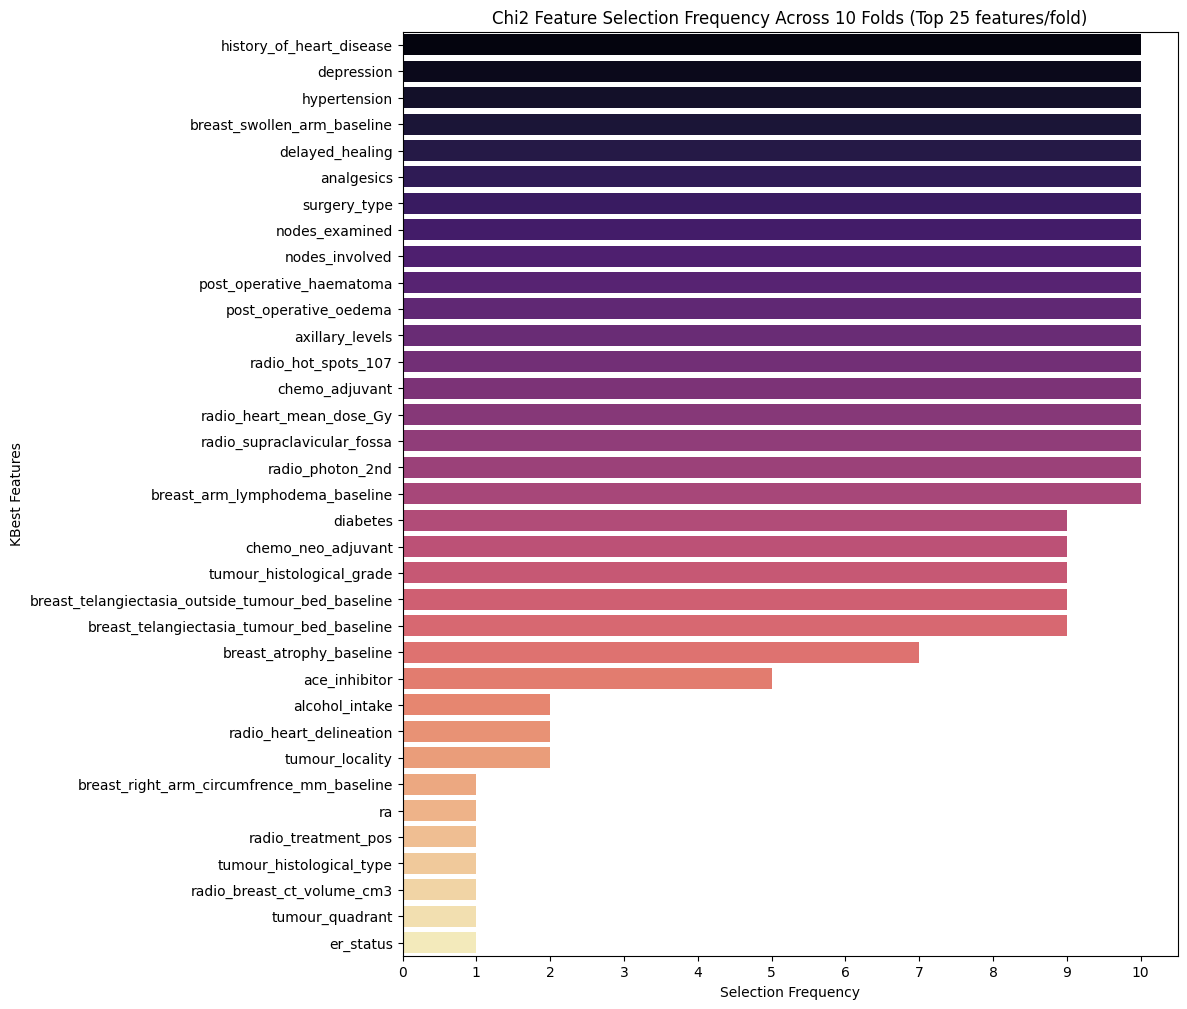

+---------------------------------------------------+-------------+
|                                                   |   Frequency |
|---------------------------------------------------+-------------|
| history_of_heart_disease                          |          10 |
| depression                                        |          10 |
| hypertension                                      |          10 |
| breast_swollen_arm_baseline                       |          10 |
| delayed_healing                                   |          10 |
| analgesics                                        |          10 |
| surgery_type                                      |          10 |
| nodes_examined                                    |          10 |
| nodes_involved                                    |          10 |
| post_operative_haematoma                          |          10 |
| post_operative_oedema                             |          10 |
| axillary_levels                               

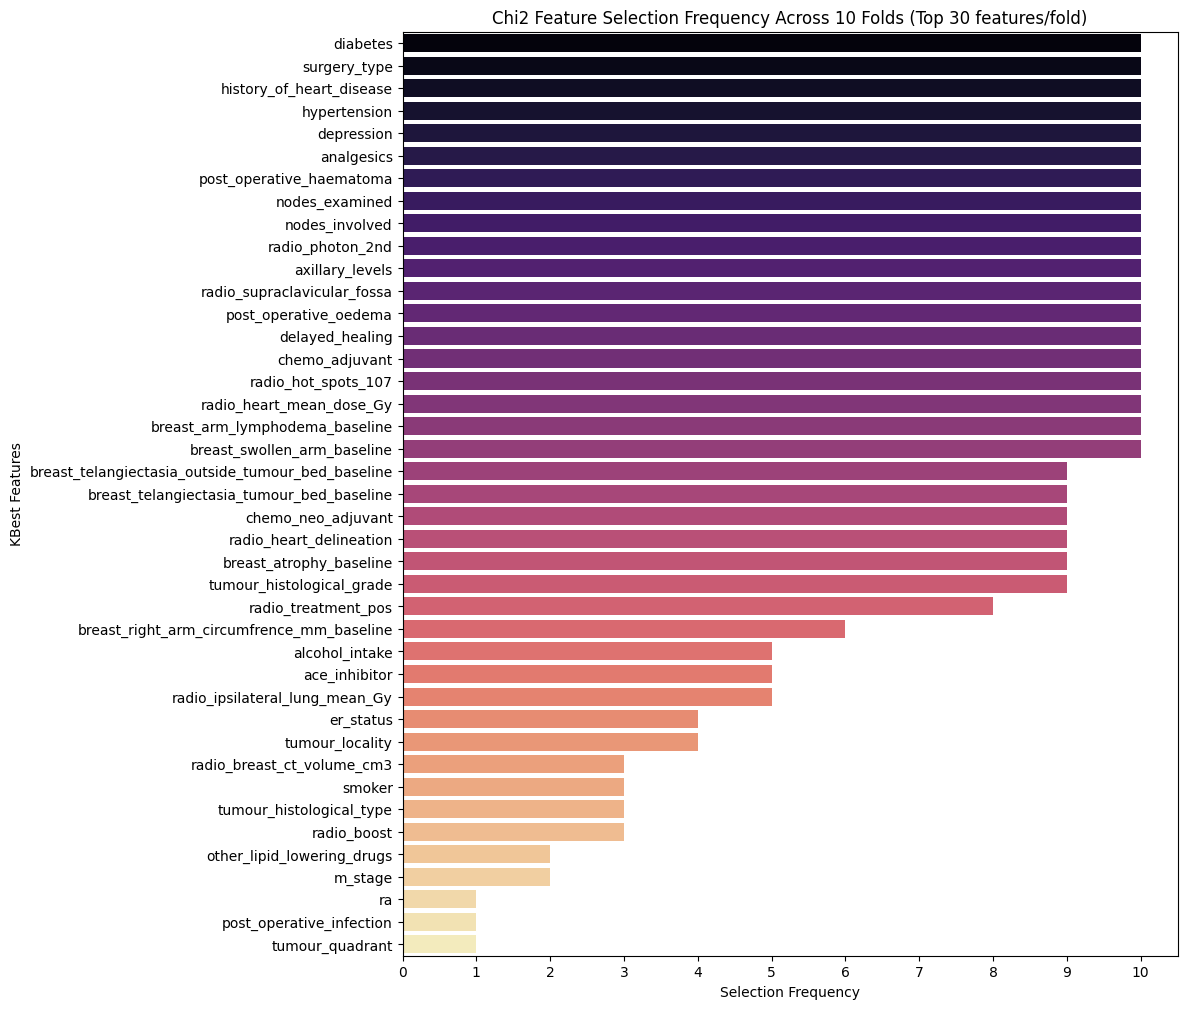

+---------------------------------------------------+-------------+
|                                                   |   Frequency |
|---------------------------------------------------+-------------|
| diabetes                                          |          10 |
| surgery_type                                      |          10 |
| history_of_heart_disease                          |          10 |
| hypertension                                      |          10 |
| depression                                        |          10 |
| analgesics                                        |          10 |
| post_operative_haematoma                          |          10 |
| nodes_examined                                    |          10 |
| nodes_involved                                    |          10 |
| radio_photon_2nd                                  |          10 |
| axillary_levels                                   |          10 |
| radio_supraclavicular_fossa                   

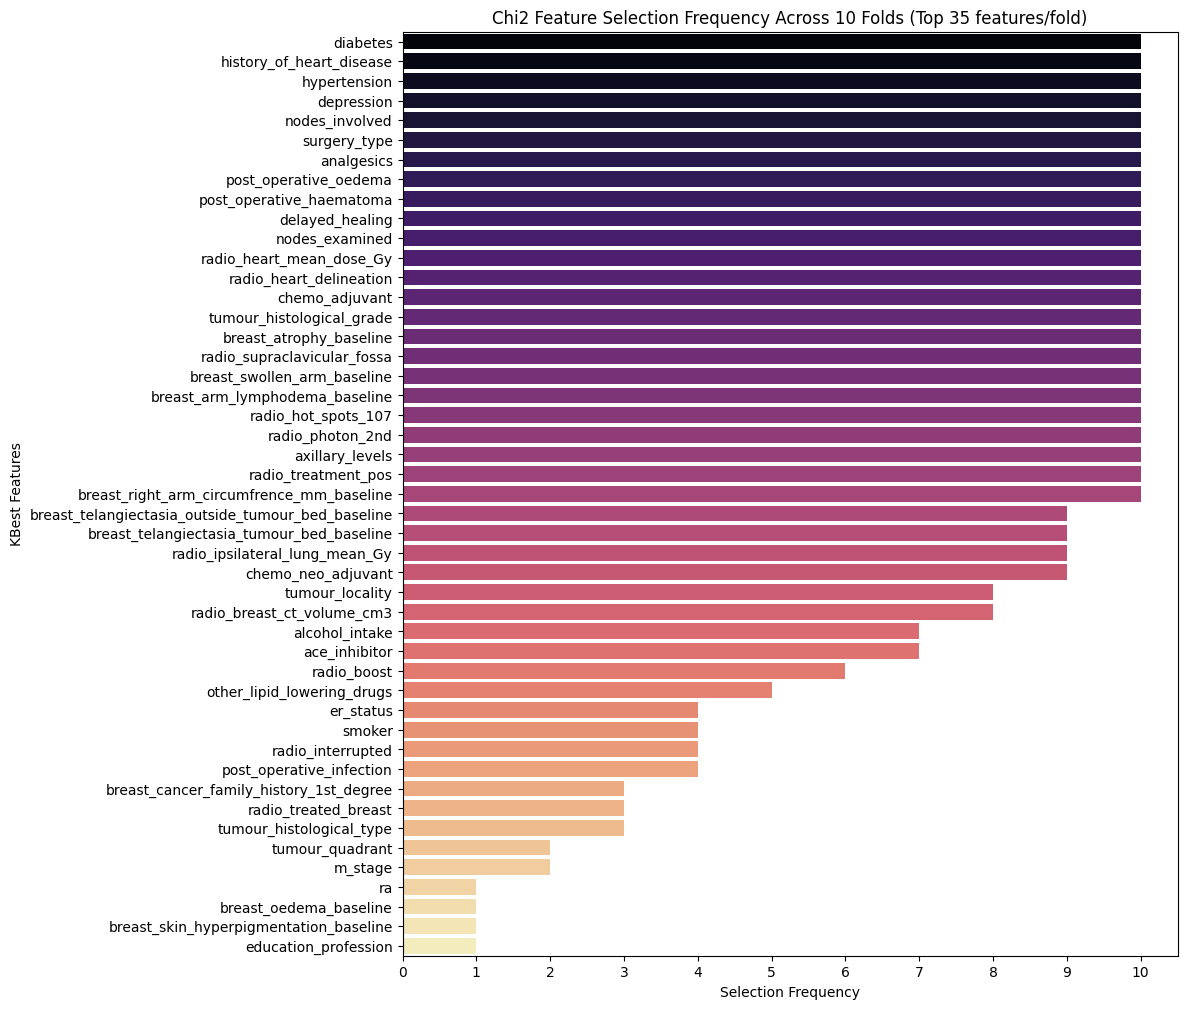

+---------------------------------------------------+-------------+
|                                                   |   Frequency |
|---------------------------------------------------+-------------|
| diabetes                                          |          10 |
| history_of_heart_disease                          |          10 |
| hypertension                                      |          10 |
| depression                                        |          10 |
| nodes_involved                                    |          10 |
| surgery_type                                      |          10 |
| analgesics                                        |          10 |
| post_operative_oedema                             |          10 |
| post_operative_haematoma                          |          10 |
| delayed_healing                                   |          10 |
| nodes_examined                                    |          10 |
| radio_heart_mean_dose_Gy                      

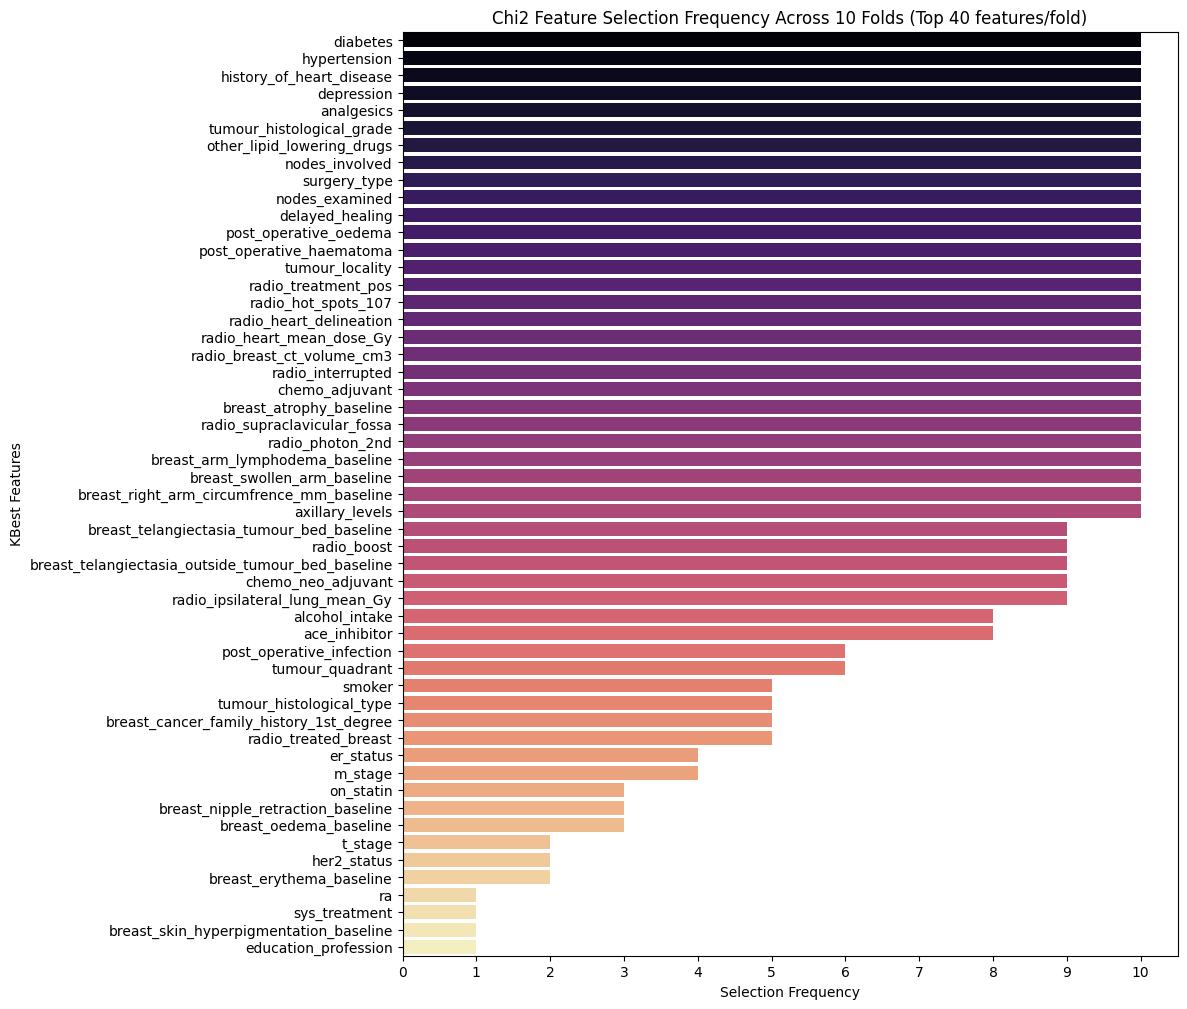

+---------------------------------------------------+-------------+
|                                                   |   Frequency |
|---------------------------------------------------+-------------|
| diabetes                                          |          10 |
| hypertension                                      |          10 |
| history_of_heart_disease                          |          10 |
| depression                                        |          10 |
| analgesics                                        |          10 |
| tumour_histological_grade                         |          10 |
| other_lipid_lowering_drugs                        |          10 |
| nodes_involved                                    |          10 |
| surgery_type                                      |          10 |
| nodes_examined                                    |          10 |
| delayed_healing                                   |          10 |
| post_operative_oedema                         

In [454]:
feature_sets_univariate_scaled_inside_pipeline = {}

for i in k:
    freq_df_scaled_auc= featureselection1_scaled_inside_pipeline(df_clinic_20, dependent1, k=i, n_splits=10)
    feature_sets_univariate_scaled_inside_pipeline[i] = freq_df_scaled_auc

In [375]:
def get_frequent_features(feature_sets, freq_threshold=8):
    """
    Extract stable features from feature frequency tables.

    Works with BOTH formats:

    Format 1:
    {
        k: freq_df
    }

    Format 2:
    {
        k: (freq_df, auc)
    }

    Parameters
    ----------
    feature_sets : dict
        Feature frequency results

    freq_threshold : int
        Minimum frequency required

    Returns
    -------
    list
        Stable feature names
    """

    stable_features = set()

    for k_value, value in feature_sets.items():

        # Handle both dictionary formats
        if isinstance(value, tuple):
            freq_df = value[0]
        else:
            freq_df = value

        selected = freq_df[
            freq_df['Frequency'] >= freq_threshold
        ]

        stable_features.update(
            selected.index.tolist()
        )

    return list(stable_features)

In [455]:
stable_features_univariate_scaled_inside_pipeline = get_frequent_features(
    feature_sets_univariate_scaled_inside_pipeline,
    freq_threshold=8
)

print(stable_features_univariate_scaled_inside_pipeline)
print(len(stable_features_univariate_scaled_inside_pipeline))


['nodes_involved', 'tumour_locality', 'radio_heart_delineation', 'breast_telangiectasia_tumour_bed_baseline', 'ace_inhibitor', 'breast_right_arm_circumfrence_mm_baseline', 'radio_ipsilateral_lung_mean_Gy', 'radio_hot_spots_107', 'alcohol_intake', 'breast_atrophy_baseline', 'radio_supraclavicular_fossa', 'diabetes', 'tumour_histological_grade', 'history_of_heart_disease', 'radio_treatment_pos', 'delayed_healing', 'surgery_type', 'other_lipid_lowering_drugs', 'breast_swollen_arm_baseline', 'post_operative_oedema', 'chemo_adjuvant', 'radio_photon_2nd', 'post_operative_haematoma', 'breast_telangiectasia_outside_tumour_bed_baseline', 'radio_boost', 'radio_breast_ct_volume_cm3', 'chemo_neo_adjuvant', 'analgesics', 'nodes_examined', 'radio_interrupted', 'hypertension', 'breast_arm_lymphodema_baseline', 'radio_heart_mean_dose_Gy', 'axillary_levels', 'depression']
35


In [456]:
cross_validated_feature_selection(df_clinic_20[stable_features_univariate_scaled_inside_pipeline + [dependent1]], dependent1, 10)

Original Data shape is (2067, 36)
Data shape after dropping missing target: (1691, 36)
✅ Mean AUC with final selected features: 0.8243


### Nested CV

In [378]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter


def get_models(X, y):
    return{

        "RandomForest": RandomForestClassifier(
            n_estimators=100, max_depth=10, random_state=5)}
'''
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=100, random_state=5
        ),
        "GradientBoosting": GradientBoostingClassifier(
            n_estimators=50, random_state=5
        ),
        "AdaBoost": AdaBoostClassifier(
            n_estimators=50, random_state=5
        ),
        "XGBoost": XGBClassifier(
            random_state=5,
            use_label_encoder=False,
            eval_metric="logloss"
        ),
        "DecisionTree": DecisionTreeClassifier(
            max_depth=5,
            random_state=5,
            class_weight="balanced"
        ),
        "QDA": make_pipeline(
            StandardScaler(),
            QuadraticDiscriminantAnalysis()
        ),
        "GaussianNB": make_pipeline(
            StandardScaler(),
            GaussianNB()
        ),
        "SVC": make_pipeline(
            StandardScaler(),
            SVC(kernel="rbf", probability=True, random_state=5)
        ),
        "KNN": make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=BestK(X, y))
        ),
        "LogisticRegression": make_pipeline(
            StandardScaler(),
            LogisticRegression(random_state=5)
        ),
        "MLP": make_pipeline(
            StandardScaler(),
            MLPClassifier(hidden_layer_sizes=(100,), random_state=5)
        )
    }'''



'\n        "ExtraTrees": ExtraTreesClassifier(\n            n_estimators=100, random_state=5\n        ),\n        "GradientBoosting": GradientBoostingClassifier(\n            n_estimators=50, random_state=5\n        ),\n        "AdaBoost": AdaBoostClassifier(\n            n_estimators=50, random_state=5\n        ),\n        "XGBoost": XGBClassifier(\n            random_state=5,\n            use_label_encoder=False,\n            eval_metric="logloss"\n        ),\n        "DecisionTree": DecisionTreeClassifier(\n            max_depth=5,\n            random_state=5,\n            class_weight="balanced"\n        ),\n        "QDA": make_pipeline(\n            StandardScaler(),\n            QuadraticDiscriminantAnalysis()\n        ),\n        "GaussianNB": make_pipeline(\n            StandardScaler(),\n            GaussianNB()\n        ),\n        "SVC": make_pipeline(\n            StandardScaler(),\n            SVC(kernel="rbf", probability=True, random_state=5)\n        ),\n        "KNN": 

In [379]:
from itertools import combinations

def jaccard_stability(fold_details, model_name):

    df_model = fold_details[fold_details["model"] == model_name]

    feature_sets = df_model["selected_features"].tolist()

    scores = []

    for a, b in combinations(feature_sets, 2):
        intersection = len(set(a) & set(b))
        union = len(set(a) | set(b))
        scores.append(intersection / union)

    return np.mean(scores)

In [380]:
def nested_cv_feature_selection_all_features(
    df,
    target,
    k_list,
    outer_splits,
    inner_splits
):

    df = df.dropna()

    # Same style as your second function
    X = df.drop(columns=[target, 'Subject Id'])
    y = df[target]

    # Convert categorical variables to numeric dummy variables
    X = pd.get_dummies(X, drop_first=True)

    outer_cv = StratifiedKFold(
        n_splits=outer_splits,
        shuffle=True,
        random_state=0
    )

    inner_cv = StratifiedKFold(
        n_splits=inner_splits,
        shuffle=True,
        random_state=1
    )

    results = {name: [] for name in get_models(X, y).keys()}
    fold_details = []

    for fold_id, (train_idx, test_idx) in enumerate(
        tqdm(outer_cv.split(X, y), desc="Outer CV"),
        start=1
    ):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        best_k = None
        best_score = -np.inf

        # ==============================
        # INNER LOOP: choose best k
        # ==============================
        for k in k_list:
            inner_scores = []

            for inner_train_idx, inner_val_idx in inner_cv.split(X_train, y_train):

                X_tr = X_train.iloc[inner_train_idx]
                X_val = X_train.iloc[inner_val_idx]
                y_tr = y_train.iloc[inner_train_idx]
                y_val = y_train.iloc[inner_val_idx]

                pipeline = Pipeline([
                    ('scaler', MinMaxScaler()),
                    ('feature_selection', SelectKBest(score_func=chi2, k=k)),
                    ('model', RandomForestClassifier(
                        n_estimators=100,
                        max_depth=10,
                        min_samples_split=5,
                        min_samples_leaf=1,
                        bootstrap=True,
                        random_state=5
                    ))
                ])

                pipeline.fit(X_tr, y_tr)

                y_pred = pipeline.predict_proba(X_val)[:, 1]
                inner_scores.append(roc_auc_score(y_val, y_pred))

            mean_score = np.mean(inner_scores)

            if mean_score > best_score:
                best_score = mean_score
                best_k = k

        # ==============================
        # OUTER LOOP: train final models
        # ==============================
        models = get_models(X_train, y_train)

        for name, model in models.items():

            pipeline = Pipeline([
                ('scaler', MinMaxScaler()),
                ('feature_selection', SelectKBest(score_func=chi2, k=best_k)),
                ('model', model)
            ])

            pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict_proba(X_test)[:, 1]
            auc_score = roc_auc_score(y_test, y_pred)

            selected_mask = pipeline.named_steps[
                "feature_selection"
            ].get_support()

            selected_features = X_train.columns[selected_mask].tolist()

            results[name].append(auc_score)

            fold_details.append({
                "fold": fold_id,
                "model": name,
                "best_k": best_k,
                "inner_auc": best_score,
                "outer_auc": auc_score,
                "selected_features": selected_features
            })

    summary = {
        model: {
            "mean_auc": np.mean(scores),
            "std_auc": np.std(scores)
        }
        for model, scores in results.items()
    }

    summary = pd.DataFrame(summary).T.sort_values(
        by="mean_auc",
        ascending=False
    )

    fold_details = pd.DataFrame(fold_details)

    all_features = []

    for features in fold_details["selected_features"]:
        all_features.extend(features)

    feature_counts = Counter(all_features)

    feature_frequency = pd.DataFrame({
        "feature": feature_counts.keys(),
        "count": feature_counts.values()
    })

    feature_frequency["percentage"] = (
        100 * feature_frequency["count"] / len(fold_details)
    )

    feature_frequency = feature_frequency.sort_values(
        by="percentage",
        ascending=False
    ).reset_index(drop=True)

    return summary, fold_details, feature_frequency

In [457]:
summary1, fold_details1, feature_frequency1 = nested_cv_feature_selection_all_features(df_clinic_20, dependent1, k_list=k, outer_splits=10, inner_splits=5)

Outer CV: 10it [01:38,  9.90s/it]


In [465]:
summary1

,mean_auc,std_auc
RandomForest,0.791146,0.089068


In [466]:
fold_details1

,fold,model,best_k,inner_auc,outer_auc,selected_features
0,1,RandomForest,35,0.792869,0.861111,"[alcohol_intake, diabetes, history_of_heart_di..."
1,2,RandomForest,30,0.809680,0.829861,"[diabetes, history_of_heart_disease, ra, hyper..."
2,3,RandomForest,40,0.802378,0.795139,"[smoker, alcohol_intake, diabetes, history_of_..."
3,4,RandomForest,20,0.818886,0.715278,"[history_of_heart_disease, hypertension, depre..."
4,5,RandomForest,20,0.796095,0.840278,"[diabetes, history_of_heart_disease, hypertens..."
5,6,RandomForest,10,0.800322,0.654514,"[history_of_heart_disease, analgesics, nodes_e..."
6,7,RandomForest,30,0.830874,0.753472,"[smoker, diabetes, history_of_heart_disease, h..."
7,8,RandomForest,15,0.835953,0.656250,"[diabetes, history_of_heart_disease, analgesic..."
8,9,RandomForest,35,0.803080,0.875000,"[smoker, alcohol_intake, diabetes, history_of_..."
9,10,RandomForest,25,0.771412,0.930556,"[diabetes, history_of_heart_disease, hypertens..."


In [467]:
feature_frequency1

,feature,count,percentage
0,history_of_heart_disease,10,100.0
1,analgesics,10,100.0
2,nodes_examined,10,100.0
3,post_operative_haematoma,10,100.0
4,chemo_adjuvant,10,100.0
5,breast_swollen_arm_baseline,10,100.0
6,axillary_levels,10,100.0
7,radio_supraclavicular_fossa,10,100.0
8,post_operative_oedema,10,100.0
9,delayed_healing,10,100.0


In [468]:
# Features that appeared in 8 folds and more across 10 folds
stable_features_nested1 = feature_frequency1[feature_frequency1["count"] >= 8]["feature"].tolist()

In [469]:
print (stable_features_nested1)

['history_of_heart_disease', 'analgesics', 'nodes_examined', 'post_operative_haematoma', 'chemo_adjuvant', 'breast_swollen_arm_baseline', 'axillary_levels', 'radio_supraclavicular_fossa', 'post_operative_oedema', 'delayed_healing', 'radio_photon_2nd', 'surgery_type', 'breast_arm_lymphodema_baseline', 'breast_telangiectasia_outside_tumour_bed_baseline', 'radio_hot_spots_107', 'radio_heart_mean_dose_Gy', 'depression', 'diabetes', 'hypertension', 'nodes_involved']


In [470]:
print(len(stable_features_nested1))

20


In [471]:
jaccard_stability(fold_details1, "RandomForest")

np.float64(0.605472974451538)

In [472]:
cross_validated_feature_selection(df_clinic_20[stable_features_nested1 + [dependent1]], dependent1, 10)

Original Data shape is (2067, 21)
Data shape after dropping missing target: (1691, 21)
✅ Mean AUC with final selected features: 0.8411


## Second feature selectin Method

**3.3.3) Feature Importance** — You can gain the significance of each feature of your dataset by
using the Model Characteristics property. Feature value gives you a score for every function of your results, the higher the score the more significant or appropriate the performance variable is. Feature importance is the built-in class that comes with Tree Based Classifiers, we will use the Extra Tree Classifier to extract the top 10 features for the dataset.

### outside CV

In [390]:
def featureselection2(df, col, k):
    # Plot the top k features
    plt.figure(figsize=(10, 10))

    # Initialize the model
    model = ExtraTreesClassifier(random_state=10)

    # Drop rows with missing values
    df = df.dropna(axis=0, how='any', inplace=False)


    # Separate features and target variable
    X = df.drop(columns=[col, 'Subject Id'])
    y = df[col]

    # Convert categorical variables into numeric
    X = pd.get_dummies(X, drop_first=True)


    # Fit the model
    model.fit(X, y)

    # Get feature importances
    feat_importances = pd.Series(model.feature_importances_, index=X.columns)

    # Select the top k important features
    top_features = feat_importances.nlargest(k)

    # Plot the top k features
    bold("Choosing " + str(k) + " Features:\n")

    top_features.plot(kind='barh')
    #sns.barplot(x=top_features, y=feat_importances, data=df, palette='viridis')
    plt.xlabel("Feature Importance")
    plt.title(f"Top {k} Important Features")
    plt.show()
    print(f"\n\n Important {k} features:", top_features.index.tolist())

    # Prepare data with selected features only
    X_selected = X[top_features.index.tolist()]
    # Build pipeline and evaluate using cross-validation
    pipeline = Pipeline([
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, min_samples_leaf=1,bootstrap=True, random_state=5))
    ])

    # Use StratifiedKFold and calculate mean AUC
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    auc_scores = cross_val_score(pipeline, X_selected, y, cv=skf, scoring='roc_auc')

    print(f"Mean AUC score using top {k} features: {auc_scores.mean():.4f}")
    return top_features.index.tolist(), auc_scores.mean()



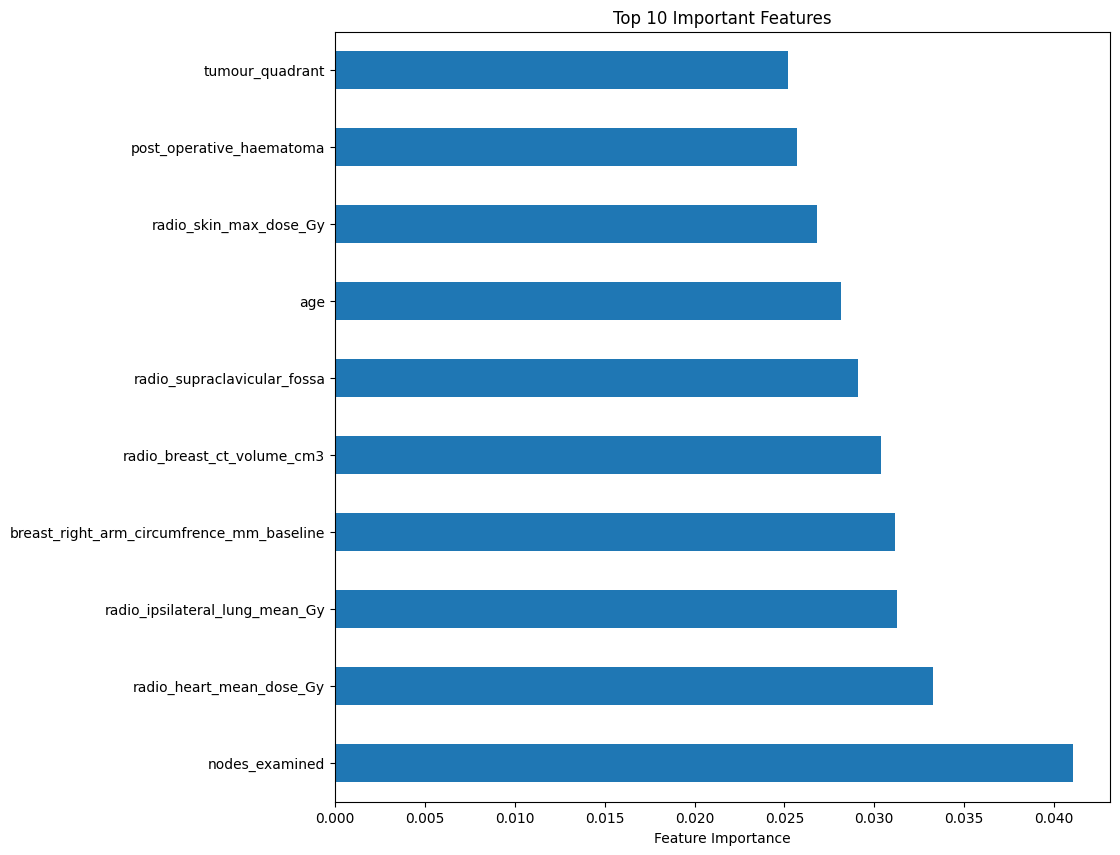



 Important 10 features: ['nodes_examined', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline', 'radio_breast_ct_volume_cm3', 'radio_supraclavicular_fossa', 'age', 'radio_skin_max_dose_Gy', 'post_operative_haematoma', 'tumour_quadrant']
Mean AUC score using top 10 features: 0.8289


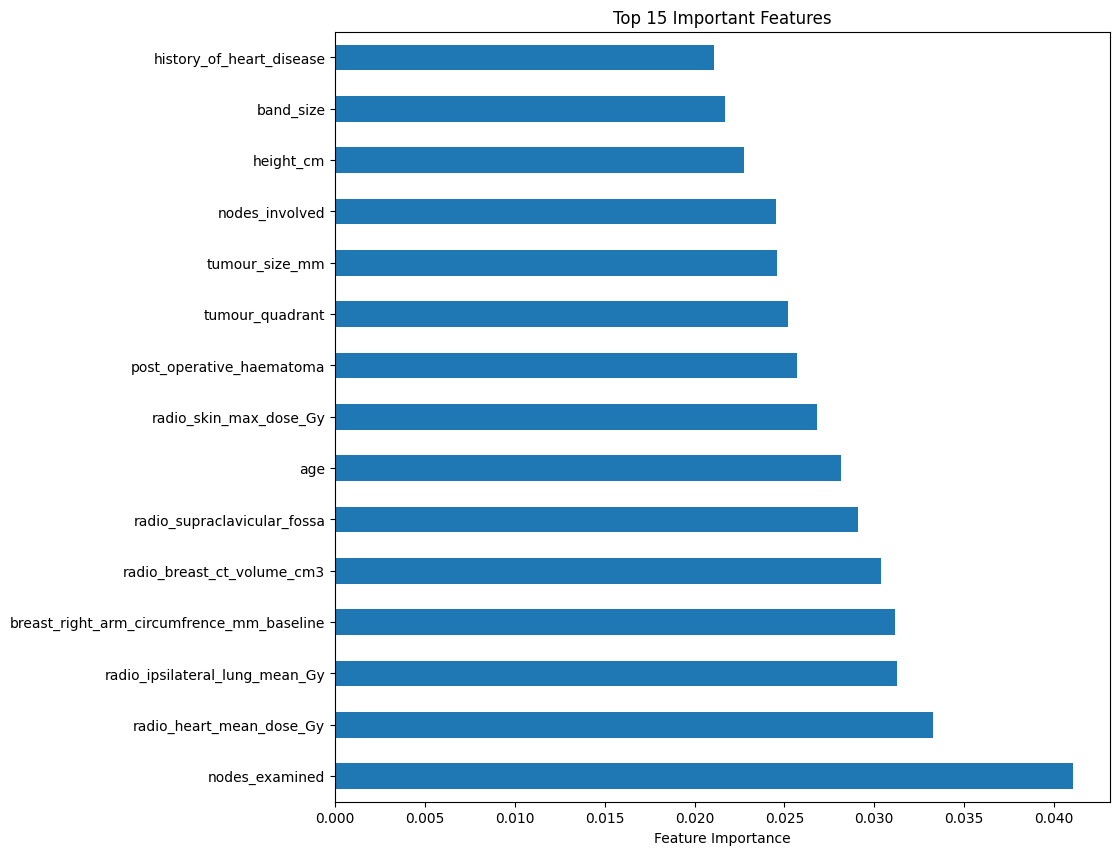



 Important 15 features: ['nodes_examined', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline', 'radio_breast_ct_volume_cm3', 'radio_supraclavicular_fossa', 'age', 'radio_skin_max_dose_Gy', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'nodes_involved', 'height_cm', 'band_size', 'history_of_heart_disease']
Mean AUC score using top 15 features: 0.8317


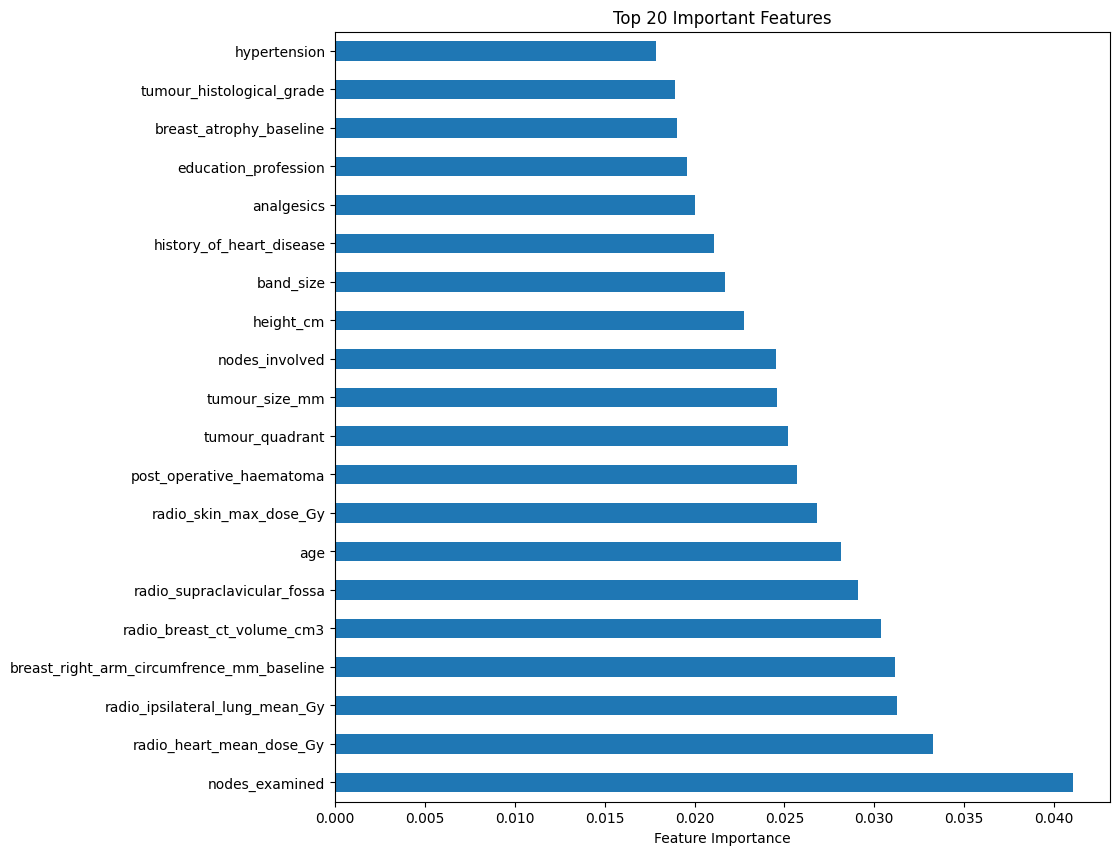



 Important 20 features: ['nodes_examined', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline', 'radio_breast_ct_volume_cm3', 'radio_supraclavicular_fossa', 'age', 'radio_skin_max_dose_Gy', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'nodes_involved', 'height_cm', 'band_size', 'history_of_heart_disease', 'analgesics', 'education_profession', 'breast_atrophy_baseline', 'tumour_histological_grade', 'hypertension']
Mean AUC score using top 20 features: 0.8248


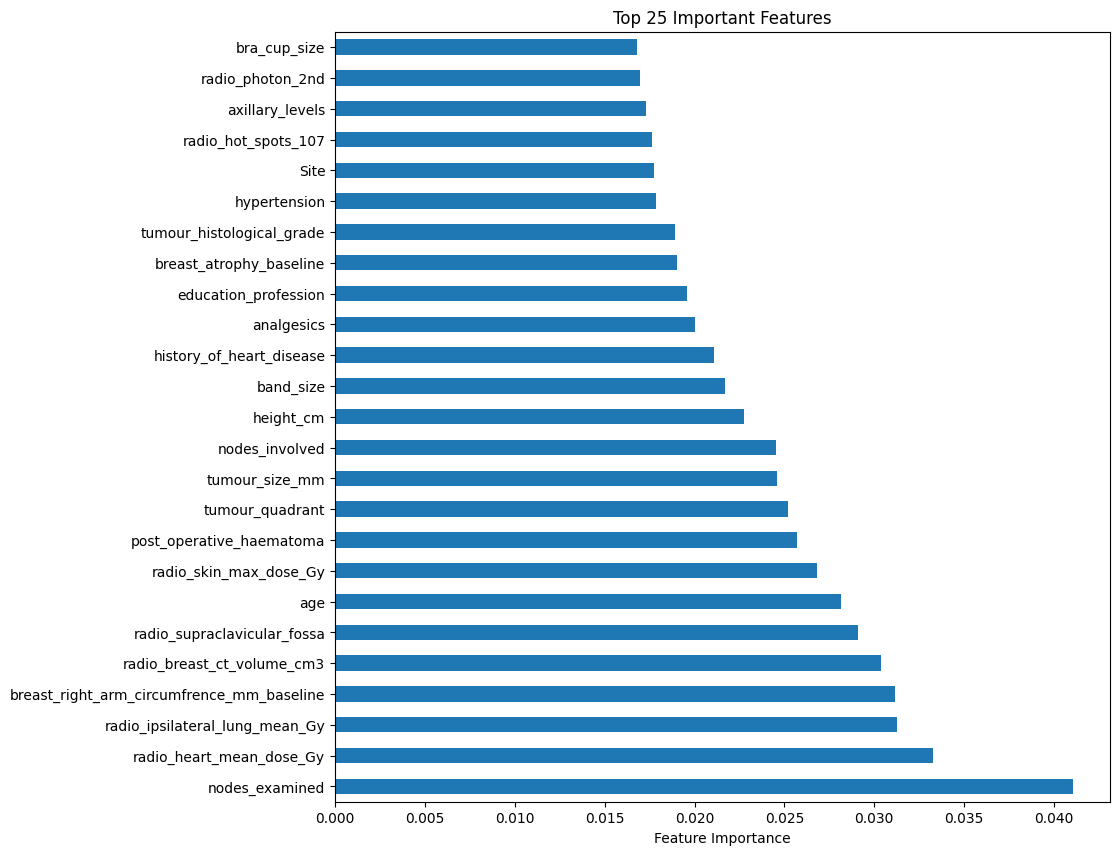



 Important 25 features: ['nodes_examined', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline', 'radio_breast_ct_volume_cm3', 'radio_supraclavicular_fossa', 'age', 'radio_skin_max_dose_Gy', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'nodes_involved', 'height_cm', 'band_size', 'history_of_heart_disease', 'analgesics', 'education_profession', 'breast_atrophy_baseline', 'tumour_histological_grade', 'hypertension', 'Site', 'radio_hot_spots_107', 'axillary_levels', 'radio_photon_2nd', 'bra_cup_size']
Mean AUC score using top 25 features: 0.8230


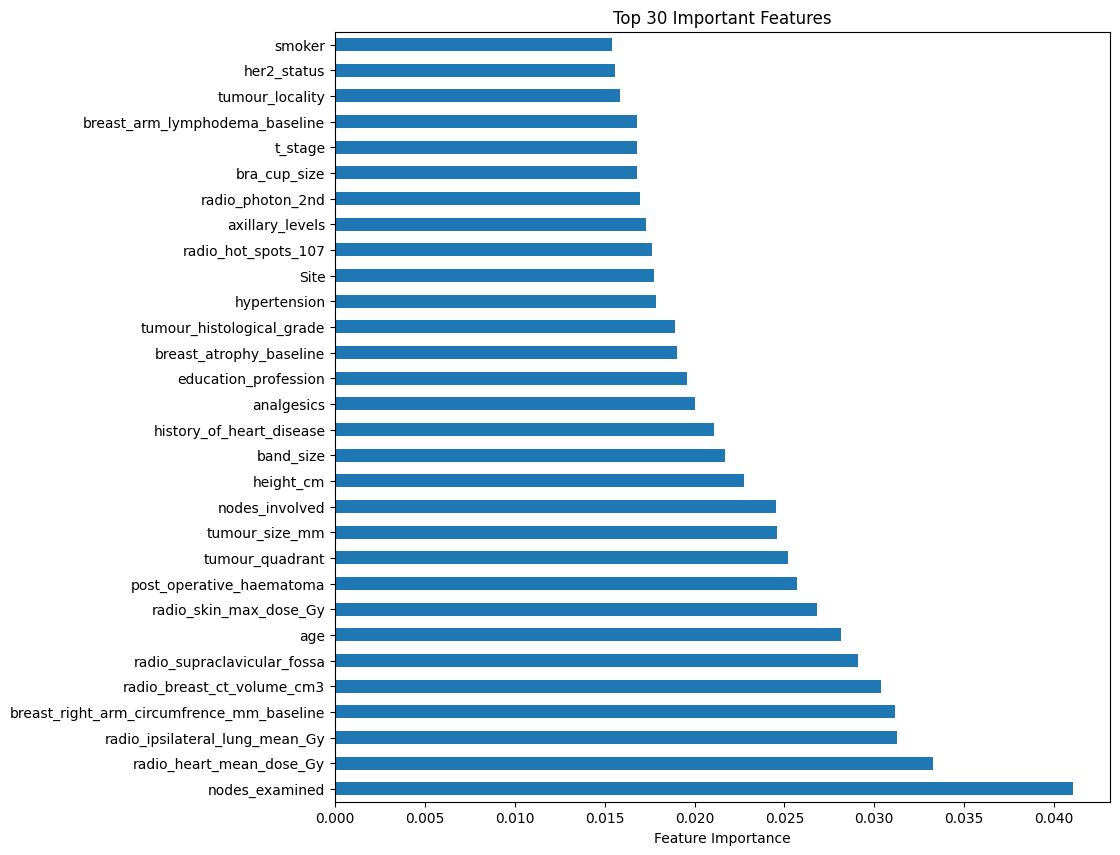



 Important 30 features: ['nodes_examined', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline', 'radio_breast_ct_volume_cm3', 'radio_supraclavicular_fossa', 'age', 'radio_skin_max_dose_Gy', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'nodes_involved', 'height_cm', 'band_size', 'history_of_heart_disease', 'analgesics', 'education_profession', 'breast_atrophy_baseline', 'tumour_histological_grade', 'hypertension', 'Site', 'radio_hot_spots_107', 'axillary_levels', 'radio_photon_2nd', 'bra_cup_size', 't_stage', 'breast_arm_lymphodema_baseline', 'tumour_locality', 'her2_status', 'smoker']
Mean AUC score using top 30 features: 0.8498


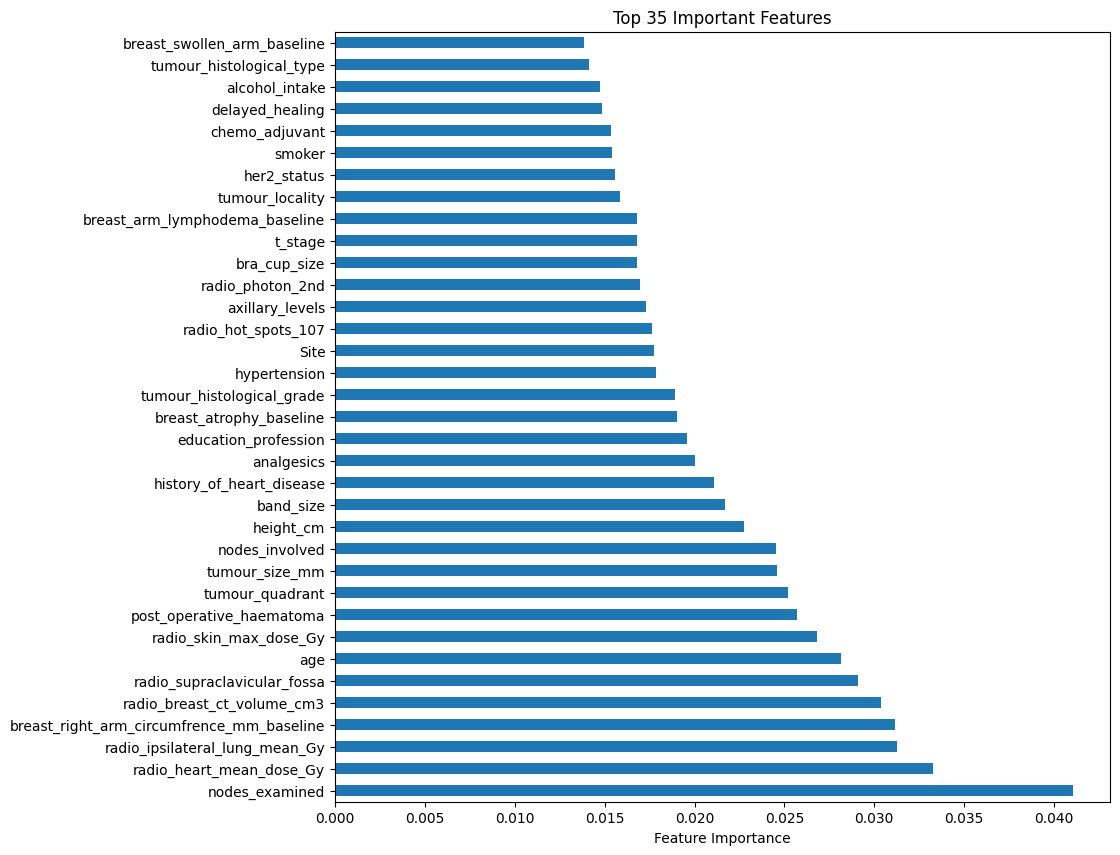



 Important 35 features: ['nodes_examined', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline', 'radio_breast_ct_volume_cm3', 'radio_supraclavicular_fossa', 'age', 'radio_skin_max_dose_Gy', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'nodes_involved', 'height_cm', 'band_size', 'history_of_heart_disease', 'analgesics', 'education_profession', 'breast_atrophy_baseline', 'tumour_histological_grade', 'hypertension', 'Site', 'radio_hot_spots_107', 'axillary_levels', 'radio_photon_2nd', 'bra_cup_size', 't_stage', 'breast_arm_lymphodema_baseline', 'tumour_locality', 'her2_status', 'smoker', 'chemo_adjuvant', 'delayed_healing', 'alcohol_intake', 'tumour_histological_type', 'breast_swollen_arm_baseline']
Mean AUC score using top 35 features: 0.8472


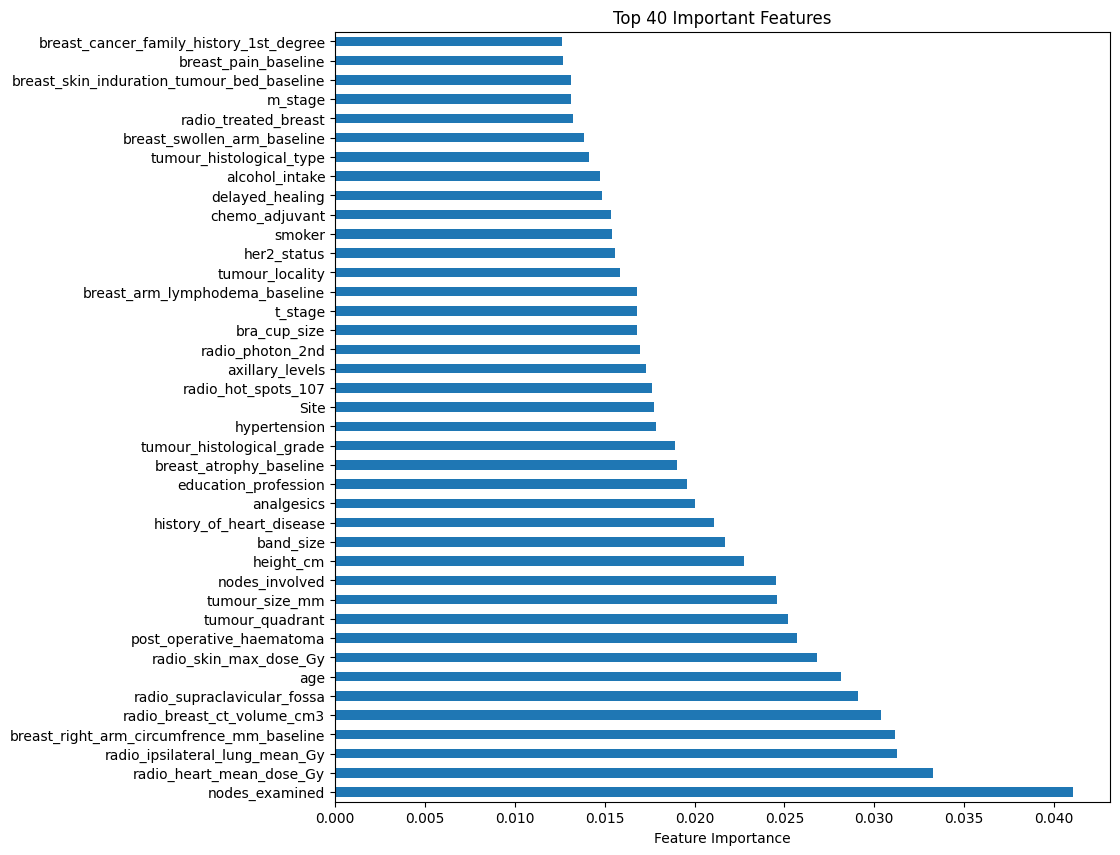



 Important 40 features: ['nodes_examined', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline', 'radio_breast_ct_volume_cm3', 'radio_supraclavicular_fossa', 'age', 'radio_skin_max_dose_Gy', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'nodes_involved', 'height_cm', 'band_size', 'history_of_heart_disease', 'analgesics', 'education_profession', 'breast_atrophy_baseline', 'tumour_histological_grade', 'hypertension', 'Site', 'radio_hot_spots_107', 'axillary_levels', 'radio_photon_2nd', 'bra_cup_size', 't_stage', 'breast_arm_lymphodema_baseline', 'tumour_locality', 'her2_status', 'smoker', 'chemo_adjuvant', 'delayed_healing', 'alcohol_intake', 'tumour_histological_type', 'breast_swollen_arm_baseline', 'radio_treated_breast', 'm_stage', 'breast_skin_induration_tumour_bed_baseline', 'breast_pain_baseline', 'breast_cancer_family_history_1st_degree']
Mean AUC score using top 40 features: 0.8214


In [464]:
feature_sets_featimportance = {}

for i in k:
    freq_df2_auc= featureselection2(df_clinic_20, dependent1, k=i)
    feature_sets_featimportance[i] = freq_df2_auc

In [473]:
print(feature_sets_featimportance)

{10: (['nodes_examined', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline', 'radio_breast_ct_volume_cm3', 'radio_supraclavicular_fossa', 'age', 'radio_skin_max_dose_Gy', 'post_operative_haematoma', 'tumour_quadrant'], np.float64(0.8289351851851852)), 15: (['nodes_examined', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline', 'radio_breast_ct_volume_cm3', 'radio_supraclavicular_fossa', 'age', 'radio_skin_max_dose_Gy', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'nodes_involved', 'height_cm', 'band_size', 'history_of_heart_disease'], np.float64(0.8317129629629629)), 20: (['nodes_examined', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline', 'radio_breast_ct_volume_cm3', 'radio_supraclavicular_fossa', 'age', 'radio_skin_max_dose_Gy', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'nodes_

In [475]:
from collections import Counter
import math

feature_counter = Counter()

for features, _ in feature_sets_featimportance.values():
    feature_counter.update(features)

# 80% threshold
threshold = math.ceil(0.8 * len(feature_sets_featimportance))

stable_features_featimportance = [
    feature
    for feature, count in feature_counter.items()
    if count >= threshold
]

print(stable_features_featimportance)
print(len(stable_features_featimportance))

['nodes_examined', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline', 'radio_breast_ct_volume_cm3', 'radio_supraclavicular_fossa', 'age', 'radio_skin_max_dose_Gy', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'nodes_involved', 'height_cm', 'band_size', 'history_of_heart_disease']
15


In [476]:
cross_validated_feature_selection(df_clinic_20[stable_features_featimportance + [dependent1]], dependent1, 10)

Original Data shape is (2067, 16)
Data shape after dropping missing target: (1691, 16)
✅ Mean AUC with final selected features: 0.8233


### inside CV

In [395]:
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import MinMaxScaler

def featureselection2_pipeline_auc(df, dependent, k):
    df = df.dropna()


    # Separate features and target variable
    X = df.drop(columns=[dependent, 'Subject Id'])
    y = df[dependent]

    # Convert categorical variables into numeric
    X = pd.get_dummies(X, drop_first=True)

    # Build pipeline with scaling, feature selection, and classification
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()), # Added scaler back, assuming it's intended to be part of the pipeline
        ('feature_selection', SelectFromModel(
            ExtraTreesClassifier(random_state=10),
            threshold=-np.inf, # Set a very low threshold so we can control selection purely by max_features
            max_features=k
        )),
        ('classifier', RandomForestClassifier(n_estimators=100,
                              max_depth=10,
                              min_samples_split=5,
                              min_samples_leaf=1,
                              bootstrap=True,
                              random_state=5))
    ])

    # Cross-validation setup
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    auc_scores = cross_val_score(pipeline, X, y, cv=skf, scoring='roc_auc')

    print(f"Mean AUC score using top {k} features (Inside CV): {auc_scores.mean():.3f}")
    return auc_scores.mean()



In [477]:
# This is the method that I used to compare among features number, heatmaps
for i in k:
  Mean_auc_scores_CV_inside_pipeline2= featureselection2_pipeline_auc(df_clinic_20, dependent1, k=i)

Mean AUC score using top 10 features (Inside CV): 0.782
Mean AUC score using top 15 features (Inside CV): 0.781
Mean AUC score using top 20 features (Inside CV): 0.786
Mean AUC score using top 25 features (Inside CV): 0.806
Mean AUC score using top 30 features (Inside CV): 0.796
Mean AUC score using top 35 features (Inside CV): 0.825
Mean AUC score using top 40 features (Inside CV): 0.813


### features frequency inside pipline

In [478]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from collections import Counter
import numpy as np
import pandas as pd

def featureselection2_freq(df, col, k, n_splits):
    df = df.dropna()

    # Prepare X and y
    X = df.drop(columns=[col, 'Subject Id'])
    y = df[col]

    # Convert categorical variables into numeric
    X = pd.get_dummies(X, drop_first=True)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

    feature_counts = Counter()
    auc_scores = []

    for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train, y_train = X.iloc[train_index], y.iloc[train_index]
        X_test, y_test = X.iloc[test_index], y.iloc[test_index]

        pipeline = Pipeline([
            ('feature_selection', SelectFromModel(
                estimator=ExtraTreesClassifier(random_state=10),
                max_features=k,
                threshold=-np.inf  # keep exactly top k features
            )),

            ('model', RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=1,
                bootstrap=True,
                random_state=5
            ))
        ])

        pipeline.fit(X_train, y_train)
        # Get predicted probabilities for AUC calculation
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        auc_scores.append(auc)


        selector = pipeline.named_steps['feature_selection']
        top_features = X_train.columns[selector.get_support()].tolist()

        # Count selected features
        feature_counts.update(top_features)
        print(f"Fold {fold_idx+1}: Selected features: {list(top_features)}| AUC: {auc:.4f}"
        )

    # Calculate the mean AUC
    mean_auc = np.mean(auc_scores)
    print(f"Mean AUC using top {k} features across {n_splits} folds: {mean_auc:.4f}")

   # Convert to DataFrame
    freq_df = pd.DataFrame.from_dict(feature_counts, orient='index', columns=['Frequency'])
    freq_df = freq_df.sort_values(by='Frequency', ascending=False)

    # Plot
    plt.figure(figsize=(10, 12))
    sns.barplot(x='Frequency', y=freq_df.index, data=freq_df, palette='viridis')
    plt.xlabel('Selection Frequency')
    plt.ylabel('Feature Importances with ETC')
    plt.title(f'Feature Importances Frequency Across {n_splits} Folds (Top {k} features/fold)')
    plt.xticks(np.arange(0, n_splits+1, 1))
    #plt.gca().invert_yaxis()
    plt.show()
    #print(tabulate(freq_df, headers='keys', tablefmt='psql'))
    print(tabulate(freq_df, headers='keys', tablefmt='psql'))
    top_features_final = freq_df.head(k).index.tolist()
    print(f"Top {k} most frequently Features across {n_splits} folds:", top_features_final)
    print("\n\t*****************************************************************************************************************************************************************\n\n")

    return freq_df

Fold 1: Selected features: ['height_cm', 'nodes_examined', 'post_operative_haematoma', 'tumour_size_mm', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'radio_supraclavicular_fossa', 'breast_right_arm_circumfrence_mm_baseline']| AUC: 0.8472
Fold 2: Selected features: ['age', 'analgesics', 'nodes_examined', 'post_operative_haematoma', 'tumour_size_mm', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'radio_supraclavicular_fossa', 'breast_right_arm_circumfrence_mm_baseline']| AUC: 0.6979
Fold 3: Selected features: ['height_cm', 'age', 'nodes_examined', 'tumour_size_mm', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'radio_supraclavicular_fossa', 'breast_right_arm_circumfrence_mm_baseline']| AUC: 0.7153
Fold 4: Selected features: ['height_cm', 'age', 'nodes_examined', 'radio_breast_ct_volume_cm3', 'radio_sk

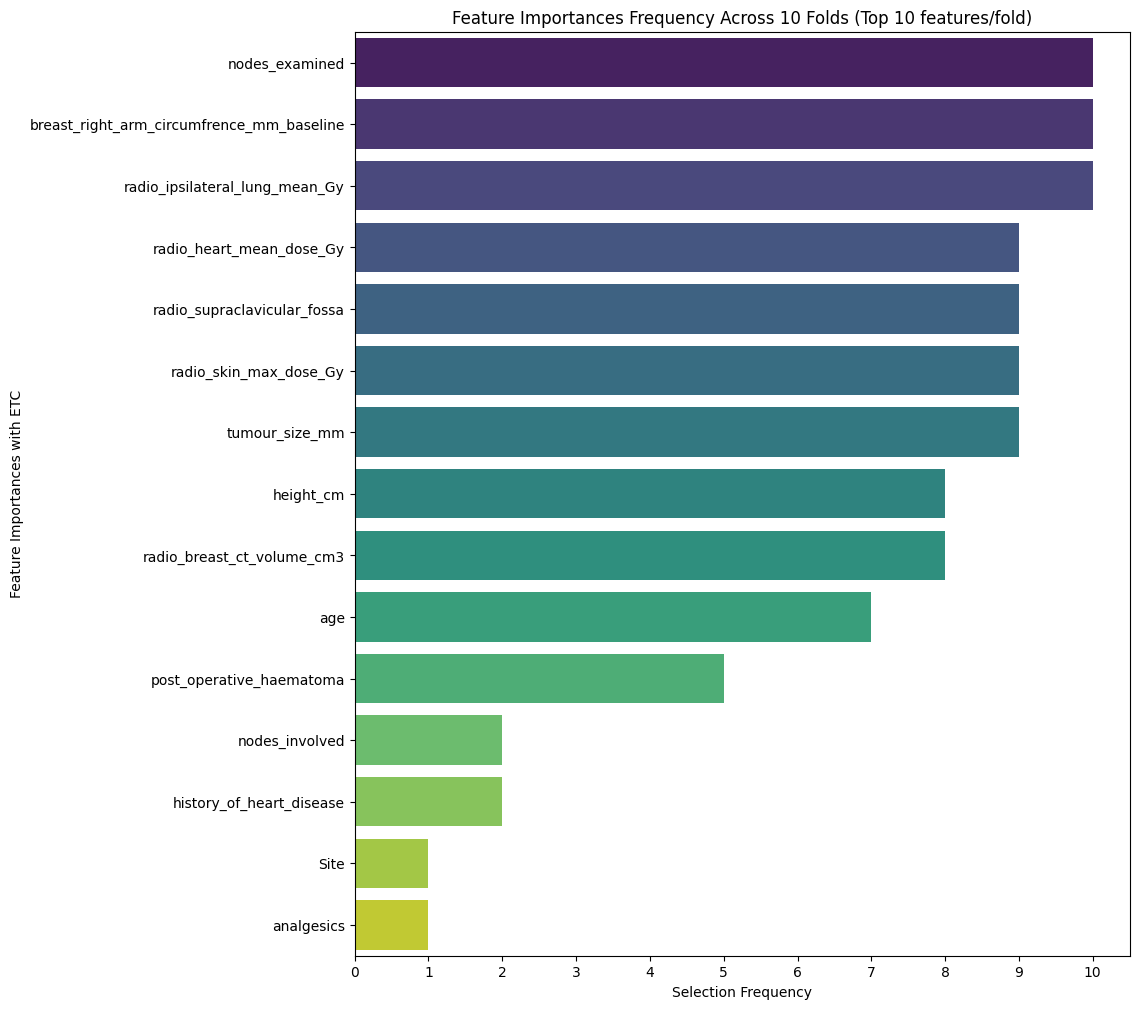

+-------------------------------------------+-------------+
|                                           |   Frequency |
|-------------------------------------------+-------------|
| nodes_examined                            |          10 |
| breast_right_arm_circumfrence_mm_baseline |          10 |
| radio_ipsilateral_lung_mean_Gy            |          10 |
| radio_heart_mean_dose_Gy                  |           9 |
| radio_supraclavicular_fossa               |           9 |
| radio_skin_max_dose_Gy                    |           9 |
| tumour_size_mm                            |           9 |
| height_cm                                 |           8 |
| radio_breast_ct_volume_cm3                |           8 |
| age                                       |           7 |
| post_operative_haematoma                  |           5 |
| nodes_involved                            |           2 |
| history_of_heart_disease                  |           2 |
| Site                                  

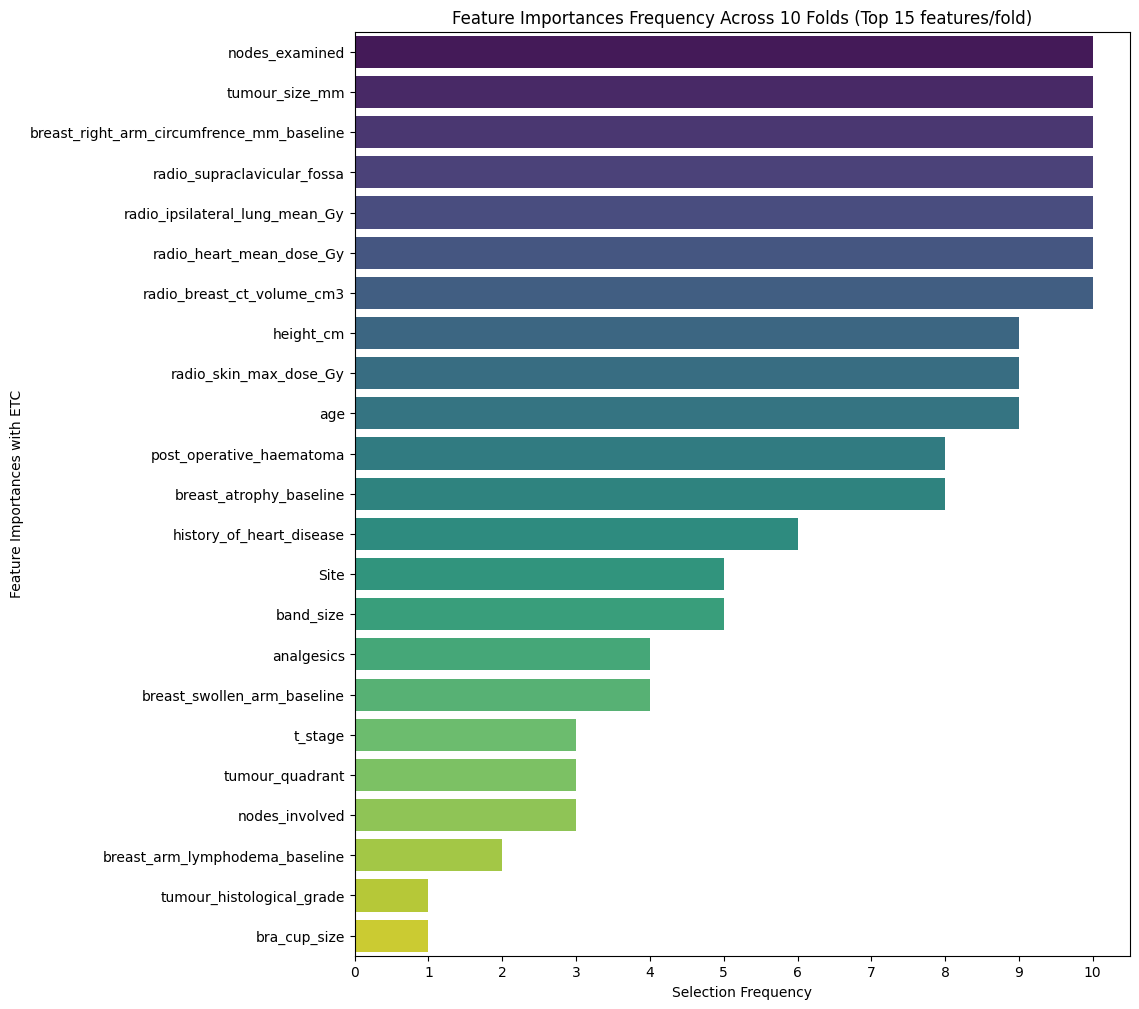

+-------------------------------------------+-------------+
|                                           |   Frequency |
|-------------------------------------------+-------------|
| nodes_examined                            |          10 |
| tumour_size_mm                            |          10 |
| breast_right_arm_circumfrence_mm_baseline |          10 |
| radio_supraclavicular_fossa               |          10 |
| radio_ipsilateral_lung_mean_Gy            |          10 |
| radio_heart_mean_dose_Gy                  |          10 |
| radio_breast_ct_volume_cm3                |          10 |
| height_cm                                 |           9 |
| radio_skin_max_dose_Gy                    |           9 |
| age                                       |           9 |
| post_operative_haematoma                  |           8 |
| breast_atrophy_baseline                   |           8 |
| history_of_heart_disease                  |           6 |
| Site                                  

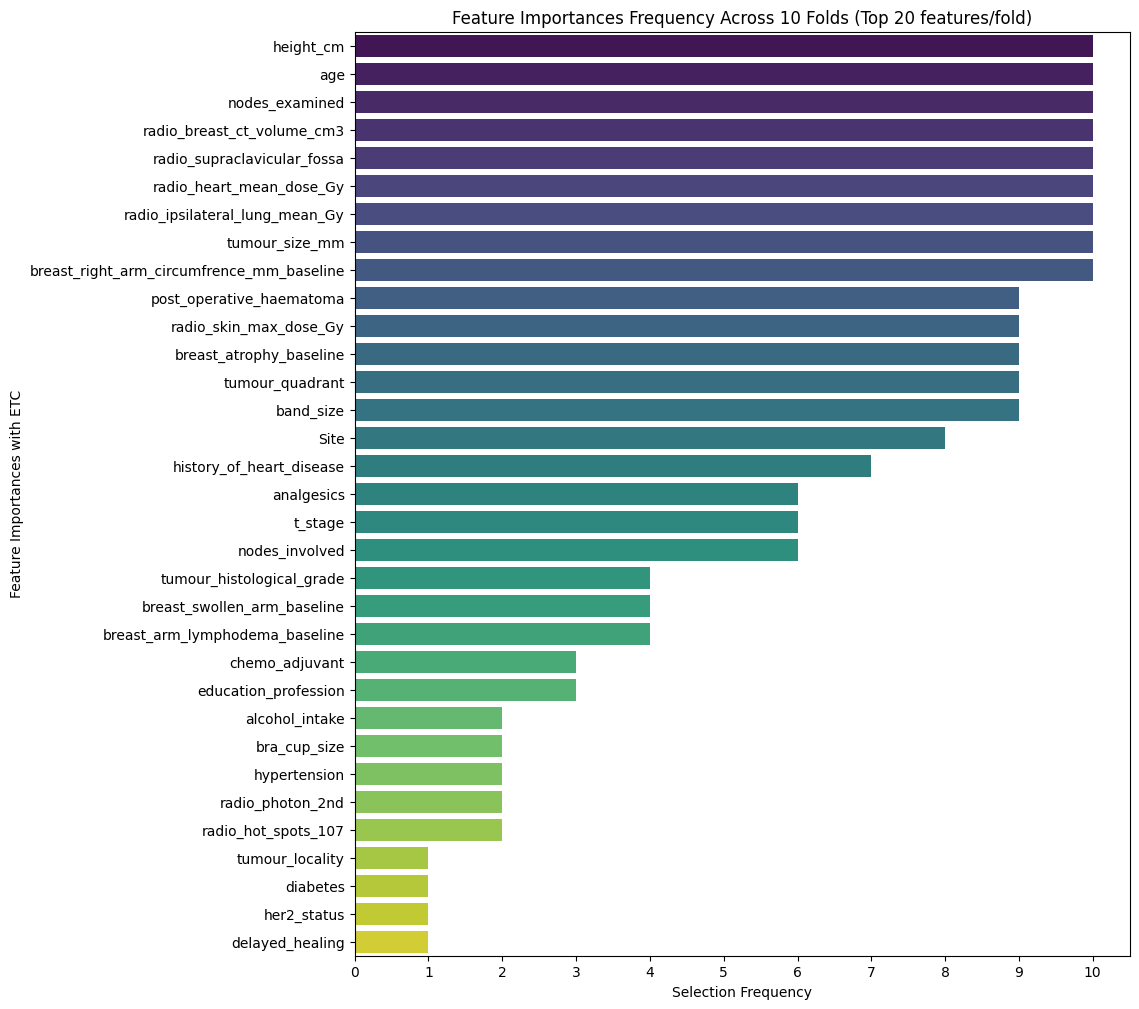

+-------------------------------------------+-------------+
|                                           |   Frequency |
|-------------------------------------------+-------------|
| height_cm                                 |          10 |
| age                                       |          10 |
| nodes_examined                            |          10 |
| radio_breast_ct_volume_cm3                |          10 |
| radio_supraclavicular_fossa               |          10 |
| radio_heart_mean_dose_Gy                  |          10 |
| radio_ipsilateral_lung_mean_Gy            |          10 |
| tumour_size_mm                            |          10 |
| breast_right_arm_circumfrence_mm_baseline |          10 |
| post_operative_haematoma                  |           9 |
| radio_skin_max_dose_Gy                    |           9 |
| breast_atrophy_baseline                   |           9 |
| tumour_quadrant                           |           9 |
| band_size                             

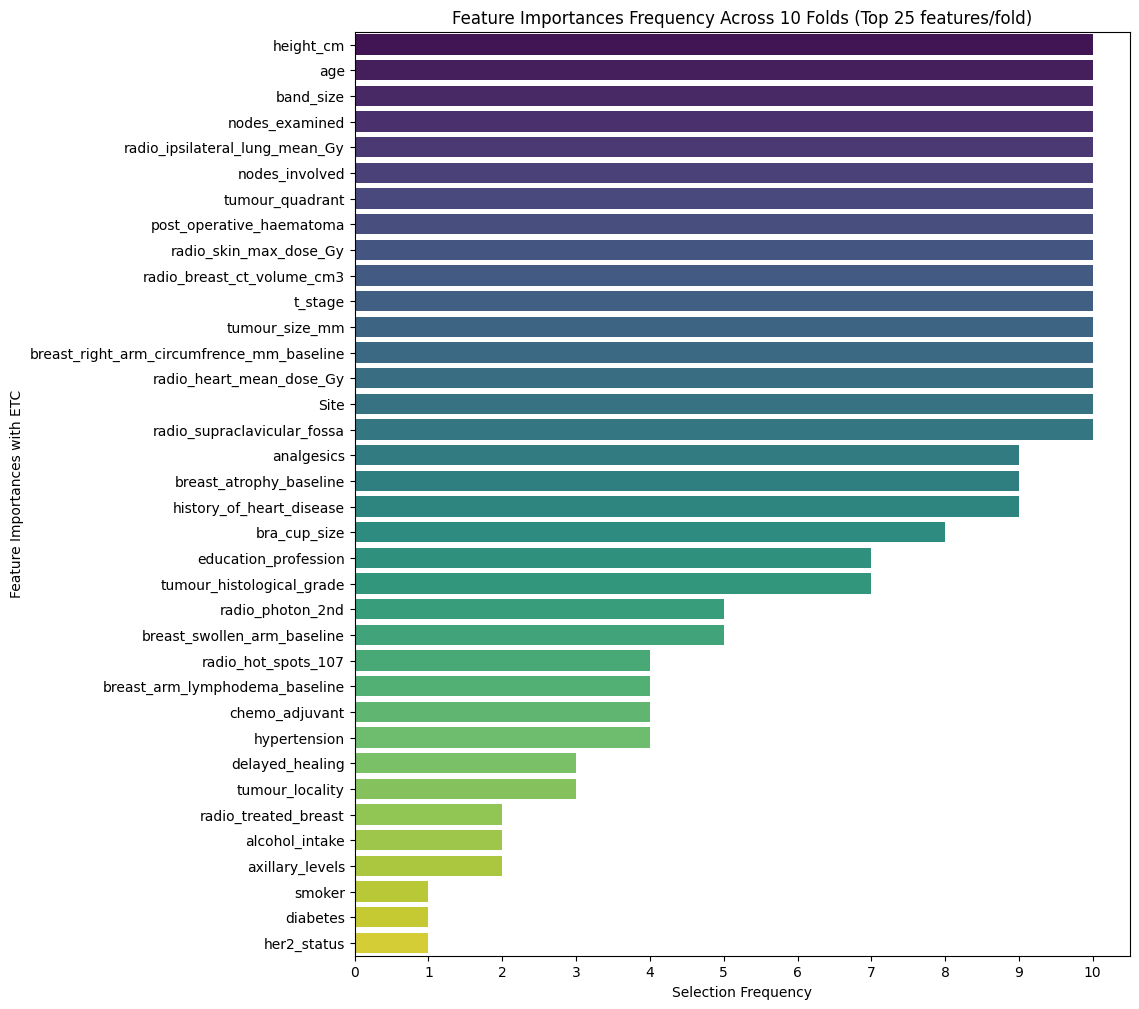

+-------------------------------------------+-------------+
|                                           |   Frequency |
|-------------------------------------------+-------------|
| height_cm                                 |          10 |
| age                                       |          10 |
| band_size                                 |          10 |
| nodes_examined                            |          10 |
| radio_ipsilateral_lung_mean_Gy            |          10 |
| nodes_involved                            |          10 |
| tumour_quadrant                           |          10 |
| post_operative_haematoma                  |          10 |
| radio_skin_max_dose_Gy                    |          10 |
| radio_breast_ct_volume_cm3                |          10 |
| t_stage                                   |          10 |
| tumour_size_mm                            |          10 |
| breast_right_arm_circumfrence_mm_baseline |          10 |
| radio_heart_mean_dose_Gy              

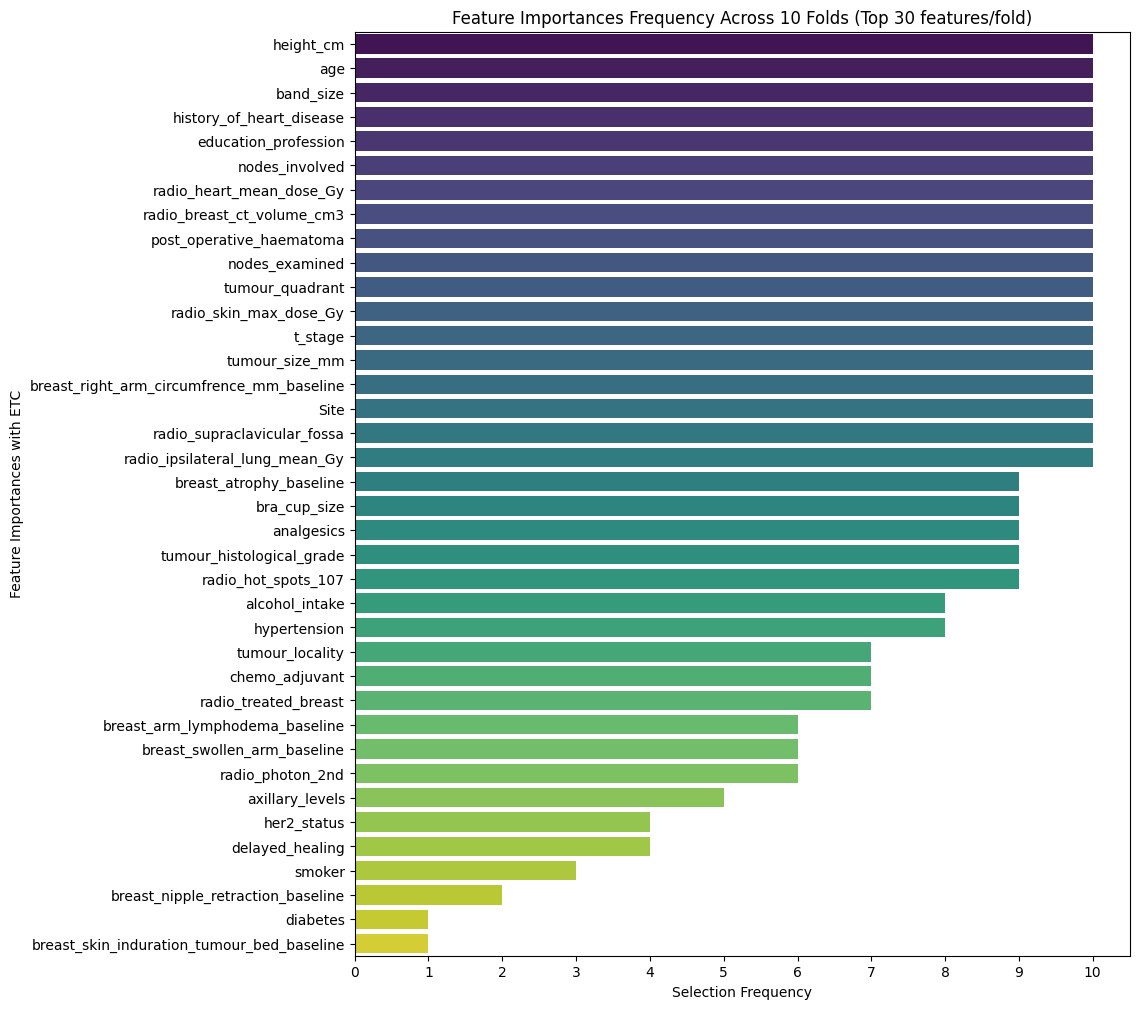

+--------------------------------------------+-------------+
|                                            |   Frequency |
|--------------------------------------------+-------------|
| height_cm                                  |          10 |
| age                                        |          10 |
| band_size                                  |          10 |
| history_of_heart_disease                   |          10 |
| education_profession                       |          10 |
| nodes_involved                             |          10 |
| radio_heart_mean_dose_Gy                   |          10 |
| radio_breast_ct_volume_cm3                 |          10 |
| post_operative_haematoma                   |          10 |
| nodes_examined                             |          10 |
| tumour_quadrant                            |          10 |
| radio_skin_max_dose_Gy                     |          10 |
| t_stage                                    |          10 |
| tumour_size_mm        

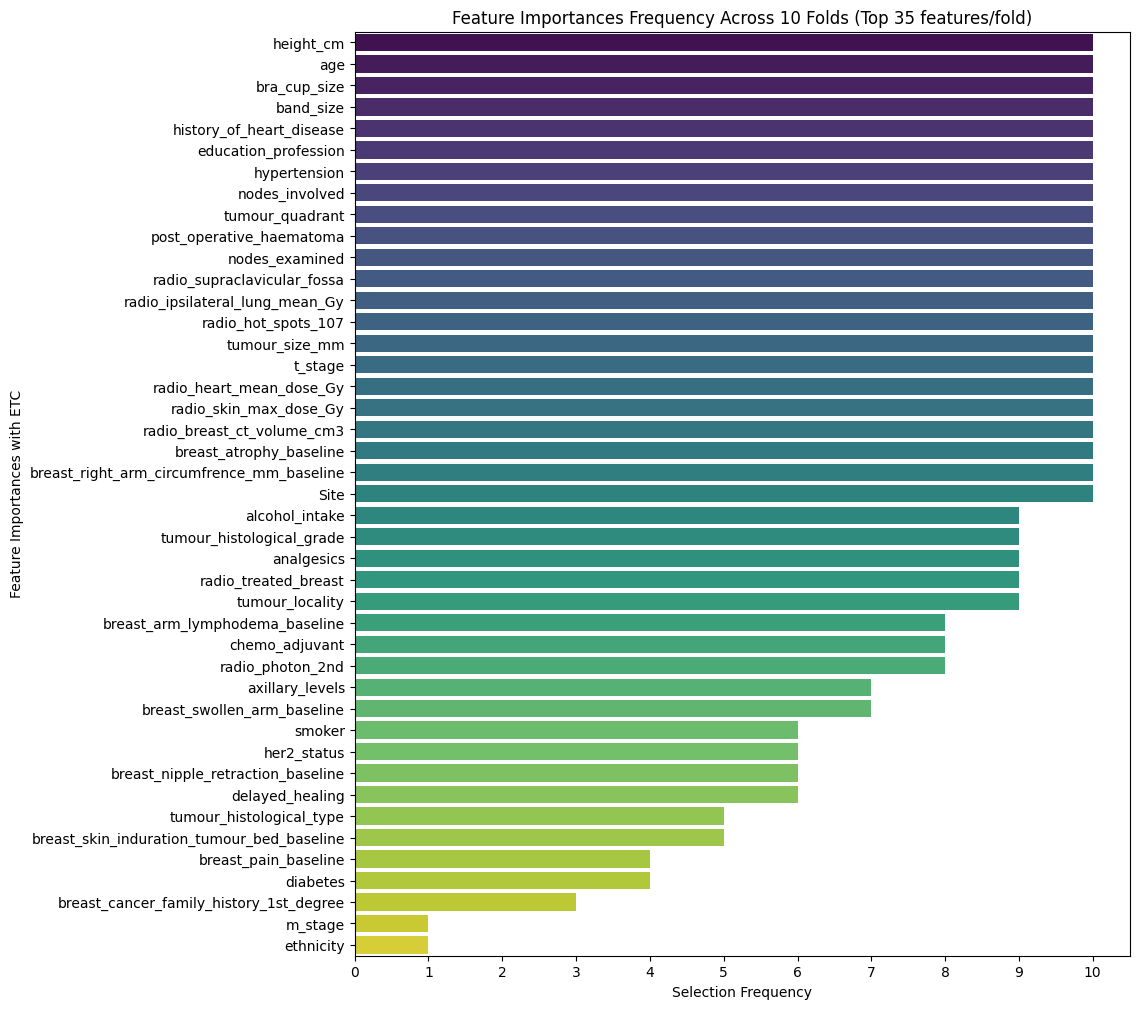

+--------------------------------------------+-------------+
|                                            |   Frequency |
|--------------------------------------------+-------------|
| height_cm                                  |          10 |
| age                                        |          10 |
| bra_cup_size                               |          10 |
| band_size                                  |          10 |
| history_of_heart_disease                   |          10 |
| education_profession                       |          10 |
| hypertension                               |          10 |
| nodes_involved                             |          10 |
| tumour_quadrant                            |          10 |
| post_operative_haematoma                   |          10 |
| nodes_examined                             |          10 |
| radio_supraclavicular_fossa                |          10 |
| radio_ipsilateral_lung_mean_Gy             |          10 |
| radio_hot_spots_107   

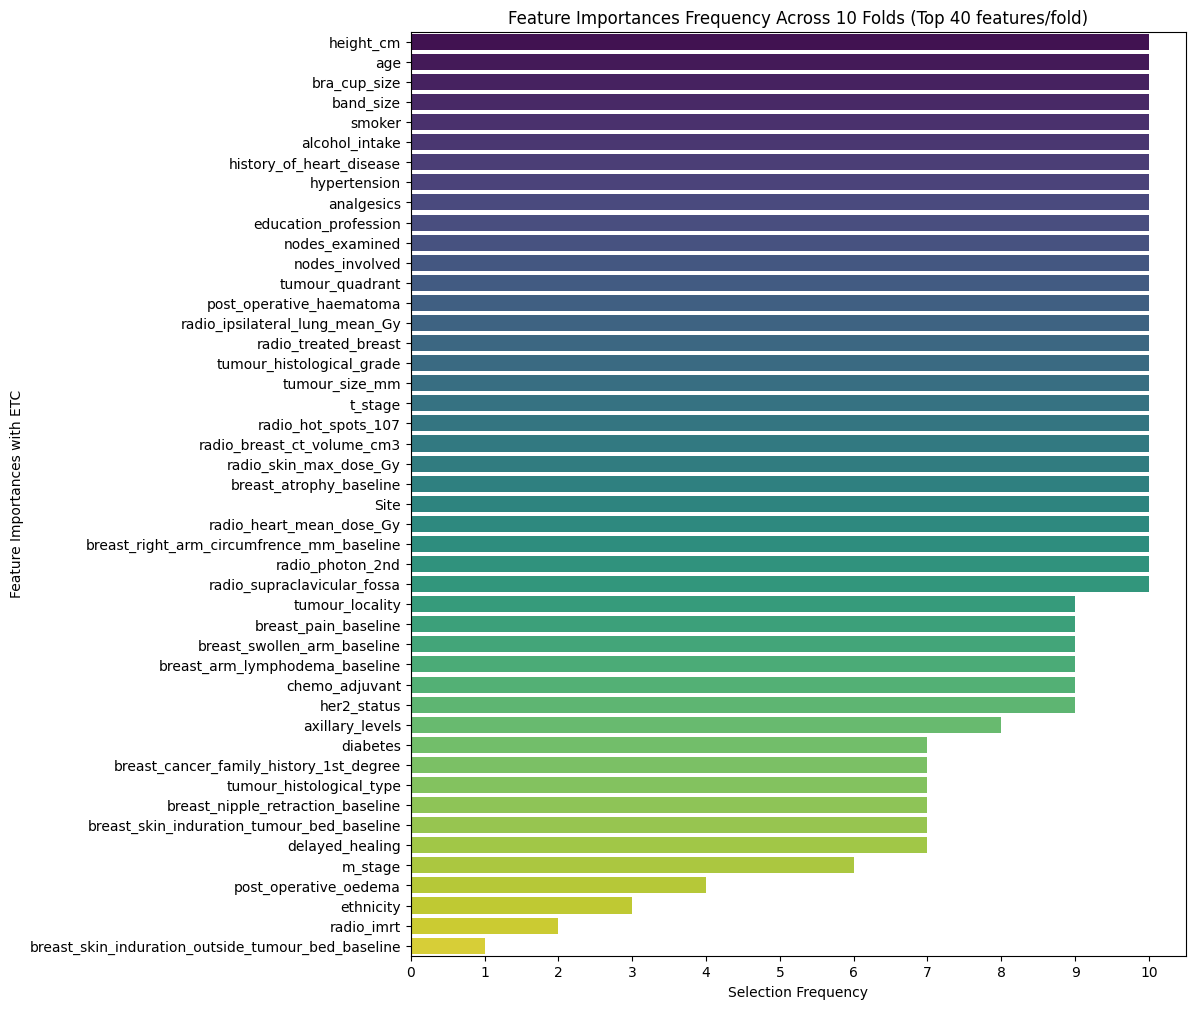

+----------------------------------------------------+-------------+
|                                                    |   Frequency |
|----------------------------------------------------+-------------|
| height_cm                                          |          10 |
| age                                                |          10 |
| bra_cup_size                                       |          10 |
| band_size                                          |          10 |
| smoker                                             |          10 |
| alcohol_intake                                     |          10 |
| history_of_heart_disease                           |          10 |
| hypertension                                       |          10 |
| analgesics                                         |          10 |
| education_profession                               |          10 |
| nodes_examined                                     |          10 |
| nodes_involved                  

In [479]:
feature_sets_featimportance_inside_pipeline = {}

for i in k:
    freq_df2= featureselection2_freq(df_clinic_20, dependent1, k=i, n_splits=10)
    feature_sets_featimportance_inside_pipeline[i] = freq_df2

In [480]:
#print(feature_sets_featimportance_inside_pipeline)
stable_features_featimportance_inside_pipeline = get_frequent_features(
    feature_sets_featimportance_inside_pipeline,
    freq_threshold=8
)

print(stable_features_featimportance_inside_pipeline)
print(len(stable_features_featimportance_inside_pipeline))

['tumour_locality', 'tumour_size_mm', 'radio_skin_max_dose_Gy', 'Site', 't_stage', 'breast_right_arm_circumfrence_mm_baseline', 'radio_ipsilateral_lung_mean_Gy', 'radio_hot_spots_107', 'tumour_quadrant', 'alcohol_intake', 'education_profession', 'breast_atrophy_baseline', 'radio_supraclavicular_fossa', 'tumour_histological_grade', 'age', 'height_cm', 'history_of_heart_disease', 'breast_pain_baseline', 'breast_swollen_arm_baseline', 'chemo_adjuvant', 'radio_photon_2nd', 'post_operative_haematoma', 'smoker', 'radio_treated_breast', 'radio_breast_ct_volume_cm3', 'analgesics', 'nodes_examined', 'band_size', 'hypertension', 'breast_arm_lymphodema_baseline', 'radio_heart_mean_dose_Gy', 'axillary_levels', 'nodes_involved', 'bra_cup_size', 'her2_status']
35


In [481]:
#df_Top_selected = df_20[top_features_final + [dependent1]]
cross_validated_feature_selection(df_clinic_20[stable_features_featimportance_inside_pipeline + [dependent1]], dependent1, splits=10)

Original Data shape is (2067, 36)
Data shape after dropping missing target: (1691, 36)
✅ Mean AUC with final selected features: 0.8278


### Nested CV

In [402]:
def nested_cv_feature_selection2(
    df,
    target,
    k_list,
    outer_splits,
    inner_splits
):

    df = df.dropna()

    X = df.drop(columns=[target]).select_dtypes(include=["number"])
    y = df[target]

    outer_cv = StratifiedKFold(
        n_splits=outer_splits,
        shuffle=True,
        random_state=0
    )

    inner_cv = StratifiedKFold(
        n_splits=inner_splits,
        shuffle=True,
        random_state=1
    )

    results = {name: [] for name in get_models(X, y).keys()}
    fold_details = []

    for fold_id, (train_idx, test_idx) in enumerate(
        tqdm(outer_cv.split(X, y), desc="Outer CV"),
        start=1
    ):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        best_k = None
        best_score = -np.inf

        # ==============================
        # INNER LOOP: choose best k
        # ==============================
        for k in k_list:
            inner_scores = []

            for inner_train_idx, inner_val_idx in inner_cv.split(X_train, y_train):

                X_tr = X_train.iloc[inner_train_idx]
                X_val = X_train.iloc[inner_val_idx]
                y_tr = y_train.iloc[inner_train_idx]
                y_val = y_train.iloc[inner_val_idx]

                selector = SelectFromModel(
                    ExtraTreesClassifier(random_state=10),
                    threshold=-np.inf,
                    max_features=k
                )

                pipeline = Pipeline([
                    ("feature_selection", selector),
                    ("model", RandomForestClassifier(
                        n_estimators=100,
                        random_state=5
                    ))

                ])

                pipeline.fit(X_tr, y_tr)

                y_pred = pipeline.predict_proba(X_val)[:, 1]
                inner_scores.append(roc_auc_score(y_val, y_pred))

            mean_score = np.mean(inner_scores)

            if mean_score > best_score:
                best_score = mean_score
                best_k = k

        # ==============================
        # OUTER LOOP: train final models
        # ==============================
        models = get_models(X_train, y_train)

        for name, model in models.items():

            selector = SelectFromModel(
                ExtraTreesClassifier(random_state=10),
                threshold=-np.inf,
                max_features=best_k
            )

            pipeline = Pipeline([
                ("feature_selection", selector),
                ("model", model)
            ])

            pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict_proba(X_test)[:, 1]
            auc_score = roc_auc_score(y_test, y_pred)

            selected_mask = pipeline.named_steps[
                "feature_selection"
            ].get_support()

            selected_features = X_train.columns[selected_mask].tolist()

            results[name].append(auc_score)

            fold_details.append({
                "fold": fold_id,
                "model": name,
                "best_k": best_k,
                "inner_auc": best_score,
                "outer_auc": auc_score,
                "selected_features": selected_features
            })

    # ==============================
    # Model AUC summary
    # ==============================
    summary = {
        model: {
            "mean_auc": np.mean(scores),
            "std_auc": np.std(scores)
        }
        for model, scores in results.items()
    }

    summary = pd.DataFrame(summary).T.sort_values(
        by="mean_auc",
        ascending=False
    )

    fold_details = pd.DataFrame(fold_details)

    # ==============================
    # Feature frequency percentage
    # ==============================
    all_features = []

    for features in fold_details["selected_features"]:
        all_features.extend(features)

    feature_counts = Counter(all_features)

    feature_frequency = pd.DataFrame({
        "feature": feature_counts.keys(),
        "count": feature_counts.values()
    })

    feature_frequency["percentage"] = (
        100 * feature_frequency["count"] / len(fold_details)
    )

    feature_frequency = feature_frequency.sort_values(
        by="percentage",
        ascending=False
    ).reset_index(drop=True)

    return summary, fold_details, feature_frequency

In [482]:
summary2, fold_details2, feature_frequency2 = nested_cv_feature_selection2(df_clinic_20, dependent1, k_list=k, outer_splits=10, inner_splits=5)

Outer CV: 10it [03:49, 22.90s/it]


In [483]:
summary2

,mean_auc,std_auc
RandomForest,0.790046,0.107115


In [484]:
fold_details2

,fold,model,best_k,inner_auc,outer_auc,selected_features
0,1,RandomForest,40,0.769489,0.937500,"[height_cm, age, bra_cup_size, band_size, smok..."
1,2,RandomForest,15,0.827513,0.807292,"[age, band_size, history_of_heart_disease, ana..."
2,3,RandomForest,15,0.806170,0.565972,"[height_cm, age, history_of_heart_disease, nod..."
3,4,RandomForest,40,0.826708,0.673611,"[height_cm, age, bra_cup_size, band_size, smok..."
4,5,RandomForest,40,0.795060,0.788194,"[height_cm, age, bra_cup_size, band_size, smok..."
5,6,RandomForest,40,0.804439,0.930556,"[height_cm, age, bra_cup_size, band_size, smok..."
6,7,RandomForest,15,0.844067,0.756944,"[height_cm, age, analgesics, nodes_involved, n..."
7,8,RandomForest,15,0.826210,0.748264,"[height_cm, band_size, nodes_examined, post_op..."
8,9,RandomForest,35,0.783314,0.840278,"[height_cm, age, bra_cup_size, band_size, smok..."
9,10,RandomForest,40,0.792322,0.851852,"[height_cm, age, bra_cup_size, band_size, smok..."


In [485]:
#print(feature_frequency.head(40))
display(feature_frequency2.head(100))

,feature,count,percentage
0,nodes_examined,10,100.0
1,radio_ipsilateral_lung_mean_Gy,10,100.0
2,radio_breast_ct_volume_cm3,10,100.0
3,radio_heart_mean_dose_Gy,10,100.0
4,tumour_size_mm,10,100.0
5,post_operative_haematoma,10,100.0
6,radio_supraclavicular_fossa,10,100.0
7,breast_right_arm_circumfrence_mm_baseline,10,100.0
8,radio_skin_max_dose_Gy,9,90.0
9,height_cm,9,90.0


In [486]:
# Features that appeared in 8 folds and more across 10 folds
stable_features2 = feature_frequency2[feature_frequency2["count"] >= 8]["feature"].tolist()

In [487]:
print (stable_features2)

['nodes_examined', 'radio_ipsilateral_lung_mean_Gy', 'radio_breast_ct_volume_cm3', 'radio_heart_mean_dose_Gy', 'tumour_size_mm', 'post_operative_haematoma', 'radio_supraclavicular_fossa', 'breast_right_arm_circumfrence_mm_baseline', 'radio_skin_max_dose_Gy', 'height_cm', 'age', 'band_size', 'history_of_heart_disease', 'analgesics', 'Site', 'breast_atrophy_baseline', 't_stage']


In [494]:
print(len(stable_features2))

17


In [495]:
jaccard_stability(fold_details2, "RandomForest")

np.float64(0.5518183860166463)

In [496]:
cross_validated_feature_selection(df_clinic_20[stable_features2 + [dependent1]], dependent1, 10)

Original Data shape is (2067, 18)
Data shape after dropping missing target: (1691, 18)
✅ Mean AUC with final selected features: 0.8217


## Third feature selection method

**3.3.4 Recursive Feature Elimination (RFE)**

---


Recursive Feature Elimination (RFE) is a feature selection method used in machine learning to identify the most relevant features for a predictive model. It works by recursively removing less important features and building the model on the remaining features to determine their importance.

### outside CV

In [497]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, roc_auc_score
# This method ranking for example 20 features as rank 1 and other varies if set the features to 20 and so on

def rfe_feature_selection3(df, target_col, n_features):

    model = RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=1,
                bootstrap=True,
                random_state=5)

    # Drop rows with missing values
    df = df.dropna()

    # Separate features and target
    X = df.drop(columns=[target_col, 'Subject Id'])
    y = df[target_col]

    # Encode target if it's categorical
    #if y.dtype == 'object':
     #   y = LabelEncoder().fit_transform(y)

    # Split once for RFE
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=10)

    # RFE for top features
    rfe = RFE(estimator=model, n_features_to_select=n_features)
    rfe.fit(X_train, y_train)

    selected_features = X.columns[rfe.support_].tolist()
    bold('Process with'+ str(n_features) + ' Features:')
    print(f"\nList of top {n_features} features:\n", selected_features, '\n\n')

    # Cross-validated AUC on selected features
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    auc_scores = cross_val_score(model, X[selected_features], y, cv=skf, scoring='roc_auc')

    #print(f"Cross-Validated AUC Scores: {auc_scores}")
    print(f"Mean AUC: {auc_scores.mean():.4f} | Std: {auc_scores.std():.4f}")

    # Feature ranking
    feature_ranking = pd.DataFrame({
        'Feature': X.columns,
        'Ranking': rfe.ranking_
    }).sort_values(by='Ranking')

    # Plot the feature ranking
    plt.figure(figsize=(10, 20))
    sns.barplot(
        x='Ranking',
        y='Feature',
        data=feature_ranking,
        palette='viridis',
        order=feature_ranking.sort_values('Ranking')['Feature']
    )
    plt.title("Feature Ranking (RFE)")
    plt.xlabel("RFE Ranking (1 = Most Important)")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

    return selected_features, auc_scores.mean(), feature_ranking



List of top 10 features:
 ['height_cm', 'age', 'nodes_involved', 'nodes_examined', 'tumour_size_mm', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline'] 


Mean AUC: 0.7657 | Std: 0.1000


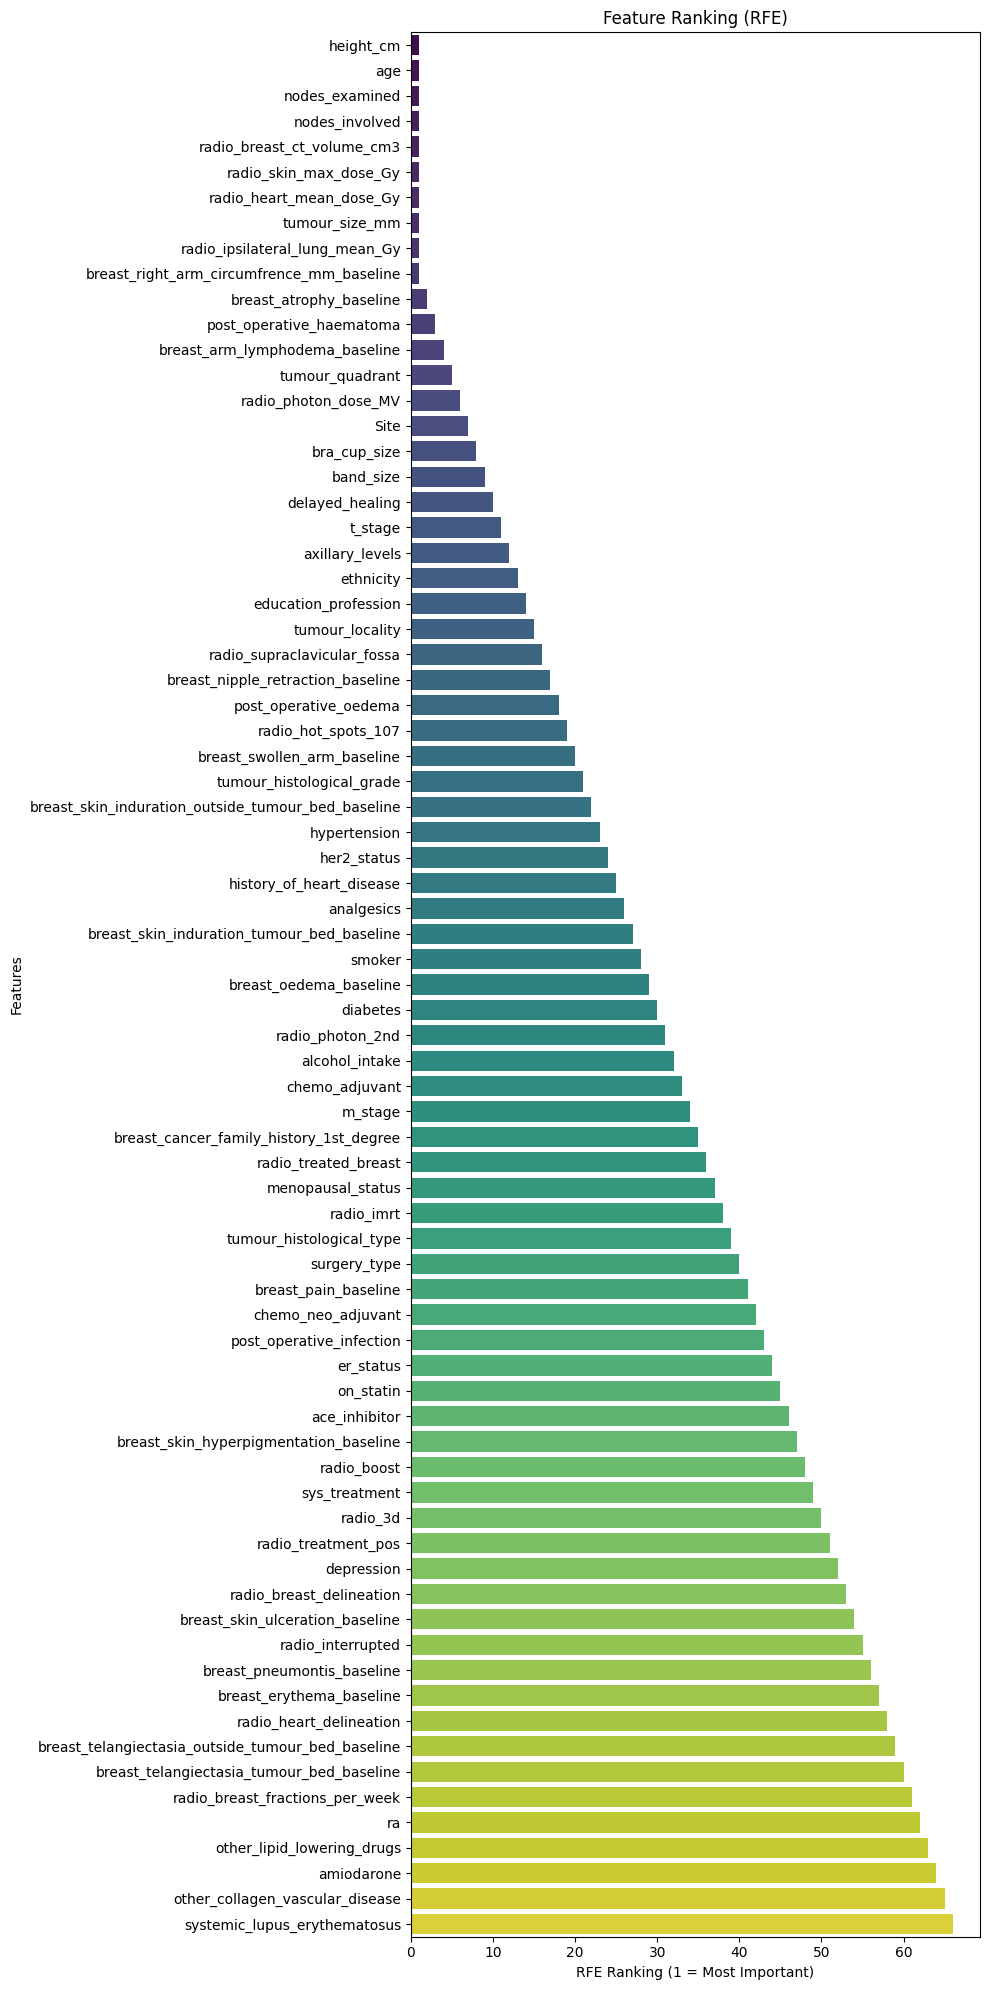


List of top 15 features:
 ['height_cm', 'age', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_atrophy_baseline', 'breast_arm_lymphodema_baseline', 'breast_right_arm_circumfrence_mm_baseline'] 


Mean AUC: 0.8182 | Std: 0.0781


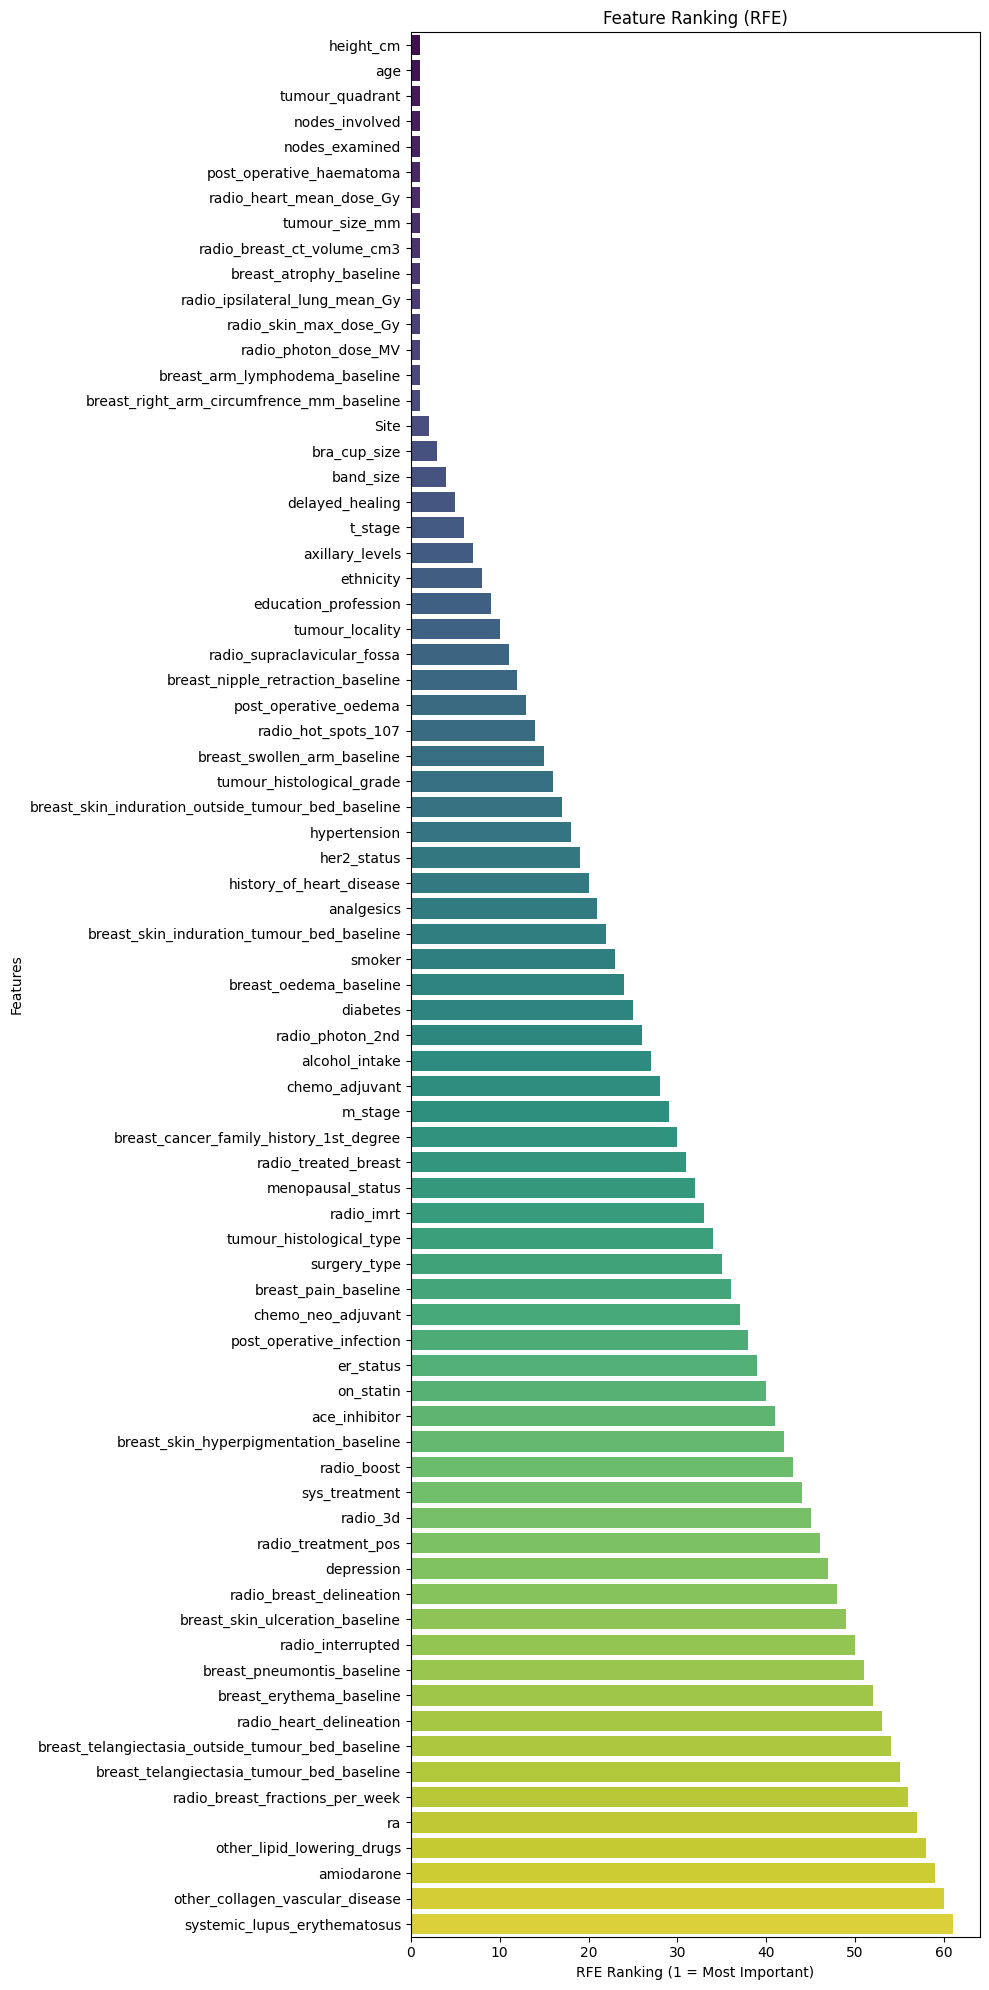


List of top 20 features:
 ['height_cm', 'age', 'bra_cup_size', 'band_size', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'delayed_healing', 'tumour_quadrant', 'tumour_size_mm', 't_stage', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'Site', 'breast_atrophy_baseline', 'breast_arm_lymphodema_baseline', 'breast_right_arm_circumfrence_mm_baseline'] 


Mean AUC: 0.8068 | Std: 0.0815


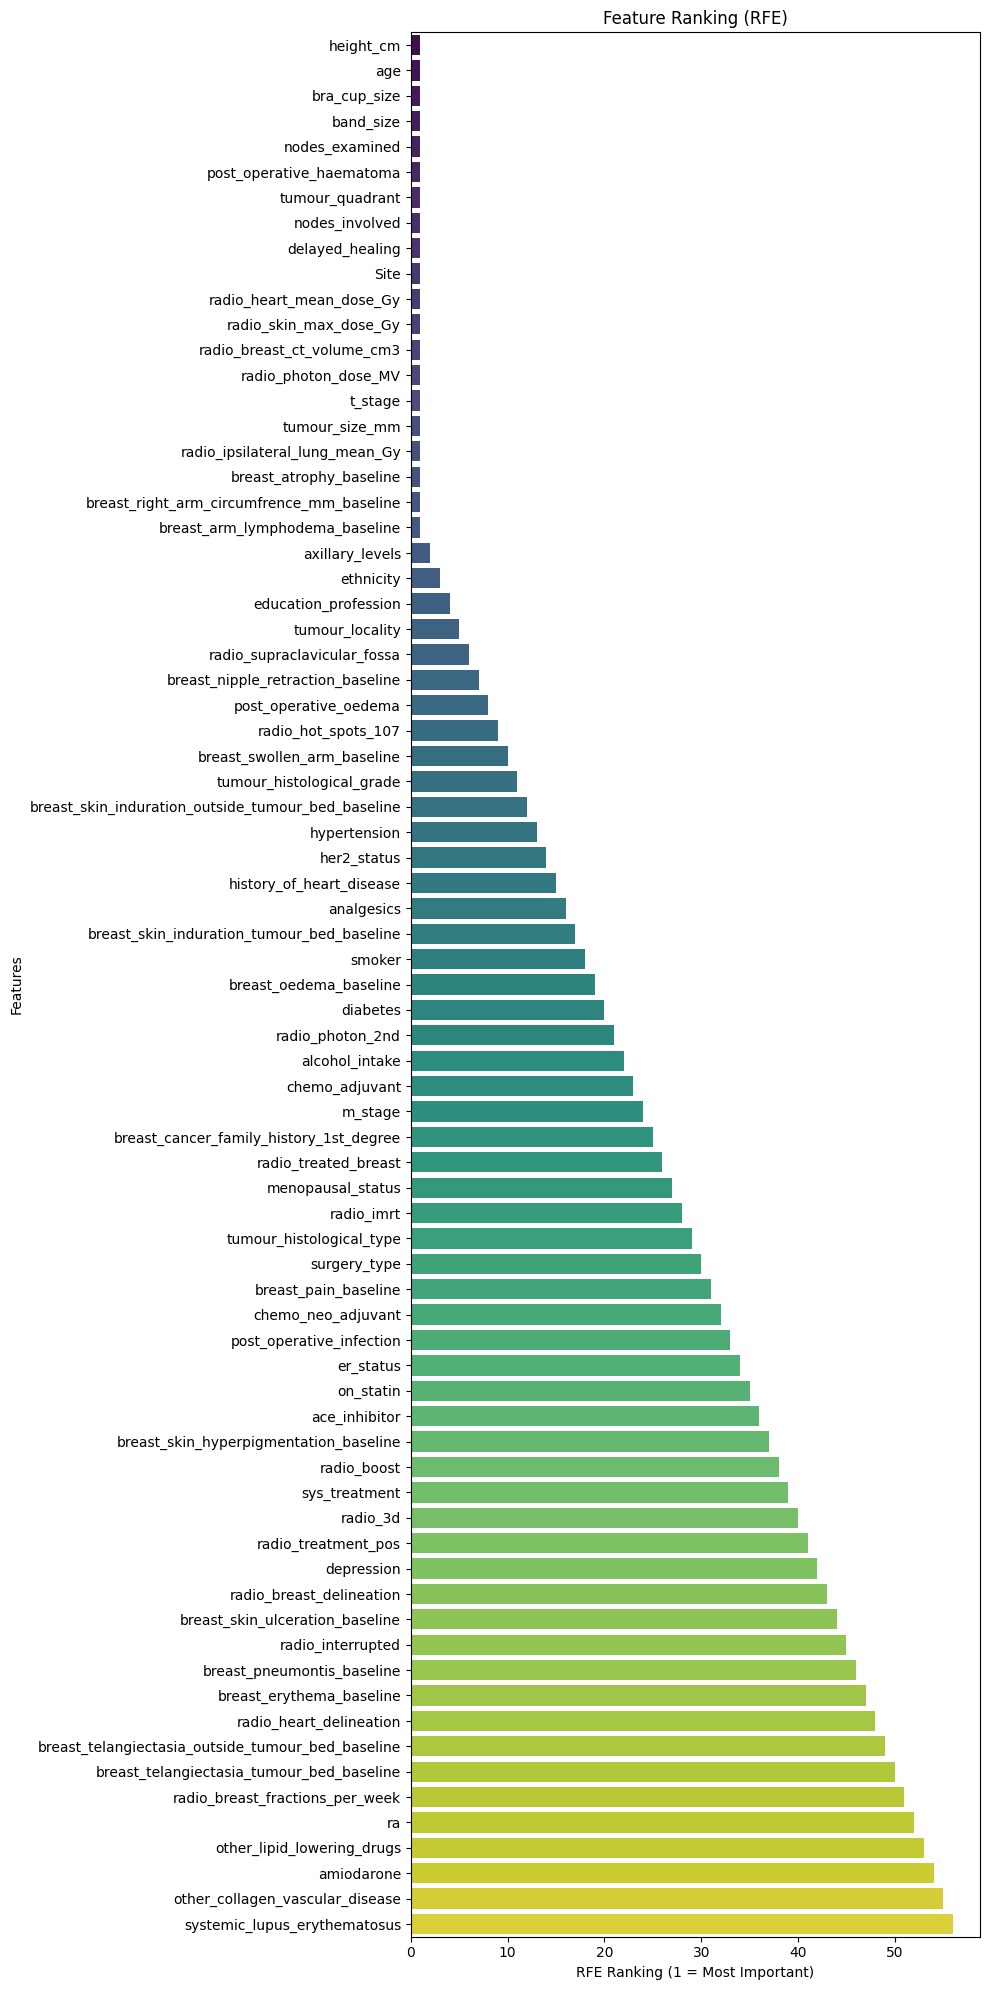


List of top 25 features:
 ['height_cm', 'age', 'bra_cup_size', 'band_size', 'ethnicity', 'education_profession', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'delayed_healing', 'tumour_quadrant', 'tumour_locality', 'tumour_size_mm', 't_stage', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'axillary_levels', 'radio_supraclavicular_fossa', 'Site', 'breast_atrophy_baseline', 'breast_arm_lymphodema_baseline', 'breast_right_arm_circumfrence_mm_baseline'] 


Mean AUC: 0.8191 | Std: 0.0676


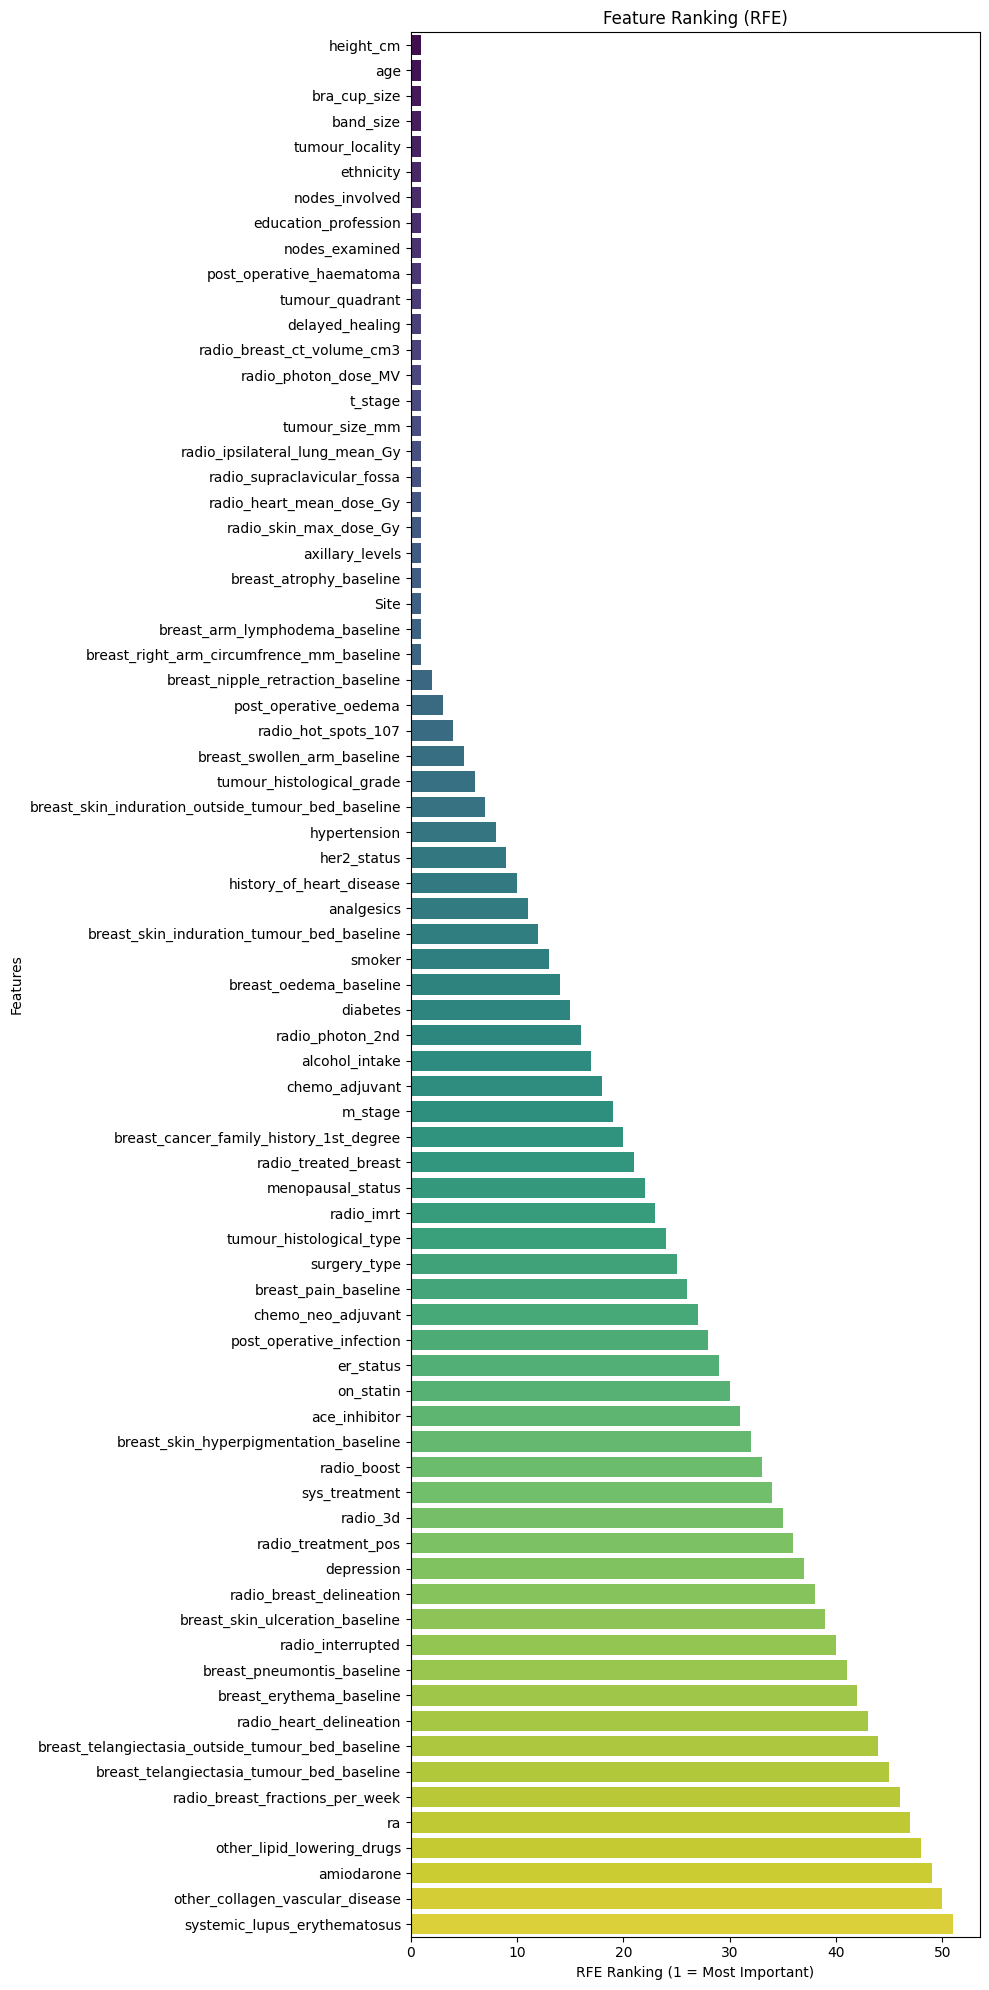


List of top 30 features:
 ['height_cm', 'age', 'bra_cup_size', 'band_size', 'ethnicity', 'education_profession', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'delayed_healing', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_size_mm', 't_stage', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_hot_spots_107', 'radio_ipsilateral_lung_mean_Gy', 'axillary_levels', 'radio_supraclavicular_fossa', 'Site', 'breast_atrophy_baseline', 'breast_nipple_retraction_baseline', 'breast_arm_lymphodema_baseline', 'breast_swollen_arm_baseline', 'breast_right_arm_circumfrence_mm_baseline'] 


Mean AUC: 0.8266 | Std: 0.0904


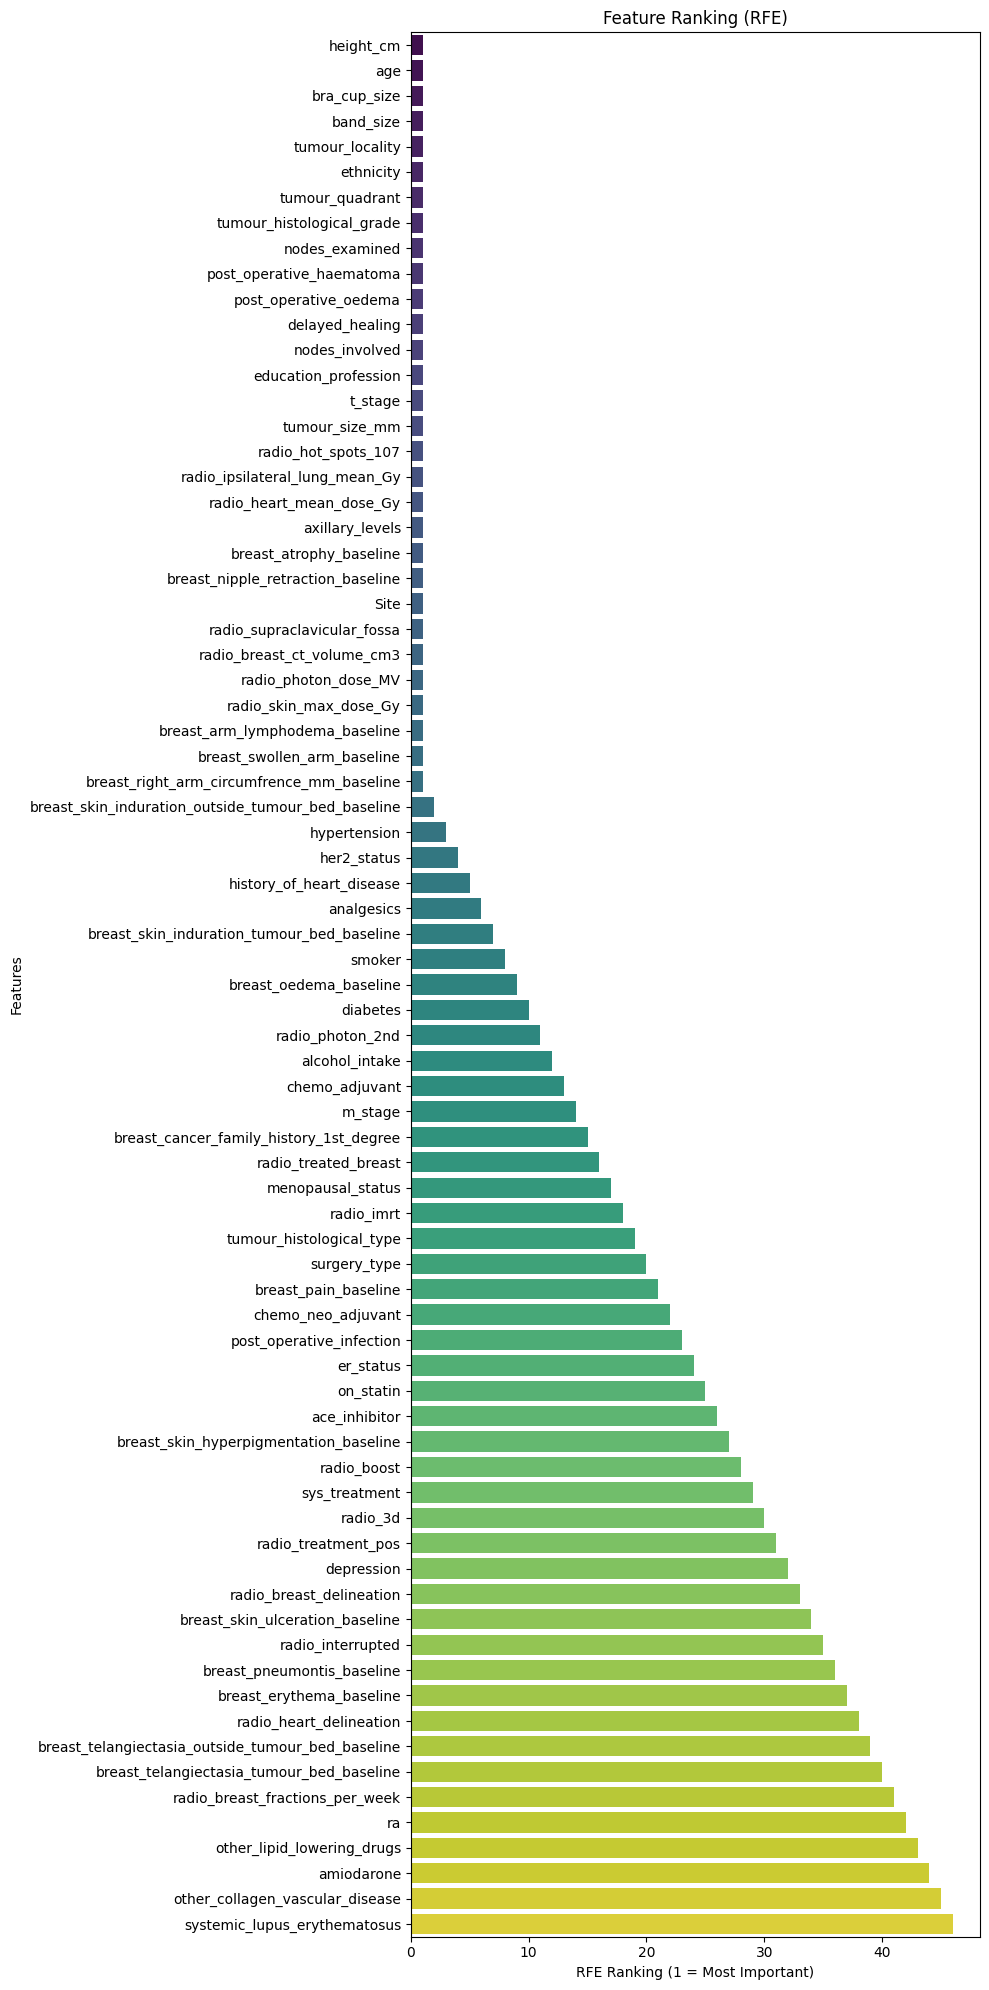


List of top 35 features:
 ['height_cm', 'age', 'bra_cup_size', 'band_size', 'history_of_heart_disease', 'hypertension', 'analgesics', 'ethnicity', 'education_profession', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'delayed_healing', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_size_mm', 't_stage', 'her2_status', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_hot_spots_107', 'radio_ipsilateral_lung_mean_Gy', 'axillary_levels', 'radio_supraclavicular_fossa', 'Site', 'breast_atrophy_baseline', 'breast_nipple_retraction_baseline', 'breast_skin_induration_outside_tumour_bed_baseline', 'breast_arm_lymphodema_baseline', 'breast_swollen_arm_baseline', 'breast_right_arm_circumfrence_mm_baseline'] 


Mean AUC: 0.8316 | Std: 0.0865


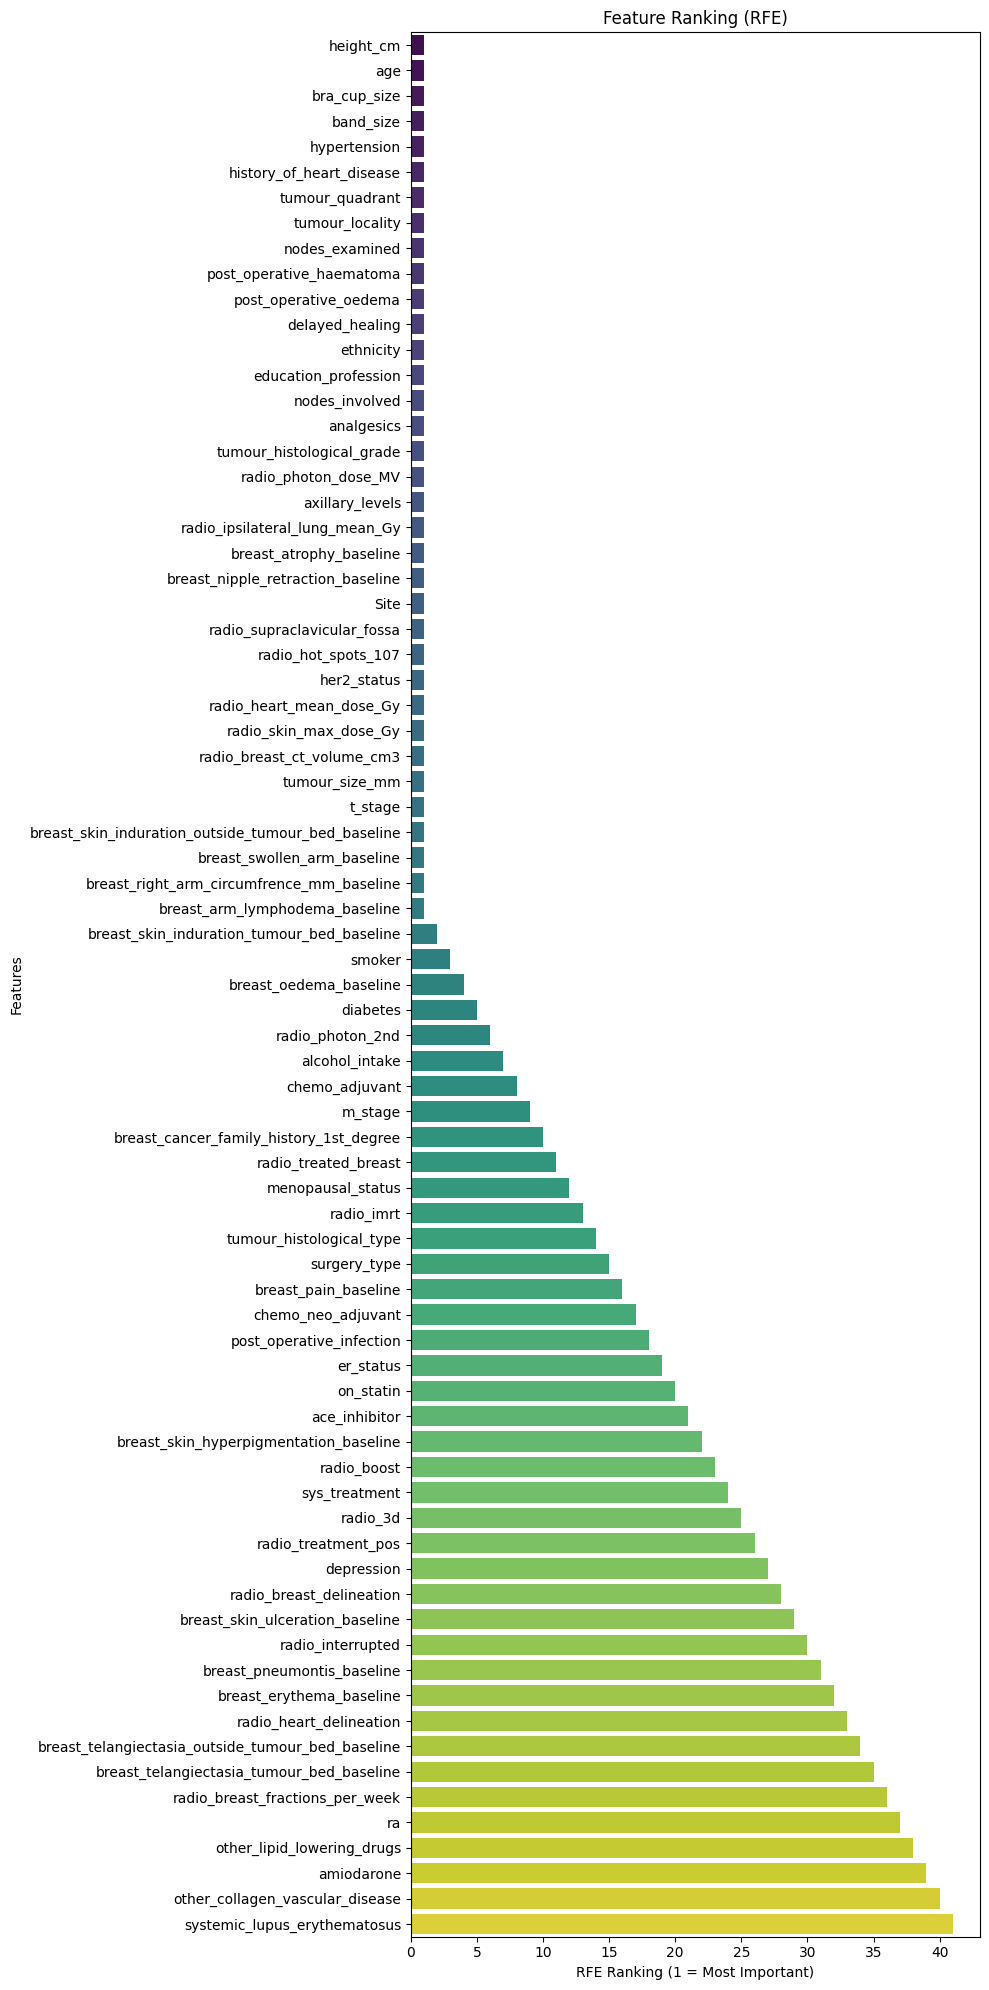


List of top 40 features:
 ['height_cm', 'age', 'bra_cup_size', 'band_size', 'smoker', 'diabetes', 'history_of_heart_disease', 'hypertension', 'analgesics', 'ethnicity', 'education_profession', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'delayed_healing', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_size_mm', 't_stage', 'her2_status', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_hot_spots_107', 'radio_ipsilateral_lung_mean_Gy', 'axillary_levels', 'radio_supraclavicular_fossa', 'radio_photon_2nd', 'Site', 'breast_atrophy_baseline', 'breast_nipple_retraction_baseline', 'breast_oedema_baseline', 'breast_skin_induration_tumour_bed_baseline', 'breast_skin_induration_outside_tumour_bed_baseline', 'breast_arm_lymphodema_baseline', 'breast_swollen_arm_baseline', 'breast_right_arm_circumfrence_mm_baseline'] 


Mean AUC: 0.8223 | Std: 0.0800


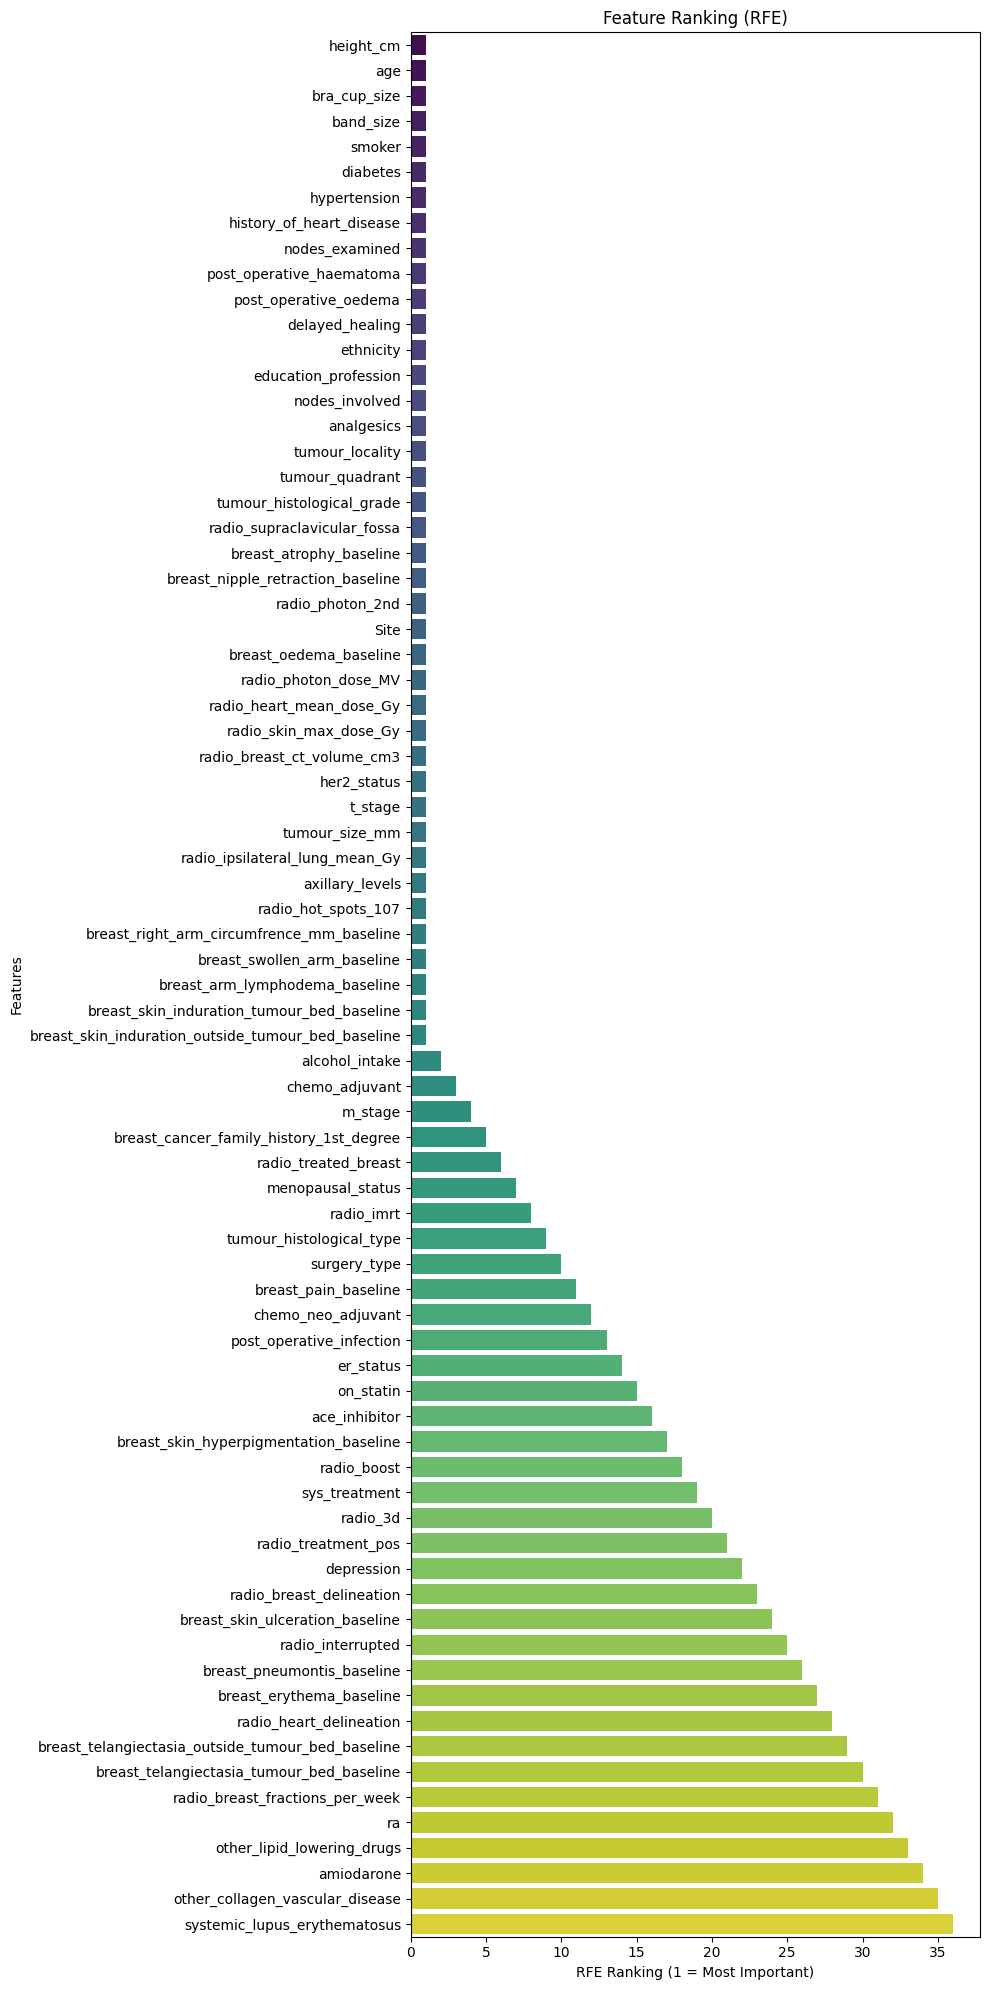

In [498]:

feature_sets_rfe = {}

for i in k:
    freq_df_scaled_auc= rfe_feature_selection3(df_clinic_20, dependent1, i)
    feature_sets_rfe[i] = freq_df_scaled_auc

In [499]:
from collections import Counter
import math

def get_stable_rfe_features(feature_sets_rfe, threshold_ratio=0.8):
    feature_counter = Counter()

    n_sets = len(feature_sets_rfe)
    threshold = math.ceil(threshold_ratio * n_sets)

    for k_value, (selected_features, auc, ranking_df) in feature_sets_rfe.items():

        # Features selected by RFE have Ranking == 1
        rfe_features = ranking_df.loc[
            ranking_df['Ranking'] == 1,
            'Feature'
        ].tolist()

        feature_counter.update(rfe_features)

    stable_features = [
        feature for feature, count in feature_counter.items()
        if count >= threshold
    ]

    return stable_features

In [500]:
stable_rfe_features = get_stable_rfe_features(
    feature_sets_rfe,
    threshold_ratio=0.8
)

print(stable_rfe_features)
print(len(stable_rfe_features))

['height_cm', 'age', 'nodes_examined', 'nodes_involved', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'tumour_size_mm', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline', 'tumour_quadrant', 'post_operative_haematoma', 'breast_atrophy_baseline', 'radio_photon_dose_MV', 'breast_arm_lymphodema_baseline']
15


In [501]:
cross_validated_feature_selection(df_clean_20[stable_rfe_features + [dependent1]], dependent1, 10)

Original Data shape is (2067, 16)
Data shape after dropping missing target: (1691, 16)
✅ Mean AUC with final selected features: 0.8300


### inside CV

In [502]:
def run_pipeline_with_feature_selection3(df, target_column, k):

    df = df.dropna()

    X = df.drop(columns=[target_column, 'Subject Id'])
    y = df[target_column]

    rf_for_rfe = RandomForestClassifier(n_estimators=100, max_depth=10,
                                        min_samples_split=5, min_samples_leaf=1,        bootstrap=True, random_state=5, n_jobs=-1)

    rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=10,
                                          min_samples_split=5, min_samples_leaf=1,
                                          bootstrap=True,  random_state=5, n_jobs=-1)

    rfe_selector = RFE(estimator=rf_for_rfe, n_features_to_select=k, step=0.1)

    pipeline_rfe = Pipeline([('rfe', rfe_selector), ('classifier', rf_classifier)])

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

    scores = cross_val_score(pipeline_rfe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

    print(f"Mean AUC score using top {k} features Inside CV: {scores.mean():.2f}")
    return scores.mean()


In [503]:
#rfe_feature_selection3(df_cl20, dependent1, 20)

auc_scores_rfe_inside_pipeline = {}

for i in k:
    freq_df_scaled_auc= run_pipeline_with_feature_selection3(df_clinic_20, dependent1, i)
    auc_scores_rfe_inside_pipeline[i] = freq_df_scaled_auc

Mean AUC score using top 10 features Inside CV: 0.77
Mean AUC score using top 15 features Inside CV: 0.77
Mean AUC score using top 20 features Inside CV: 0.79
Mean AUC score using top 25 features Inside CV: 0.79
Mean AUC score using top 30 features Inside CV: 0.80
Mean AUC score using top 35 features Inside CV: 0.81
Mean AUC score using top 40 features Inside CV: 0.82


### Features frequency inside pipeline

In [490]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

def featureselection3_freq(df, target_col, n_features, n_splits):

    from collections import Counter
    import matplotlib.pyplot as plt
    import seaborn as sns
    from tabulate import tabulate

    df = df.dropna()

    X = df.drop(columns=[target_col, 'Subject Id'])
    y = df[target_col]

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=0
    )

    auc_scores = []
    feature_counts = Counter()
    bold('Process with '+ str(n_features) + ' Features:')
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        rfe_model = RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=1,
            bootstrap=True,
            random_state=5,
            n_jobs=-1
        )

        final_model = RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=1,
            bootstrap=True,
            random_state=5,
            n_jobs=-1
        )

        rfe = RFE(
            estimator=rfe_model,
            n_features_to_select=n_features,
            step=0.1
        )

        rfe.fit(X_train, y_train)

        selected_features = X_train.columns[rfe.support_].tolist()

        final_model.fit(X_train[selected_features], y_train)

        y_pred_proba = final_model.predict_proba(
            X_test[selected_features]
        )[:, 1]

        auc = roc_auc_score(y_test, y_pred_proba)

        auc_scores.append(auc)

        feature_counts.update(selected_features)


        print(
            f"Fold {fold+1}: "
            f"AUC = {auc:.4f} | "
            f"Selected Features: {selected_features}"
        )

    print(
        f"\nMean AUC: {np.mean(auc_scores):.4f} across {n_features} features"
        f"| Std: {np.std(auc_scores):.4f}"
    )

    freq_df = pd.DataFrame.from_dict(
        feature_counts,
        orient='index',
        columns=['Frequency']
    ).sort_values(by='Frequency', ascending=False)

    plt.figure(figsize=(10, 12))

    sns.barplot(
        x='Frequency',
        y=freq_df.index,
        data=freq_df
    )

    plt.xlabel('Selection Frequency')
    plt.ylabel('Features')

    plt.title(f'Feature Selection Frequency Across {n_splits} Folds' )

    plt.xticks(np.arange(0, n_splits + 1, 1))

    plt.show()

    print(tabulate(freq_df, headers='keys', tablefmt='psql'))

    return freq_df


Fold 1: AUC = 0.8229 | Selected Features: ['height_cm', 'age', 'nodes_examined', 'tumour_size_mm', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'Site', 'breast_right_arm_circumfrence_mm_baseline']
Fold 2: AUC = 0.6910 | Selected Features: ['height_cm', 'age', 'nodes_examined', 'tumour_quadrant', 'tumour_size_mm', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline']
Fold 3: AUC = 0.7639 | Selected Features: ['height_cm', 'age', 'nodes_examined', 'tumour_quadrant', 'tumour_size_mm', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'breast_right_arm_circumfrence_mm_baseline']
Fold 4: AUC = 0.6823 | Selected Features: ['height_cm', 'age', 'nodes_involved', 'nodes_examined', 'tumour_size_mm', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_

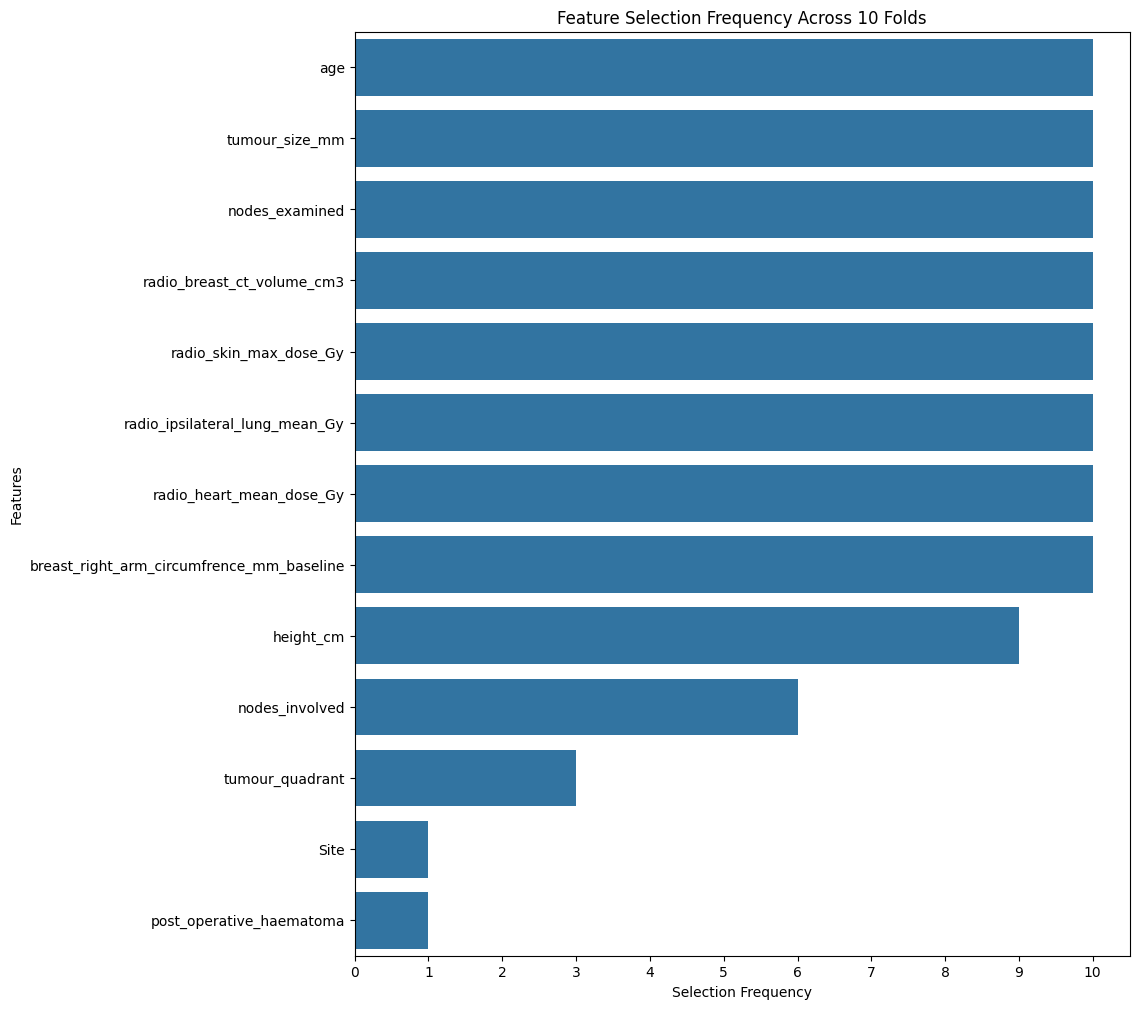

+-------------------------------------------+-------------+
|                                           |   Frequency |
|-------------------------------------------+-------------|
| age                                       |          10 |
| tumour_size_mm                            |          10 |
| nodes_examined                            |          10 |
| radio_breast_ct_volume_cm3                |          10 |
| radio_skin_max_dose_Gy                    |          10 |
| radio_ipsilateral_lung_mean_Gy            |          10 |
| radio_heart_mean_dose_Gy                  |          10 |
| breast_right_arm_circumfrence_mm_baseline |          10 |
| height_cm                                 |           9 |
| nodes_involved                            |           6 |
| tumour_quadrant                           |           3 |
| Site                                      |           1 |
| post_operative_haematoma                  |           1 |
+---------------------------------------

Fold 1: AUC = 0.8021 | Selected Features: ['height_cm', 'age', 'band_size', 'nodes_involved', 'nodes_examined', 'tumour_quadrant', 'tumour_size_mm', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'Site', 'breast_arm_lymphodema_baseline', 'breast_right_arm_circumfrence_mm_baseline']
Fold 2: AUC = 0.7535 | Selected Features: ['height_cm', 'age', 'band_size', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'axillary_levels', 'breast_atrophy_baseline', 'breast_right_arm_circumfrence_mm_baseline']
Fold 3: AUC = 0.7535 | Selected Features: ['height_cm', 'age', 'band_size', 'nodes_involved', 'nodes_examined', 'tumour_quadrant', 'tumour_size_mm', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_

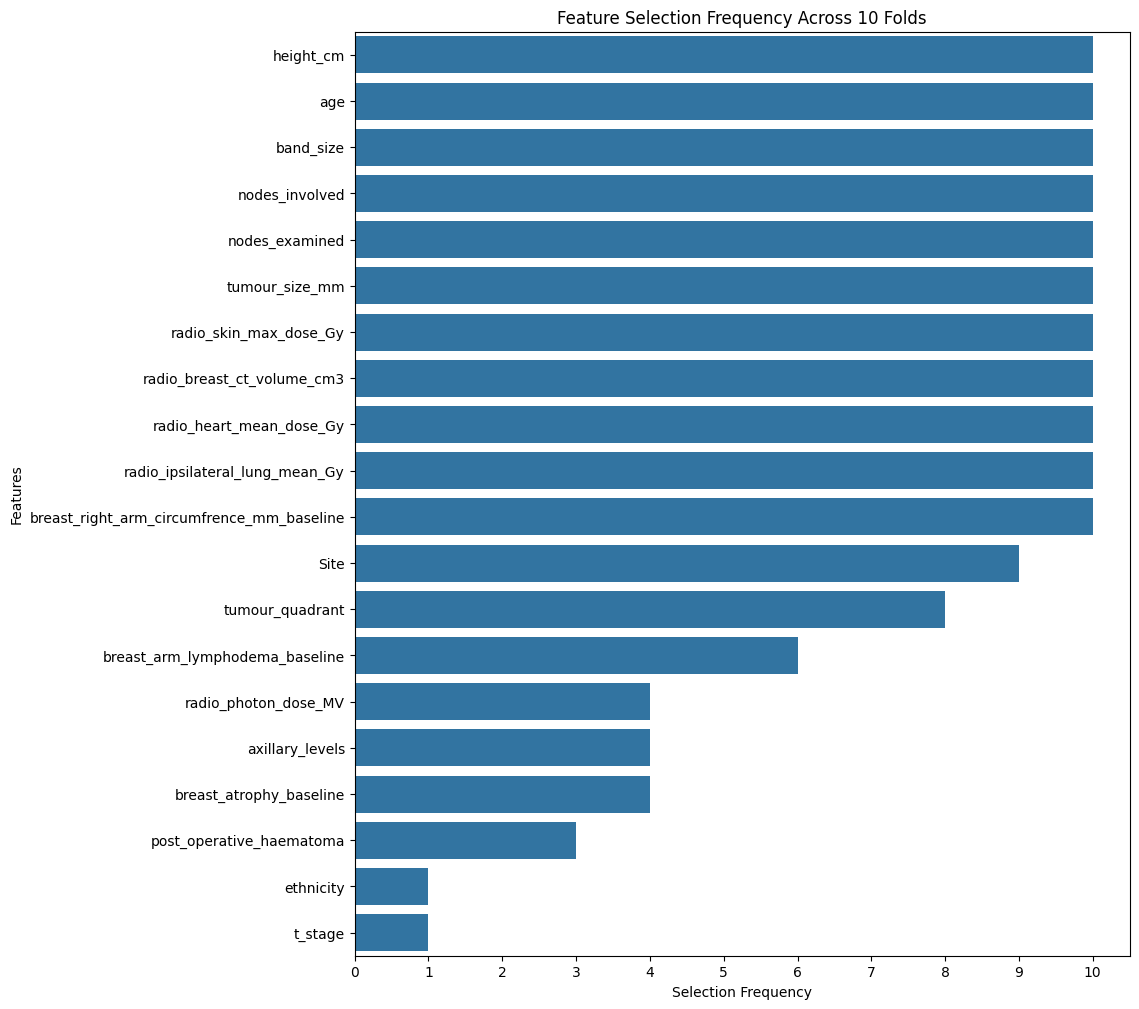

+-------------------------------------------+-------------+
|                                           |   Frequency |
|-------------------------------------------+-------------|
| height_cm                                 |          10 |
| age                                       |          10 |
| band_size                                 |          10 |
| nodes_involved                            |          10 |
| nodes_examined                            |          10 |
| tumour_size_mm                            |          10 |
| radio_skin_max_dose_Gy                    |          10 |
| radio_breast_ct_volume_cm3                |          10 |
| radio_heart_mean_dose_Gy                  |          10 |
| radio_ipsilateral_lung_mean_Gy            |          10 |
| breast_right_arm_circumfrence_mm_baseline |          10 |
| Site                                      |           9 |
| tumour_quadrant                           |           8 |
| breast_arm_lymphodema_baseline        

Fold 1: AUC = 0.8646 | Selected Features: ['height_cm', 'age', 'bra_cup_size', 'band_size', 'history_of_heart_disease', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'axillary_levels', 'Site', 'breast_atrophy_baseline', 'breast_arm_lymphodema_baseline', 'breast_right_arm_circumfrence_mm_baseline']
Fold 2: AUC = 0.7639 | Selected Features: ['height_cm', 'age', 'band_size', 'education_profession', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 't_stage', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'axillary_levels', 'radio_supraclavicular_fossa', 'Site', 'breast_atrophy_baseline', 'breast_right_arm_circumfrence_mm_baseline']
Fold 3: AUC = 0.7743

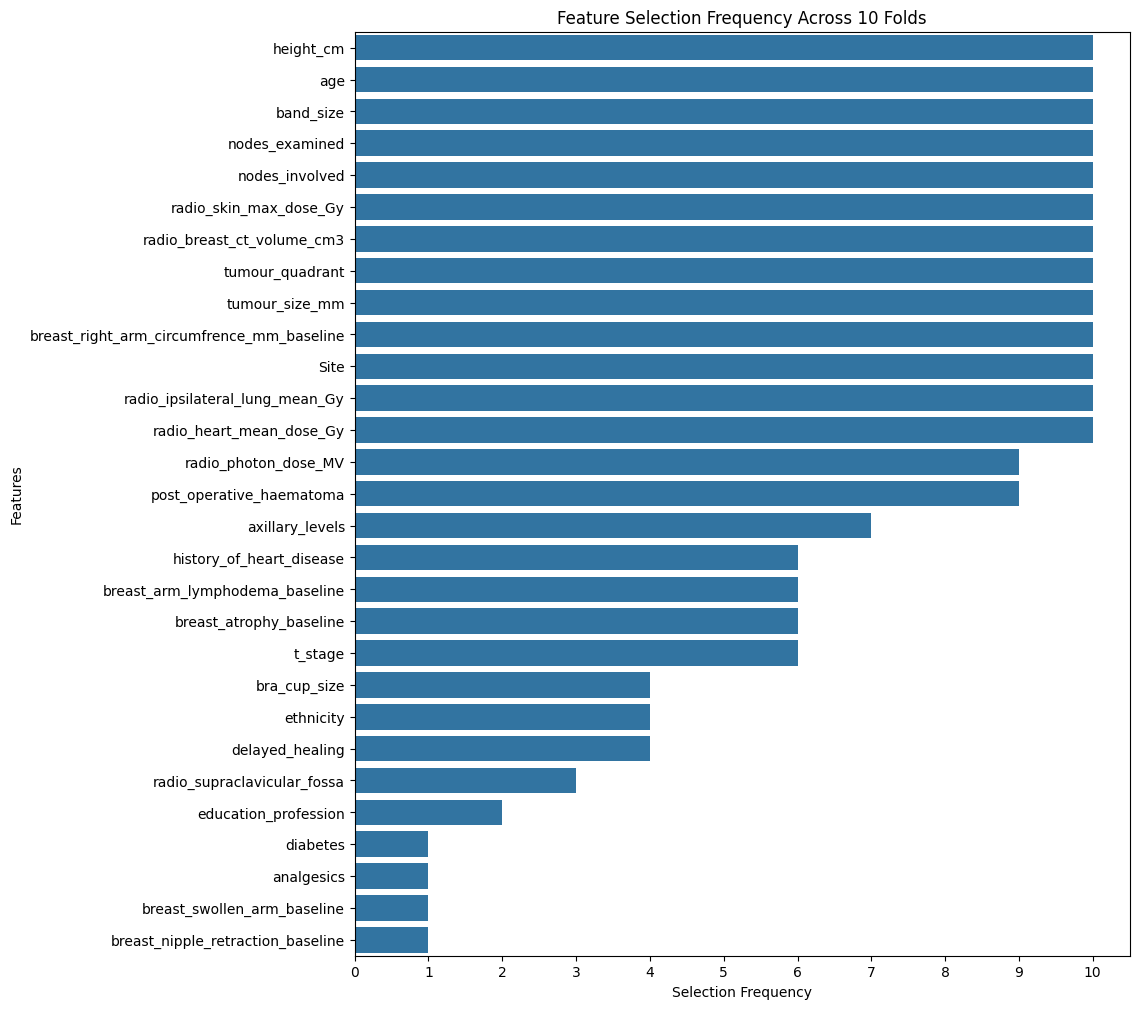

+-------------------------------------------+-------------+
|                                           |   Frequency |
|-------------------------------------------+-------------|
| height_cm                                 |          10 |
| age                                       |          10 |
| band_size                                 |          10 |
| nodes_examined                            |          10 |
| nodes_involved                            |          10 |
| radio_skin_max_dose_Gy                    |          10 |
| radio_breast_ct_volume_cm3                |          10 |
| tumour_quadrant                           |          10 |
| tumour_size_mm                            |          10 |
| breast_right_arm_circumfrence_mm_baseline |          10 |
| Site                                      |          10 |
| radio_ipsilateral_lung_mean_Gy            |          10 |
| radio_heart_mean_dose_Gy                  |          10 |
| radio_photon_dose_MV                  

Fold 1: AUC = 0.8785 | Selected Features: ['height_cm', 'age', 'bra_cup_size', 'band_size', 'history_of_heart_disease', 'analgesics', 'ethnicity', 'education_profession', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_size_mm', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'axillary_levels', 'radio_supraclavicular_fossa', 'Site', 'breast_atrophy_baseline', 'breast_arm_lymphodema_baseline', 'breast_swollen_arm_baseline', 'breast_right_arm_circumfrence_mm_baseline']
Fold 2: AUC = 0.7535 | Selected Features: ['height_cm', 'age', 'bra_cup_size', 'band_size', 'history_of_heart_disease', 'analgesics', 'ethnicity', 'education_profession', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'delayed_healing', 'tumour_quadrant', 'tumour_size_mm', 't_stage', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_he

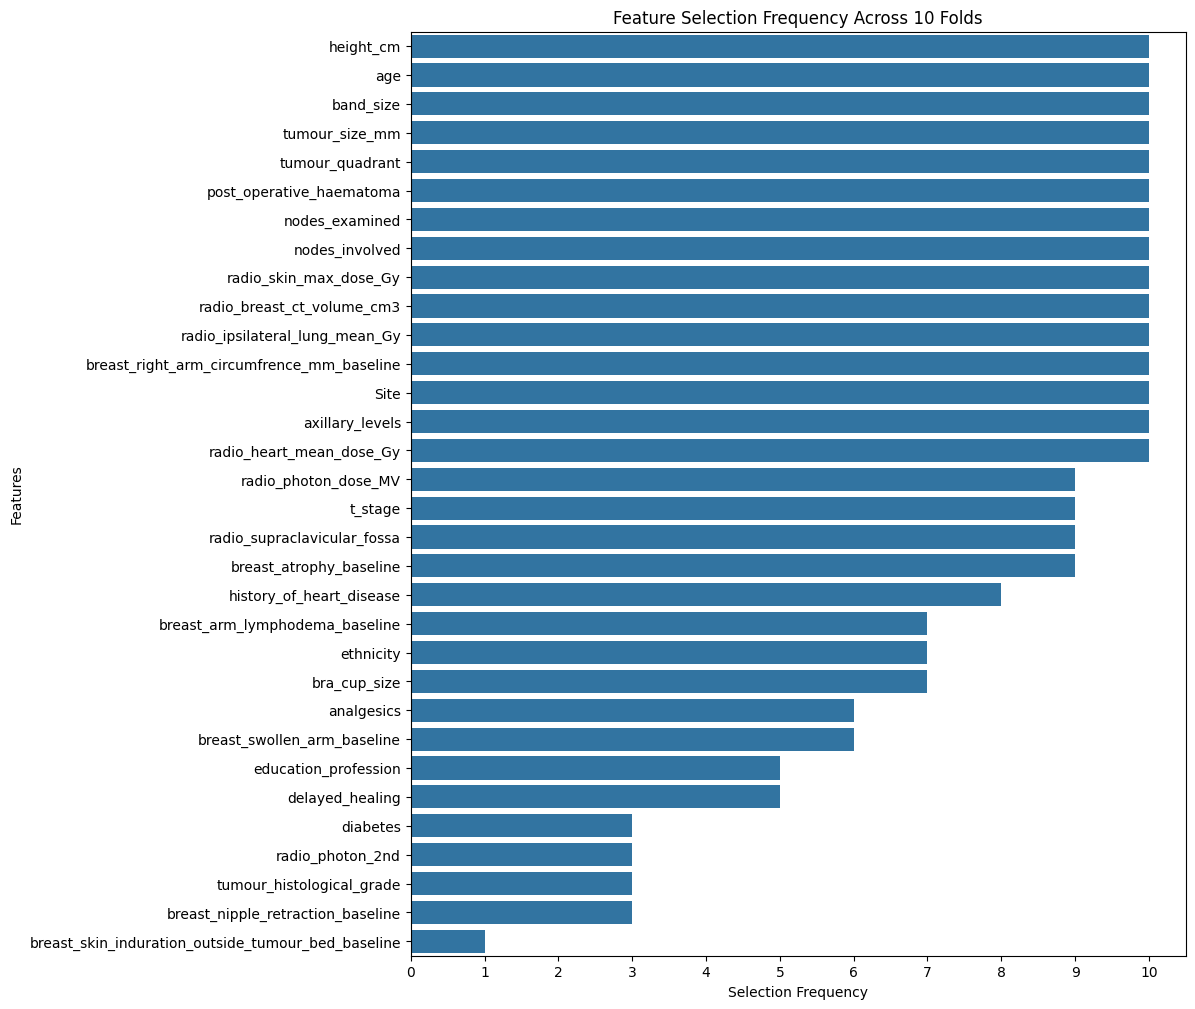

+----------------------------------------------------+-------------+
|                                                    |   Frequency |
|----------------------------------------------------+-------------|
| height_cm                                          |          10 |
| age                                                |          10 |
| band_size                                          |          10 |
| tumour_size_mm                                     |          10 |
| tumour_quadrant                                    |          10 |
| post_operative_haematoma                           |          10 |
| nodes_examined                                     |          10 |
| nodes_involved                                     |          10 |
| radio_skin_max_dose_Gy                             |          10 |
| radio_breast_ct_volume_cm3                         |          10 |
| radio_ipsilateral_lung_mean_Gy                     |          10 |
| breast_right_arm_circumfrence_mm

Fold 1: AUC = 0.8785 | Selected Features: ['height_cm', 'age', 'bra_cup_size', 'band_size', 'smoker', 'history_of_heart_disease', 'hypertension', 'analgesics', 'ethnicity', 'education_profession', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_histological_grade', 'tumour_size_mm', 'her2_status', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'axillary_levels', 'radio_supraclavicular_fossa', 'radio_photon_2nd', 'Site', 'breast_atrophy_baseline', 'breast_arm_lymphodema_baseline', 'breast_swollen_arm_baseline', 'breast_right_arm_circumfrence_mm_baseline']
Fold 2: AUC = 0.7951 | Selected Features: ['height_cm', 'age', 'bra_cup_size', 'band_size', 'diabetes', 'history_of_heart_disease', 'analgesics', 'ethnicity', 'education_profession', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'delayed_healing', 'tumour_quadrant', 'tumour_locality

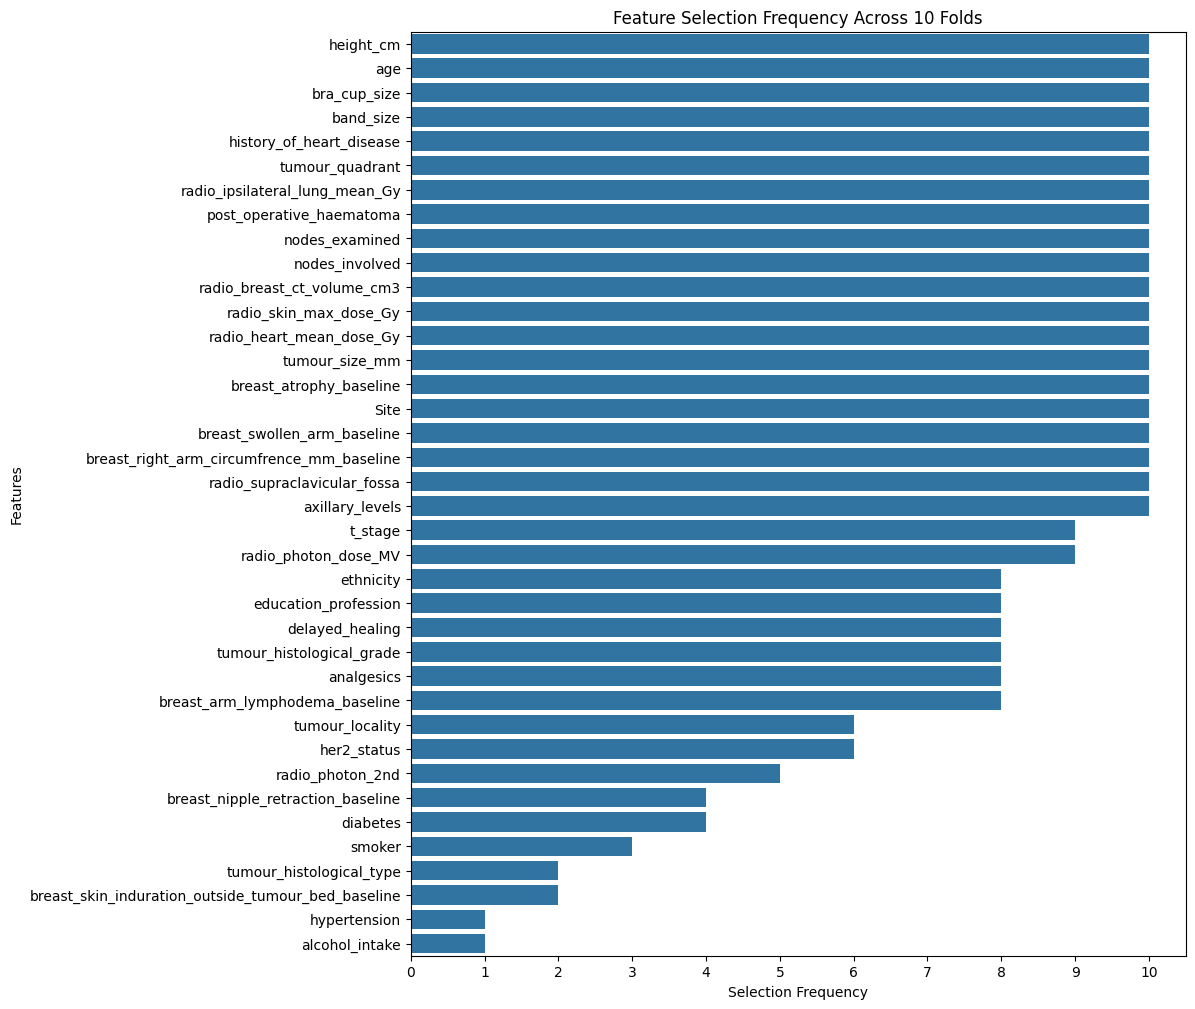

+----------------------------------------------------+-------------+
|                                                    |   Frequency |
|----------------------------------------------------+-------------|
| height_cm                                          |          10 |
| age                                                |          10 |
| bra_cup_size                                       |          10 |
| band_size                                          |          10 |
| history_of_heart_disease                           |          10 |
| tumour_quadrant                                    |          10 |
| radio_ipsilateral_lung_mean_Gy                     |          10 |
| post_operative_haematoma                           |          10 |
| nodes_examined                                     |          10 |
| nodes_involved                                     |          10 |
| radio_breast_ct_volume_cm3                         |          10 |
| radio_skin_max_dose_Gy          

Fold 1: AUC = 0.9201 | Selected Features: ['height_cm', 'age', 'bra_cup_size', 'band_size', 'smoker', 'diabetes', 'history_of_heart_disease', 'hypertension', 'analgesics', 'ethnicity', 'education_profession', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'tumour_quadrant', 'tumour_histological_grade', 'tumour_size_mm', 't_stage', 'her2_status', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'axillary_levels', 'radio_supraclavicular_fossa', 'radio_photon_2nd', 'Site', 'breast_atrophy_baseline', 'breast_nipple_retraction_baseline', 'breast_telangiectasia_tumour_bed_baseline', 'breast_skin_induration_tumour_bed_baseline', 'breast_arm_lymphodema_baseline', 'breast_swollen_arm_baseline', 'breast_right_arm_circumfrence_mm_baseline']
Fold 2: AUC = 0.7847 | Selected Features: ['height_cm', 'age', 'bra_cup_size', 'band_size', 'diabetes', 'history_of_heart_disease', 'analgesics', 'eth

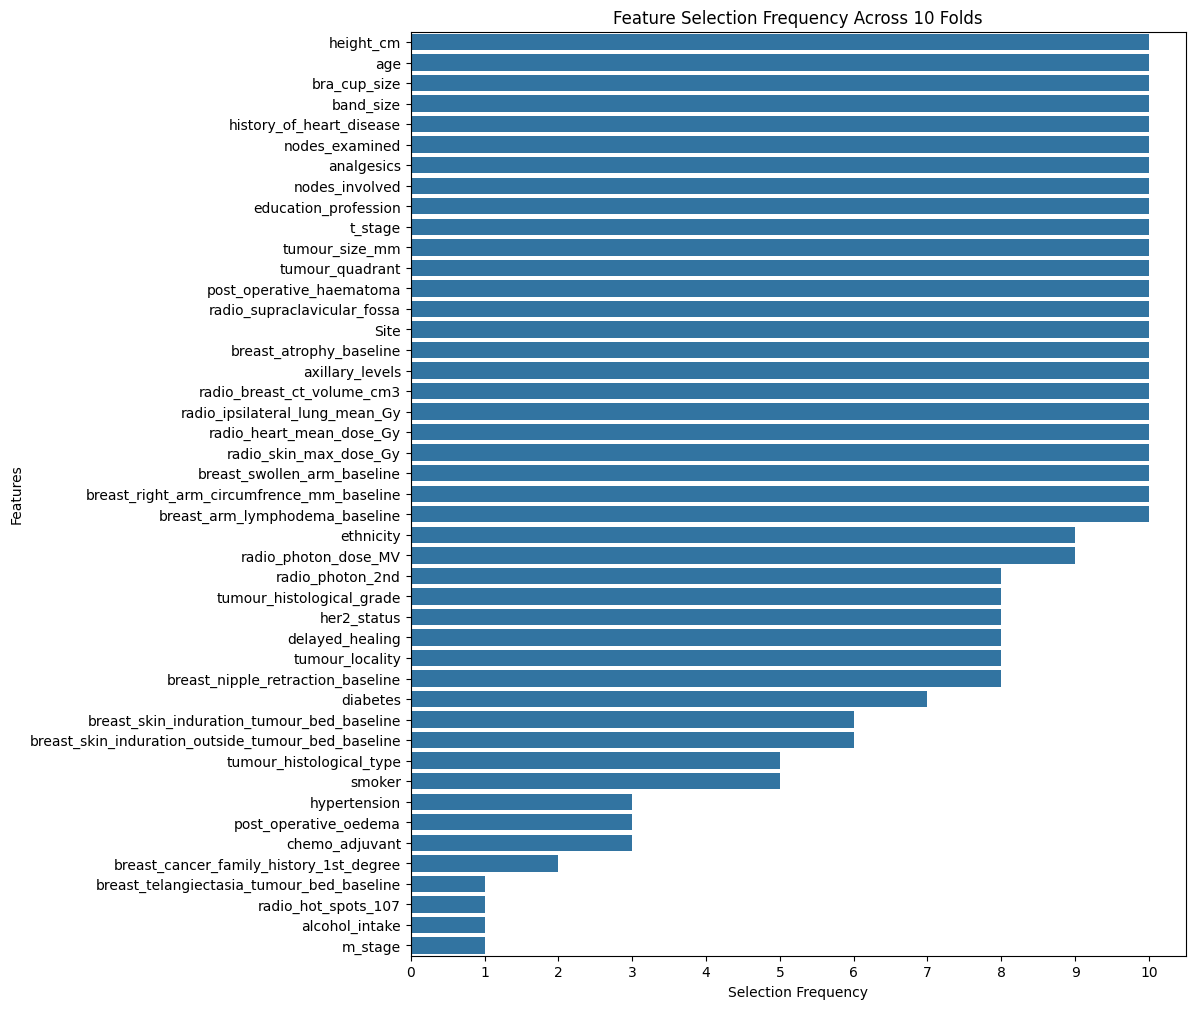

+----------------------------------------------------+-------------+
|                                                    |   Frequency |
|----------------------------------------------------+-------------|
| height_cm                                          |          10 |
| age                                                |          10 |
| bra_cup_size                                       |          10 |
| band_size                                          |          10 |
| history_of_heart_disease                           |          10 |
| nodes_examined                                     |          10 |
| analgesics                                         |          10 |
| nodes_involved                                     |          10 |
| education_profession                               |          10 |
| t_stage                                            |          10 |
| tumour_size_mm                                     |          10 |
| tumour_quadrant                 

Fold 1: AUC = 0.9167 | Selected Features: ['height_cm', 'age', 'bra_cup_size', 'band_size', 'smoker', 'diabetes', 'history_of_heart_disease', 'hypertension', 'analgesics', 'breast_cancer_family_history_1st_degree', 'ethnicity', 'education_profession', 'nodes_involved', 'nodes_examined', 'post_operative_haematoma', 'post_operative_oedema', 'delayed_healing', 'tumour_quadrant', 'tumour_locality', 'tumour_histological_grade', 'tumour_histological_type', 'tumour_size_mm', 't_stage', 'her2_status', 'radio_photon_dose_MV', 'radio_breast_ct_volume_cm3', 'radio_skin_max_dose_Gy', 'radio_heart_mean_dose_Gy', 'radio_ipsilateral_lung_mean_Gy', 'axillary_levels', 'radio_supraclavicular_fossa', 'radio_photon_2nd', 'Site', 'breast_atrophy_baseline', 'breast_nipple_retraction_baseline', 'breast_telangiectasia_tumour_bed_baseline', 'breast_skin_induration_tumour_bed_baseline', 'breast_arm_lymphodema_baseline', 'breast_swollen_arm_baseline', 'breast_right_arm_circumfrence_mm_baseline']
Fold 2: AUC = 0.

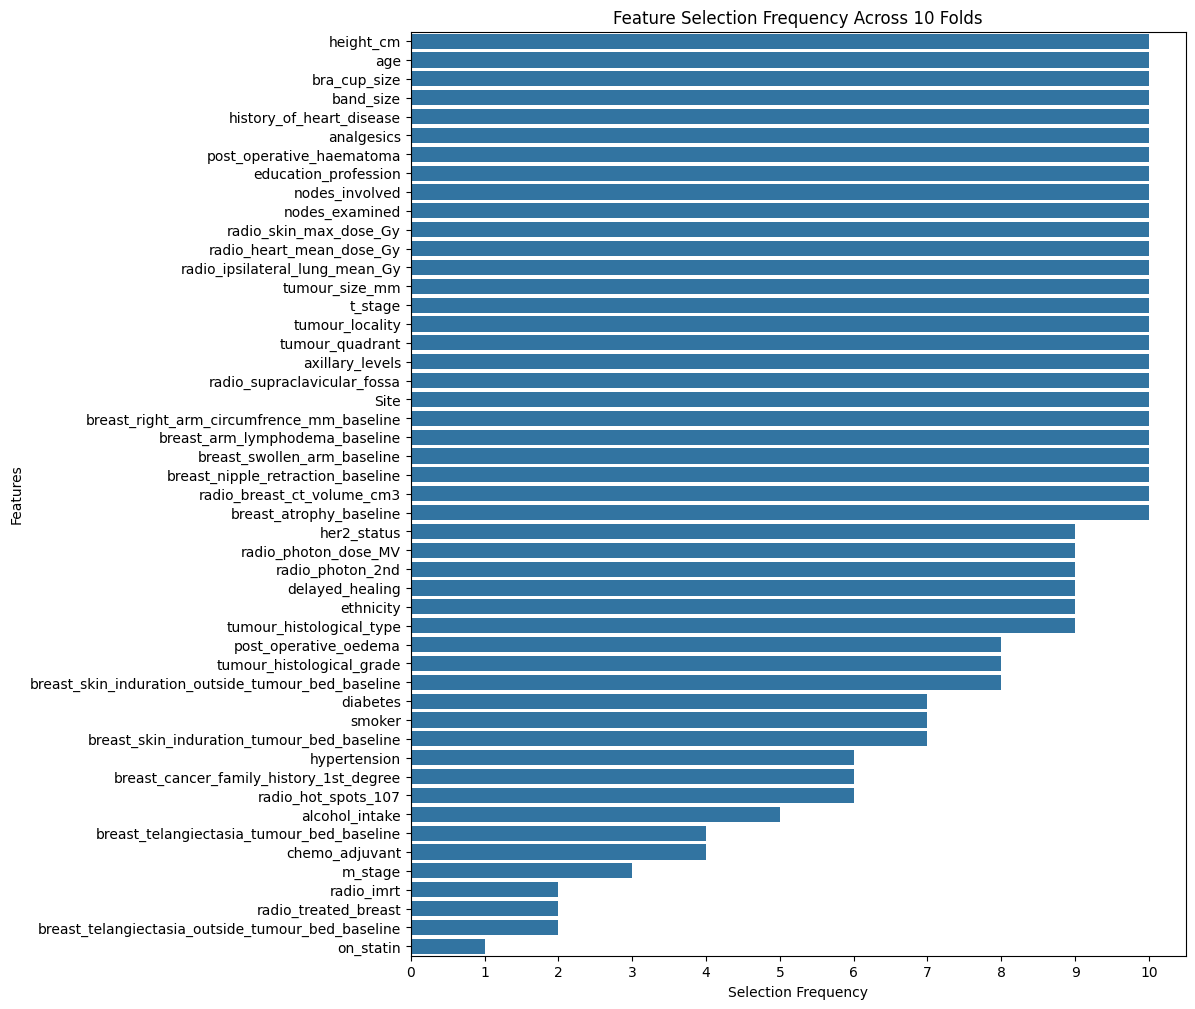

+----------------------------------------------------+-------------+
|                                                    |   Frequency |
|----------------------------------------------------+-------------|
| height_cm                                          |          10 |
| age                                                |          10 |
| bra_cup_size                                       |          10 |
| band_size                                          |          10 |
| history_of_heart_disease                           |          10 |
| analgesics                                         |          10 |
| post_operative_haematoma                           |          10 |
| education_profession                               |          10 |
| nodes_involved                                     |          10 |
| nodes_examined                                     |          10 |
| radio_skin_max_dose_Gy                             |          10 |
| radio_heart_mean_dose_Gy        

In [491]:
feature_set_rfe_CV_inside_pipeline = {}
for i in k:
  feature_set_rfe_CV_inside_pipeline[i] = featureselection3_freq(df_clinic_20, dependent1, i, 10)

In [492]:
#feature_set_rfe_CV_inside_pipeline

stable_features_rfe_inside_pipeline = get_frequent_features(
    feature_set_rfe_CV_inside_pipeline,
    freq_threshold=8
)

print(stable_features_rfe_inside_pipeline)
print(len(stable_features_rfe_inside_pipeline))


['tumour_locality', 'tumour_size_mm', 'radio_skin_max_dose_Gy', 'Site', 't_stage', 'breast_right_arm_circumfrence_mm_baseline', 'radio_ipsilateral_lung_mean_Gy', 'tumour_quadrant', 'education_profession', 'breast_atrophy_baseline', 'radio_supraclavicular_fossa', 'tumour_histological_grade', 'age', 'radio_photon_dose_MV', 'height_cm', 'history_of_heart_disease', 'delayed_healing', 'breast_swollen_arm_baseline', 'post_operative_oedema', 'radio_photon_2nd', 'post_operative_haematoma', 'ethnicity', 'radio_breast_ct_volume_cm3', 'analgesics', 'nodes_examined', 'band_size', 'breast_skin_induration_outside_tumour_bed_baseline', 'breast_arm_lymphodema_baseline', 'breast_nipple_retraction_baseline', 'tumour_histological_type', 'radio_heart_mean_dose_Gy', 'axillary_levels', 'nodes_involved', 'bra_cup_size', 'her2_status']
35


In [493]:
cross_validated_feature_selection(df_clinic_20[stable_features_rfe_inside_pipeline + [dependent1]], dependent1, splits=10)

Original Data shape is (2067, 36)
Data shape after dropping missing target: (1691, 36)
✅ Mean AUC with final selected features: 0.8020


### Nested CV

In [504]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from collections import Counter
import numpy as np
import pandas as pd
from tqdm import tqdm


def nested_cv_feature_selection_rfe(
    df,
    target,
    k_list,
    outer_splits,
    inner_splits
):

    df = df.dropna(subset=[target])

    X = df.drop(columns=[target]).select_dtypes(include=["number"])
    y = df[target]

    X = X.fillna(X.median())

    outer_cv = StratifiedKFold(
        n_splits=outer_splits,
        shuffle=True,
        random_state=0
    )

    inner_cv = StratifiedKFold(
        n_splits=inner_splits,
        shuffle=True,
        random_state=1
    )

    results = {name: [] for name in get_models(X, y).keys()}
    fold_details = []

    for fold_id, (train_idx, test_idx) in enumerate(
        tqdm(outer_cv.split(X, y), desc="Outer CV"),
        start=1
    ):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        best_k = None
        best_score = -np.inf

        # INNER LOOP: choose best number of features
        for k in k_list:
            inner_scores = []

            for inner_train_idx, inner_val_idx in inner_cv.split(X_train, y_train):

                X_tr = X_train.iloc[inner_train_idx]
                X_val = X_train.iloc[inner_val_idx]
                y_tr = y_train.iloc[inner_train_idx]
                y_val = y_train.iloc[inner_val_idx]

                rfe_estimator = RandomForestClassifier(
                    n_estimators=30,
                    max_depth=10,
                    min_samples_split=5,
                    min_samples_leaf=1,
                    bootstrap=True,
                    random_state=5,
                    n_jobs=-1
                )

                pipeline = Pipeline([
                    ("scaler", MinMaxScaler()),
                    ("feature_selection", RFE(
                        estimator=rfe_estimator,
                        n_features_to_select=k,
                        step=0.5
                    )),
                    ("model", RandomForestClassifier(
                        n_estimators=100,
                        max_depth=10,
                        min_samples_split=5,
                        min_samples_leaf=1,
                        bootstrap=True,
                        random_state=5,
                        n_jobs=-1
                    ))
                ])

                pipeline.fit(X_tr, y_tr)

                y_pred = pipeline.predict_proba(X_val)[:, 1]
                inner_scores.append(roc_auc_score(y_val, y_pred))

            mean_score = np.mean(inner_scores)

            if mean_score > best_score:
                best_score = mean_score
                best_k = k

        # OUTER LOOP: train final models using best_k
        models = get_models(X_train, y_train)

        for name, model in models.items():

            rfe_estimator = RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=1,
                bootstrap=True,
                random_state=5,
                n_jobs=-1
            )

            pipeline = Pipeline([
                ("scaler", MinMaxScaler()),
                ("feature_selection", RFE(
                    estimator=rfe_estimator,
                    n_features_to_select=best_k,
                    step=0.1
                )),
                ("model", model)
            ])

            pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict_proba(X_test)[:, 1]
            auc_score = roc_auc_score(y_test, y_pred)

            selected_mask = pipeline.named_steps["feature_selection"].get_support()
            selected_features = X_train.columns[selected_mask].tolist()

            results[name].append(auc_score)

            fold_details.append({
                "fold": fold_id,
                "model": name,
                "best_k": best_k,
                "inner_auc": best_score,
                "outer_auc": auc_score,
                "selected_features": selected_features
            })

    summary = pd.DataFrame({
        model: {
            "mean_auc": np.mean(scores),
            "std_auc": np.std(scores)
        }
        for model, scores in results.items()
    }).T.sort_values(by="mean_auc", ascending=False)

    fold_details = pd.DataFrame(fold_details)

    all_features = []
    for features in fold_details["selected_features"]:
        all_features.extend(features)

    feature_counts = Counter(all_features)

    feature_frequency = pd.DataFrame({
        "feature": feature_counts.keys(),
        "count": feature_counts.values()
    })

    feature_frequency["percentage"] = (
        100 * feature_frequency["count"] / len(fold_details)
    )

    feature_frequency = feature_frequency.sort_values(
        by="percentage",
        ascending=False
    ).reset_index(drop=True)

    return summary, fold_details, feature_frequency

In [505]:
summary3, fold_details3, feature_frequency3 = nested_cv_feature_selection_rfe(df_clinic_20, dependent1, k_list=k, outer_splits=10, inner_splits=5)

Outer CV: 10it [05:14, 31.47s/it]


In [506]:
summary3  #

,mean_auc,std_auc
RandomForest,0.799837,0.075171


In [507]:
fold_details3

,fold,model,best_k,inner_auc,outer_auc,selected_features
0,1,RandomForest,30,0.812747,0.750219,"[height_cm, age, bra_cup_size, band_size, smok..."
1,2,RandomForest,25,0.792853,0.887526,"[height_cm, age, bra_cup_size, band_size, anal..."
2,3,RandomForest,35,0.803661,0.876278,"[height_cm, age, bra_cup_size, band_size, smok..."
3,4,RandomForest,40,0.799312,0.813906,"[height_cm, age, bra_cup_size, band_size, smok..."
4,5,RandomForest,25,0.797146,0.874233,"[height_cm, age, bra_cup_size, band_size, anal..."
5,6,RandomForest,35,0.840490,0.757669,"[height_cm, age, bra_cup_size, band_size, smok..."
6,7,RandomForest,40,0.826569,0.716769,"[height_cm, age, bra_cup_size, band_size, smok..."
7,8,RandomForest,10,0.834880,0.659509,"[height_cm, age, nodes_examined, tumour_size_m..."
8,9,RandomForest,25,0.808764,0.878307,"[height_cm, age, bra_cup_size, band_size, smok..."
9,10,RandomForest,20,0.814752,0.783951,"[height_cm, age, bra_cup_size, band_size, educ..."


In [508]:
display(feature_frequency3.head(100))

,feature,count,percentage
0,height_cm,10,100.0
1,age,10,100.0
2,nodes_examined,10,100.0
3,radio_heart_mean_dose_Gy,10,100.0
4,tumour_size_mm,10,100.0
5,radio_breast_ct_volume_cm3,10,100.0
6,breast_right_arm_circumfrence_mm_baseline,10,100.0
7,radio_ipsilateral_lung_mean_Gy,10,100.0
8,Site,10,100.0
9,radio_skin_max_dose_Gy,10,100.0


In [509]:
# Features that appeared in 8 folds and more across 10 folds
stable_features3 = feature_frequency3[feature_frequency3["count"] >= 8]["feature"].tolist()

In [510]:
print(stable_features3)

['height_cm', 'age', 'nodes_examined', 'radio_heart_mean_dose_Gy', 'tumour_size_mm', 'radio_breast_ct_volume_cm3', 'breast_right_arm_circumfrence_mm_baseline', 'radio_ipsilateral_lung_mean_Gy', 'Site', 'radio_skin_max_dose_Gy', 'tumour_quadrant', 'band_size', 'bra_cup_size', 'axillary_levels', 'radio_supraclavicular_fossa', 'radio_photon_dose_MV', 't_stage', 'nodes_involved', 'education_profession', 'post_operative_haematoma', 'breast_swollen_arm_baseline', 'breast_arm_lymphodema_baseline']


In [511]:
print(len(stable_features3))

22


In [512]:
jaccard_stability(fold_details3, "RandomForest")

np.float64(0.6377082185639985)

In [513]:
cross_validated_feature_selection(df_clinic_20[stable_features3 + [dependent1]], dependent1, splits=10)

Original Data shape is (2067, 23)
Data shape after dropping missing target: (1691, 23)
✅ Mean AUC with final selected features: 0.8280


## Feature Selection 4

**3.3.5 AutoEncoder feature selection (AE)**

---


Autoencoder is a type of neural network used to compress data (encode) and then reconstruct it (decode). It's unsupervised — you don’t need labels to train it.The trick is — the middle layer has fewer neurons (features), so it must learn the most important information to recreate the original. For feature selection method, it is used to extract features with Hidden Patterns. Let’s say you're working with:

Medical data with 200+ features (demographics, genomics, imaging, etc.)

Training an autoencoder to reduce this to 10–20 learned features helps:

Find underlying structure

Reduce noise/redundancy

Improve model generalization.

### Encoding features only

In [514]:
#
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
import keras # Assuming keras is already imported and configured

def auto_encoder_feature_selection(df, col, feat):
  # Drop rows with any missing values as specified in the original function
  df = df.dropna(axis=0, how='any', inplace=False)

  # Separate features (X) and target (Y)
  # Drop target column and 'Subject Id'
  X = df.drop(columns=[col, 'Subject Id'])
  Y = df[col]

  # Explicitly drop all datetime columns before further processing
  # This ensures StandardScaler does not encounter them.
  datetime_cols = X.select_dtypes(include=['datetime64']).columns
  if not datetime_cols.empty:
      X = X.drop(columns=datetime_cols)

  # Convert categorical columns to numeric using one-hot encoding
  X = pd.get_dummies(X, drop_first=True)

  # Ensure all remaining columns are numeric before scaling
  # This acts as a safeguard, though explicit datetime dropping should prevent the specific error.
  X = X.select_dtypes(include=np.number)

  # Normalize features
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)

  # -------------------------------
  # Step 2: Autoencoder Architecture
  # -------------------------------
  input_dim = X_scaled.shape[1]
  encoding_dim = feat  # Set number of features you want to reduce to

  # Define the model
  input_layer = Input(shape=(input_dim,))
  #encoded = Dense(encoding_dim, activation='relu')(input_layer)
  #decoded = Dense(input_dim, activation='sigmoid')(encoded)

  encoded = keras.layers.Dense(encoding_dim, activation="relu")(input_layer)
  decoded = keras.layers.Dense(input_dim, activation="sigmoid")(encoded)



  autoencoder = Model(inputs=input_layer, outputs=decoded)
  autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
  autoencoder.summary()

  # ----------------------------
  # Step 3: Train the Autoencoder
  # ----------------------------
  # Ensure Y has the same index as X after dropping NaNs and columns
  Y = Y.loc[X.index]
  X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42, stratify=Y)
  autoencoder.fit(X_train, X_train,
                  epochs=50,
                  batch_size=32,
                  shuffle=True,
                  validation_data=(X_test, X_test),
                  verbose=0)

  # ----------------------------
  # Step 4: Extract Encoded Features
  # ----------------------------
  encoder = Model(inputs=autoencoder.input, outputs=autoencoder.layers[1].output)
  encoded_features = encoder.predict(X_scaled)

  return encoded_features, Y

In [515]:
encoded_features, Y= auto_encoder_feature_selection(df_clinic_20, dependent1, 20)

Model: "functional_1384"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_692 (InputLayer)    │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1384 (Dense)              │ (None, 20)             │         1,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1385 (Dense)              │ (None, 75)             │         1,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,095 (12.09 KB)

 Trainable params: 3,095 (12.09 KB)

 Non-trainable params: 0 (0.00 B)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [516]:
encoded_features.shape

(758, 20)

### Inside the pipline

In [517]:
from sklearn.base import BaseEstimator, TransformerMixin
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
import numpy as np

class AutoencoderFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, encoding_dim=10, epochs=50, batch_size=32, verbose=0):
        self.encoding_dim = encoding_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose

    def fit(self, X, y=None):
        input_dim = X.shape[1]
        input_layer = Input(shape=(input_dim,))
        encoded = Dense(self.encoding_dim, activation='relu',
                        activity_regularizer=regularizers.l1(1e-5))(input_layer)
        decoded = Dense(input_dim, activation='linear')(encoded)

        self.autoencoder = Model(inputs=input_layer, outputs=decoded)
        self.encoder = Model(inputs=input_layer, outputs=encoded)

        self.autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        self.autoencoder.fit(X, X,
                             epochs=self.epochs,
                             batch_size=self.batch_size,
                             shuffle=True,
                             verbose=self.verbose)
        return self

    def transform(self, X):
        return self.encoder.predict(X)


In [518]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

def autoencoder_feature_pipeline(df, dependent, encoding_dim):
    df = df.dropna()
    X = df.drop(columns=[dependent]).select_dtypes(include=['number'])
    y = df[dependent]

    bold('Precess with ' + str(encoding_dim) + ' encoding dimensions')

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('autoencoder_selector', AutoencoderFeatureSelector(encoding_dim=encoding_dim, epochs=50)),
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=5))
    ])

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    auc_scores = cross_val_score(pipeline, X, y, cv=skf, scoring='roc_auc')

    print(f"Mean AUC with Autoencoder-{encoding_dim} encoding dimension: {auc_scores.mean():.2f}")
    return auc_scores.mean()


In [519]:
for i in k:
  autoencoder_feature_pipeline(df_clinic_20, dependent1, i)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Mean AUC with Autoencoder-10 encoding dimension: 0.73


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Mean AUC with Autoencoder-15 encoding dimension: 0.74


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Mean AUC with Autoencoder-20 encoding dimension: 0.73


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Mean AUC with Autoencoder-25 encoding dimension: 0.78


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Mean AUC with Autoencoder-30 encoding dimension: 0.75


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Mean AUC with Autoencoder-35 encoding dimension: 0.76


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Mean AUC with Autoencoder-40 encoding dimension: 0.70


### Nested CV

In [520]:
from sklearn.base import BaseEstimator, TransformerMixin
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
import numpy as np

In [521]:
class AutoencoderFeatureSelectorNew(BaseEstimator, TransformerMixin):
    def __init__(self, encoding_dim=10, epochs=30, batch_size=32, verbose=0):
        self.encoding_dim = encoding_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose

    def fit(self, X, y=None):
        input_dim = X.shape[1]

        input_layer = Input(shape=(input_dim,))

        encoded = Dense(
            self.encoding_dim,
            activation="relu",
            activity_regularizer=regularizers.l1(1e-5)
        )(input_layer)

        decoded = Dense(input_dim, activation="linear")(encoded)

        self.autoencoder = Model(inputs=input_layer, outputs=decoded)
        self.encoder = Model(inputs=input_layer, outputs=encoded)

        self.autoencoder.compile(
            optimizer=Adam(learning_rate=0.001),
            loss="mse"
        )

        self.autoencoder.fit(
            X,
            X,
            epochs=self.epochs,
            batch_size=self.batch_size,
            shuffle=True,
            verbose=self.verbose
        )

        return self

    def transform(self, X):
        return self.encoder.predict(X, verbose=0)

In [522]:
from sklearn.base import BaseEstimator, TransformerMixin
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.impute import SimpleImputer
def nested_cv_autoencoder(df, target, encoding_dims,
                          outer_splits=10, inner_splits=3):

    df = df.dropna(subset=[target])

    X = df.drop(columns=[target]).select_dtypes(include=["number"])
    y = df[target]

    outer_cv = StratifiedKFold(
        n_splits=outer_splits,
        shuffle=True,
        random_state=0
    )

    inner_cv = StratifiedKFold(
        n_splits=inner_splits,
        shuffle=True,
        random_state=1
    )

    results = []

    for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        best_dim = None
        best_score = -np.inf

        for dim in encoding_dims:
            inner_scores = []
            for inner_train_idx, inner_val_idx in inner_cv.split(X_train, y_train):

                X_tr = X_train.iloc[inner_train_idx]
                X_val = X_train.iloc[inner_val_idx]
                y_tr = y_train.iloc[inner_train_idx]
                y_val = y_train.iloc[inner_val_idx]

                pipeline = Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", MinMaxScaler()),
                    ("autoencoder", AutoencoderFeatureSelectorNew(
                        encoding_dim=dim,
                        epochs=30,
                        batch_size=32,
                        verbose=0
                    )),
                    ("model", RandomForestClassifier(
                        n_estimators=100,
                        max_depth=10,
                        random_state=5,
                        n_jobs=-1
                    ))
                ])

                pipeline.fit(X_tr, y_tr)

                y_pred = pipeline.predict_proba(X_val)[:, 1]
                inner_scores.append(roc_auc_score(y_val, y_pred))

            mean_score = np.mean(inner_scores)

            if mean_score > best_score:
                best_score = mean_score
                best_dim = dim

        final_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler()),
            ("autoencoder", AutoencoderFeatureSelectorNew(
                encoding_dim=best_dim,
                epochs=30,
                batch_size=32,
                verbose=0
            )),
            ("model", RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                random_state=5,
                n_jobs=-1
            ))
        ])

        final_pipeline.fit(X_train, y_train)

        y_pred = final_pipeline.predict_proba(X_test)[:, 1]
        outer_auc = roc_auc_score(y_test, y_pred)

        results.append({
            "fold": fold_id,
            "best_encoding_dim": best_dim,
            "inner_auc": best_score,
            "outer_auc": outer_auc
        })

    results = pd.DataFrame(results)

    print(results)
    print("Mean AUC:", results["outer_auc"].mean())
    print("STD AUC:", results["outer_auc"].std())

    return results

In [523]:
ae_results = nested_cv_autoencoder(df_clinic_20, dependent1,
                                   encoding_dims=k,
                                   outer_splits=10, inner_splits=5)

   fold  best_encoding_dim  inner_auc  outer_auc
0     1                 40   0.743226   0.671341
1     2                 35   0.742414   0.843558
2     3                 25   0.744762   0.763804
3     4                 30   0.747745   0.685072
4     5                 40   0.784709   0.742331
5     6                 35   0.802270   0.669734
6     7                 40   0.774796   0.656442
7     8                 35   0.773053   0.691207
8     9                 40   0.776883   0.816578
9    10                 30   0.739843   0.772487
Mean AUC: 0.7312553424005367
STD AUC: 0.0662341044857541
